In [119]:
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    SBVGPResult2,
    SIResult,
    FlowPriorResult,
    SBVGPAdaptedResult,
    FPSamplesConfig,
    FPSamples,
    MLPCondSamples2,
    AdaptPriorResult,
    LikelihoodResult
)
from experiments.dj.dataloader_tables import DataLoaderConfig


from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import compute_logl, compute_haefner_logl_i_cond_x, visualize_conditional_features

import torch
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from task_transfer.sampling_models.plotting import plot_cohen_task, plot_haefner_model


from task_transfer.utils.model_utils import build_haefner_model

import experiments.orientation_discrimination.haefner_model.configs as cfg

from pathlib import Path

import pickle


import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

torch.manual_seed(42)

In [2]:
task1_params = cfg.haefner_model_4neuron_highdelta_task1
task2_params = cfg.haefner_model_4neuron_highdelta_task2

In [3]:
task1_data_model = build_haefner_model(
    p_c=task1_params["p_c"],
    c1_psi=task1_params["c1_psi"],
    c2_psi=task1_params["c2_psi"],
    kappa=task1_params["kappa"],
    g_phi=task1_params["g_phi"],
    delta=task1_params["delta"],
    lam=task1_params["lam"],
    x_phi=task1_params["x_phi"],
    obs_sigma=task1_params["obs_sigma"],
    obs_h=task1_params["obs_h"],
    obs_w=task1_params["obs_w"],
)

task2_data_model = build_haefner_model(
    p_c=task2_params["p_c"],
    c1_psi=task2_params["c1_psi"],
    c2_psi=task2_params["c2_psi"],
    kappa=task2_params["kappa"],
    g_phi=task2_params["g_phi"],
    delta=task2_params["delta"],
    lam=task2_params["lam"],
    x_phi=task2_params["x_phi"],
    obs_sigma=task2_params["obs_sigma"],
    obs_h=task2_params["obs_h"],
    obs_w=task2_params["obs_w"],
)

In [4]:
# plot_cohen_task(
#     p_c=task1_params["p_c"],
#     c1_psi=task1_params["c1_psi"],
#     c2_psi=task1_params["c2_psi"],
#     legend=False,
# )

In [5]:
with open(task1_params["data_fname"], "rb") as f:
    task1_data_dict = pickle.load(f)

In [6]:
with open(task2_params["data_fname"], "rb") as f:
    task2_data_dict = pickle.load(f)

In [7]:
task1_data_dict.keys()

dict_keys(['c_samples', 'g_prob', 'g_samples', 'x_fb', 'tau', 'x_samples', 'i_samples'])

In [8]:
task1_data_dict["g_samples"].shape

torch.Size([10000, 9])

In [9]:
# plot_haefner_model(
#     model=task1_data_model,
#     samples_dict=task1_data_dict,
#     dpi=300,
#     fontsize=16,
#     linewidth=4,
#     tick_length=6,
#     tick_width=2,
#     g_figname="g_activity.pdf",
#     x_figname="x_activity.pdf",
#     xcorr_figname="xcorr.pdf",
#     xcorr_hist_figname="xcorr_hist.pdf",
#     xdist_figname="xdist.pdf",
#     plot_corr=True,
# )

/src/project/task_transfer/sampling_models/plotting.py:299: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax_prior_x.set_yticklabels(ax_prior_x.get_yticklabels(), color="darkorange")


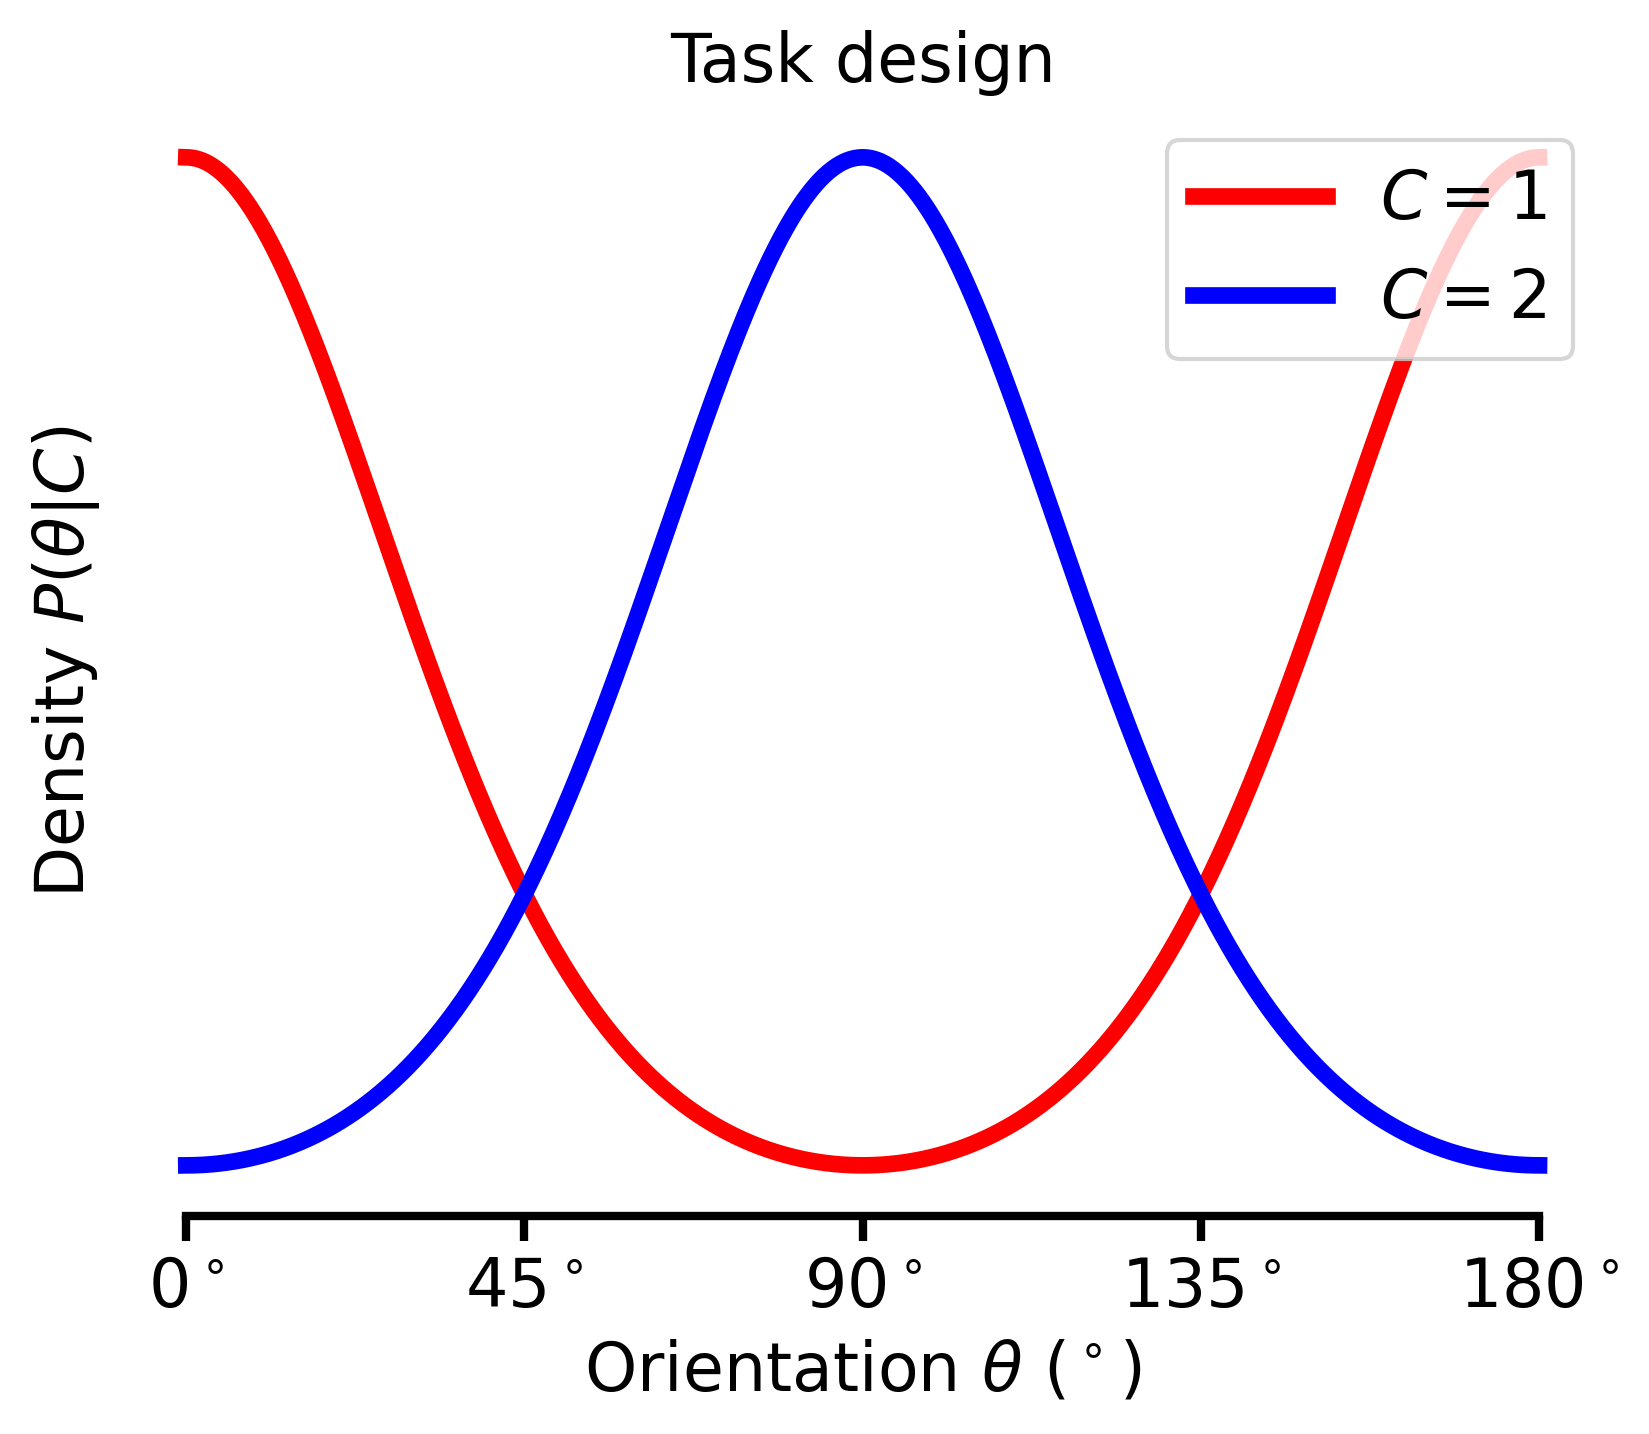

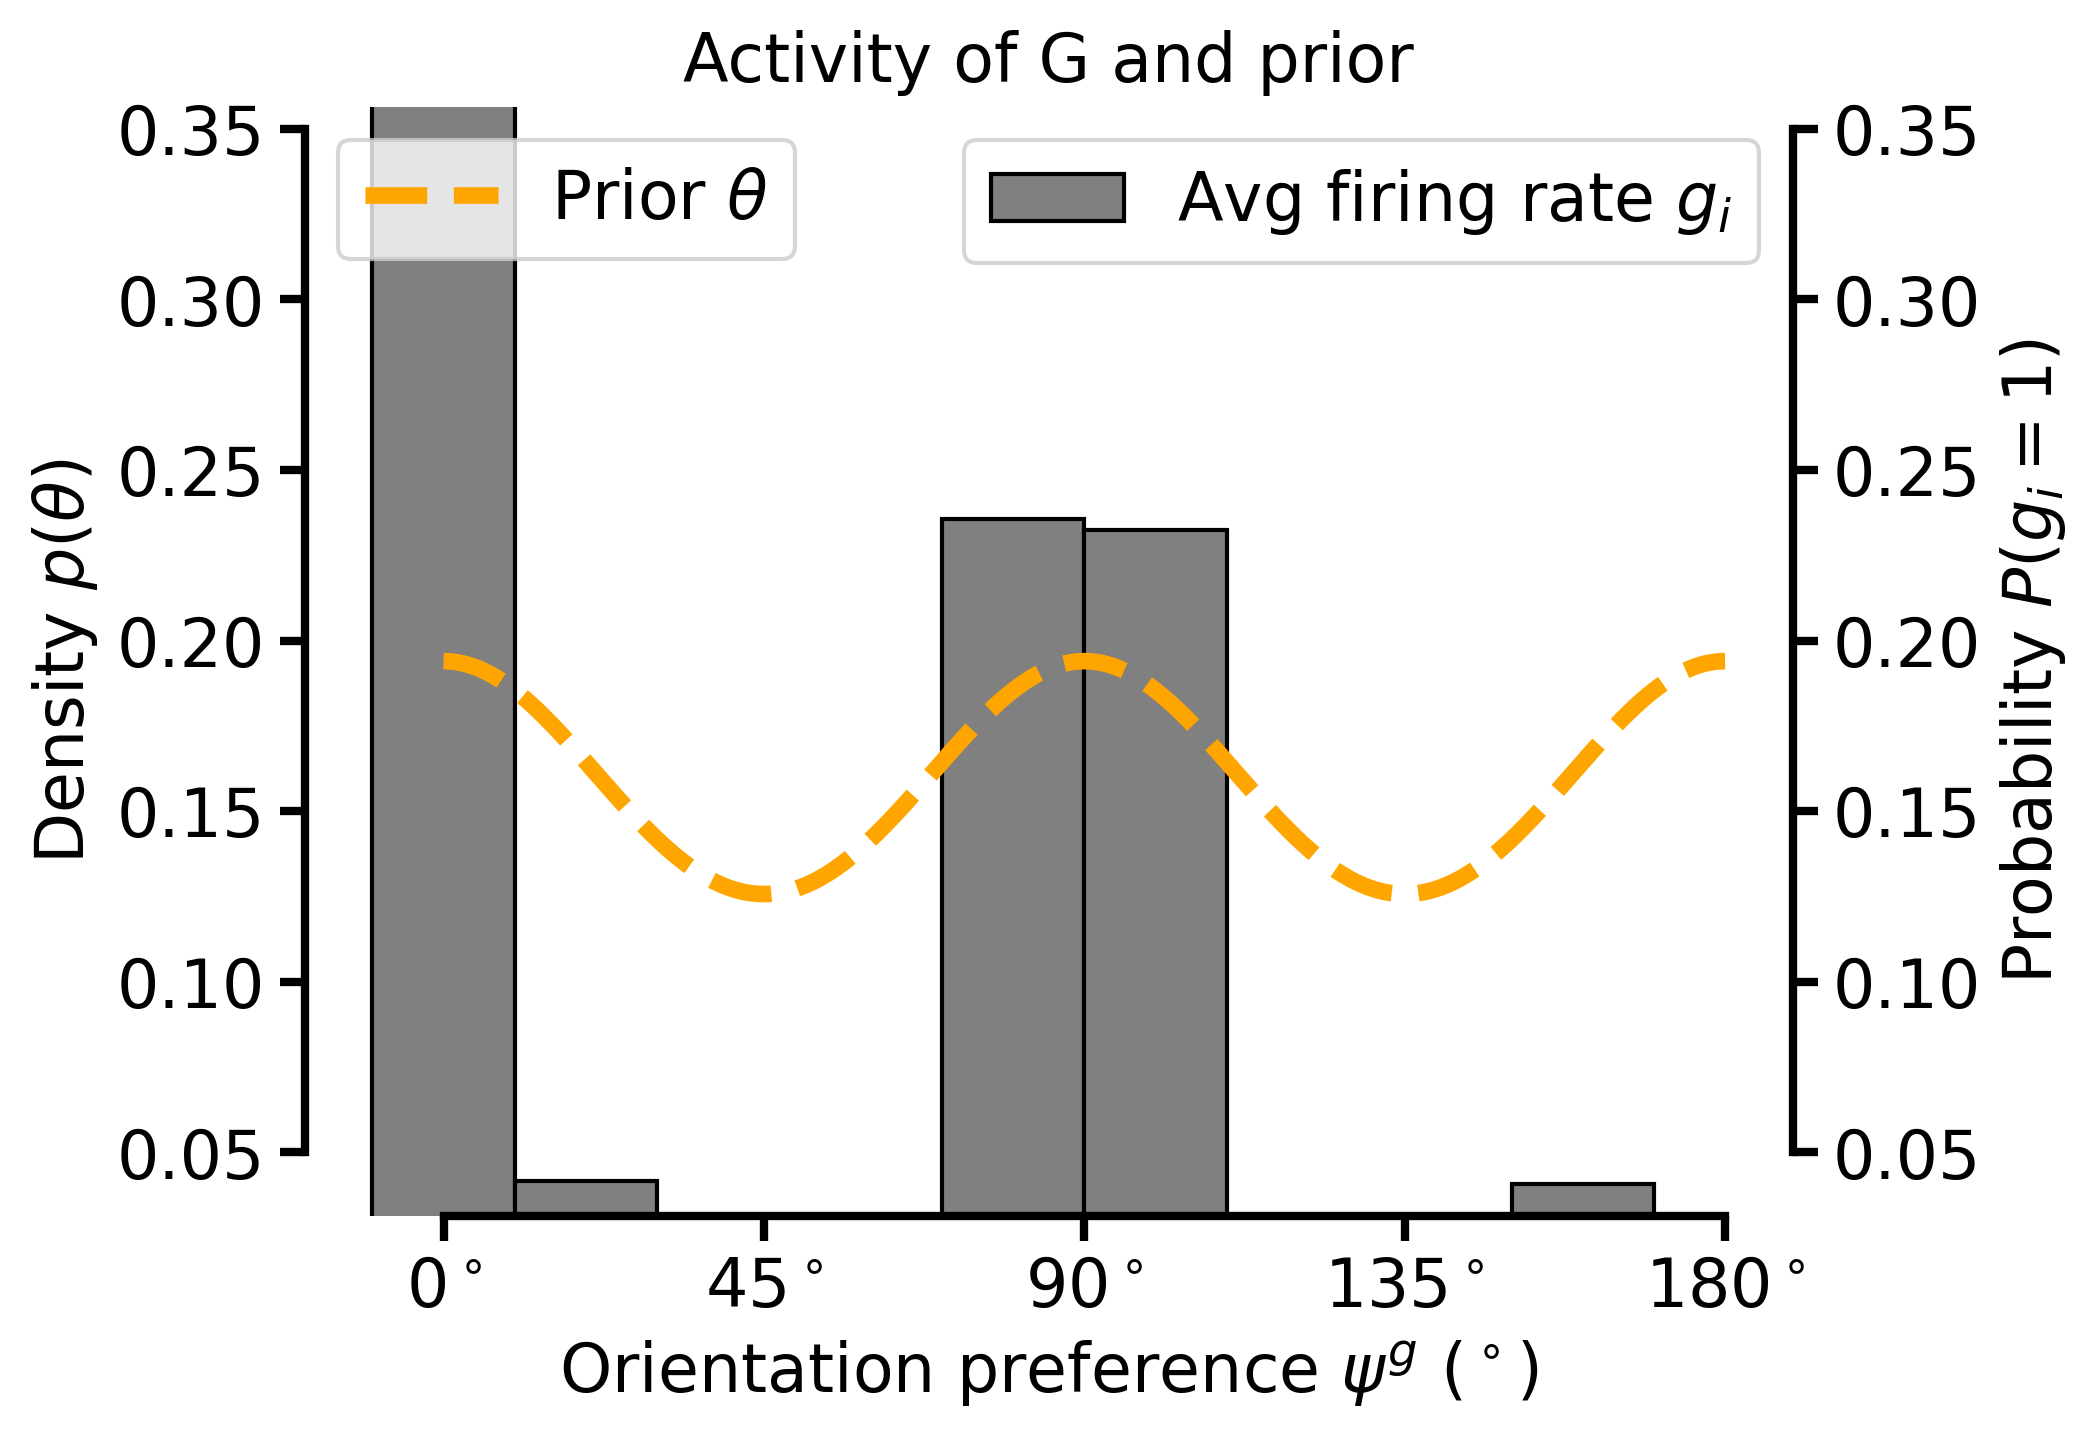

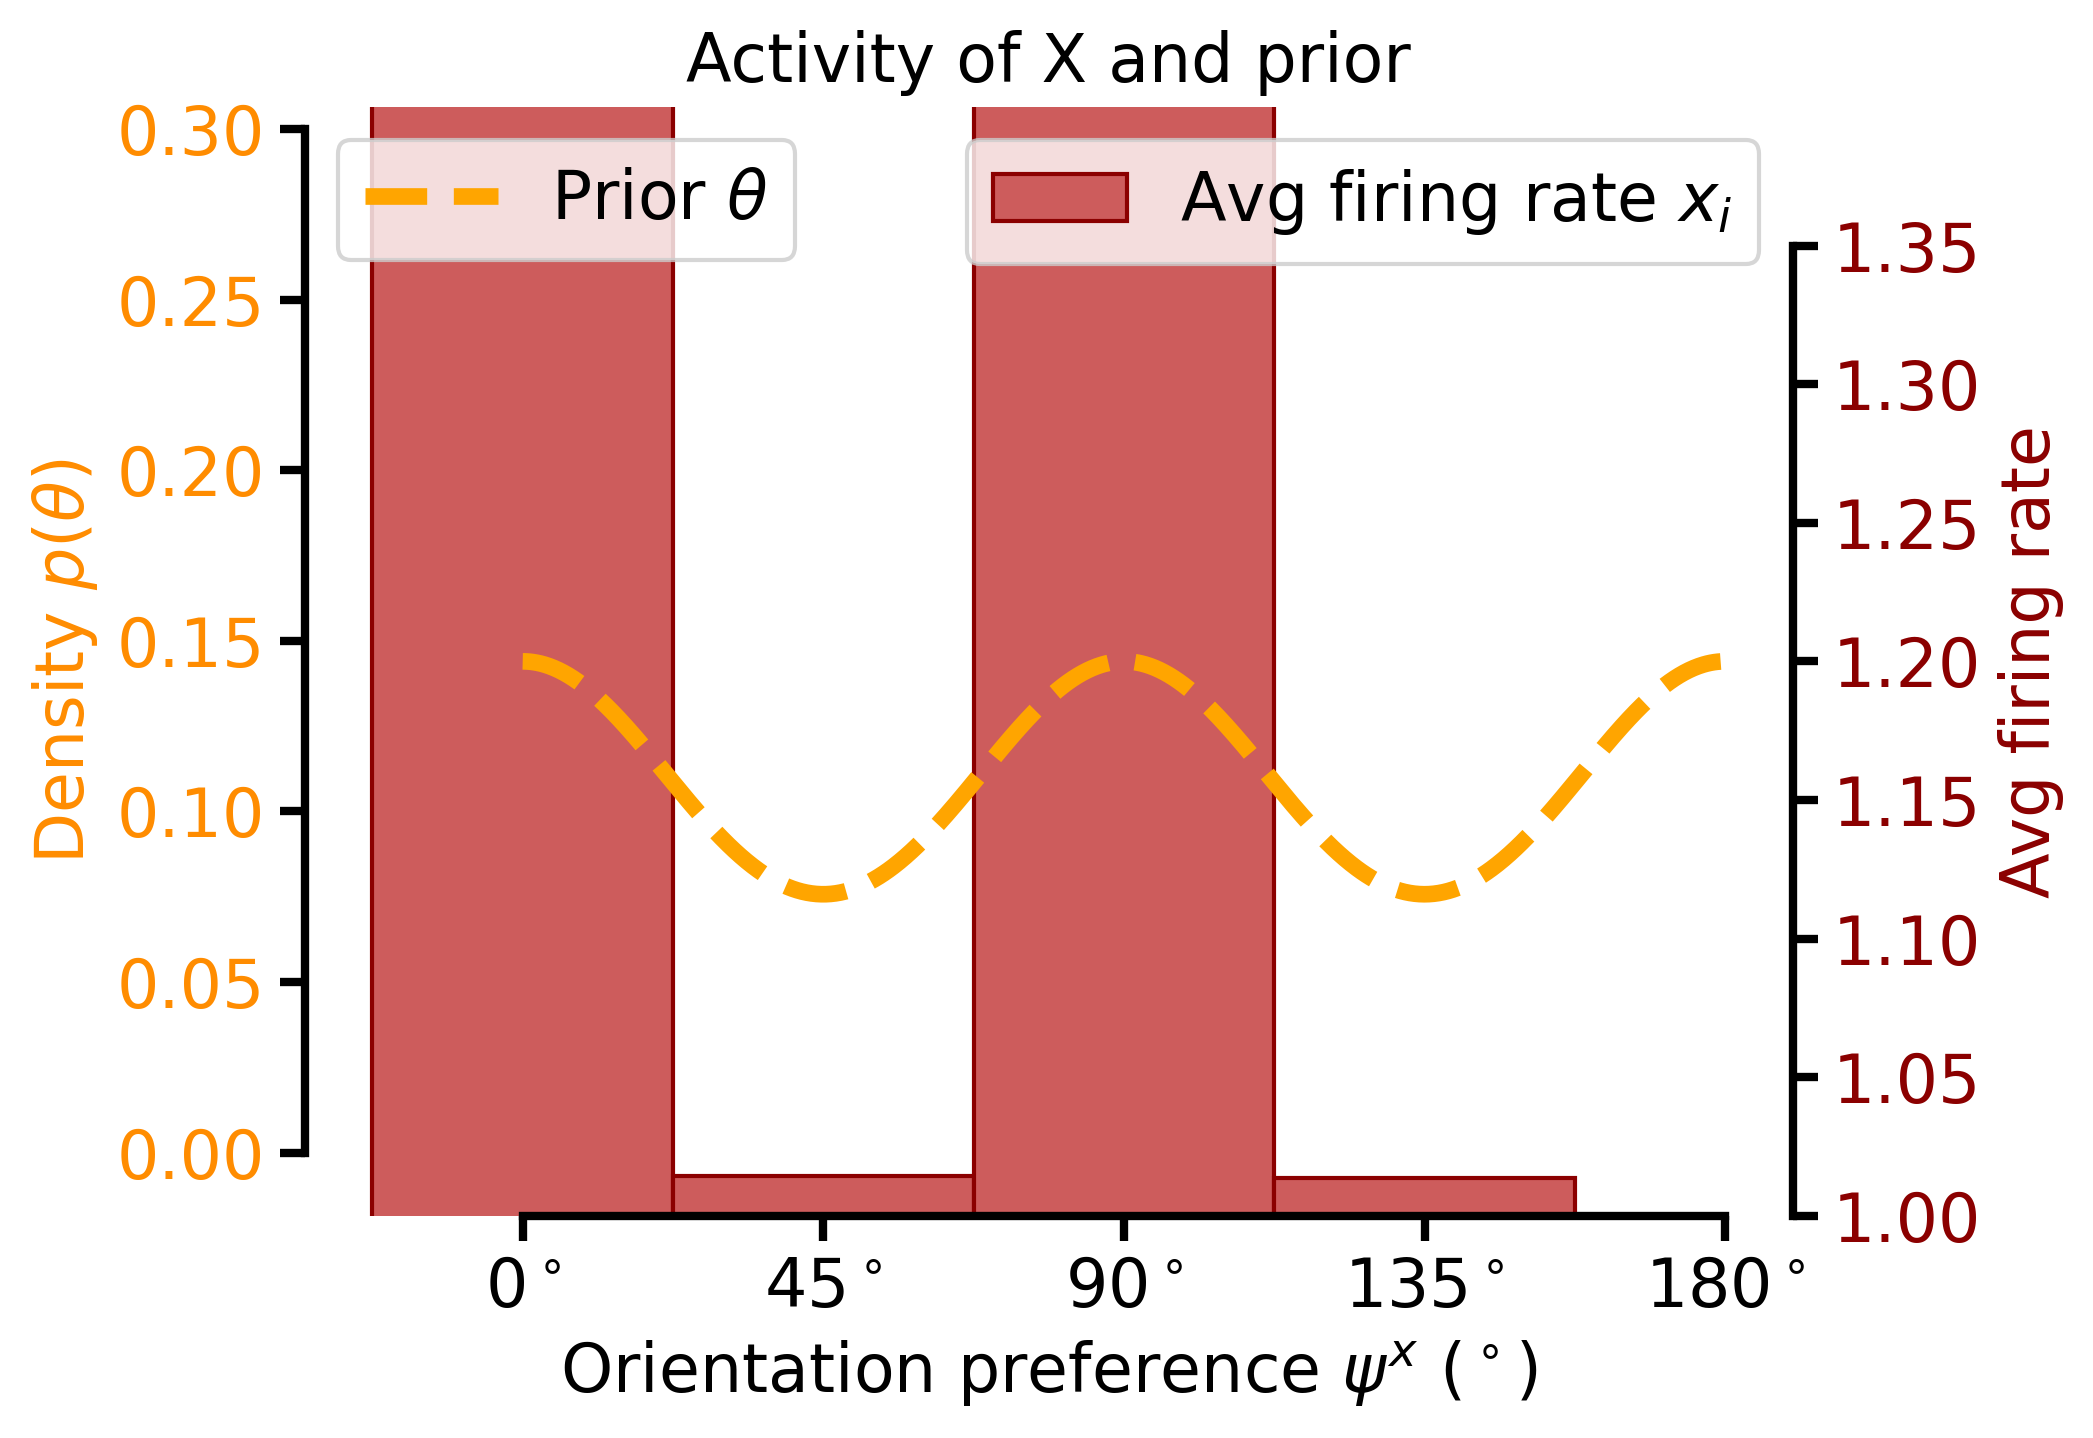

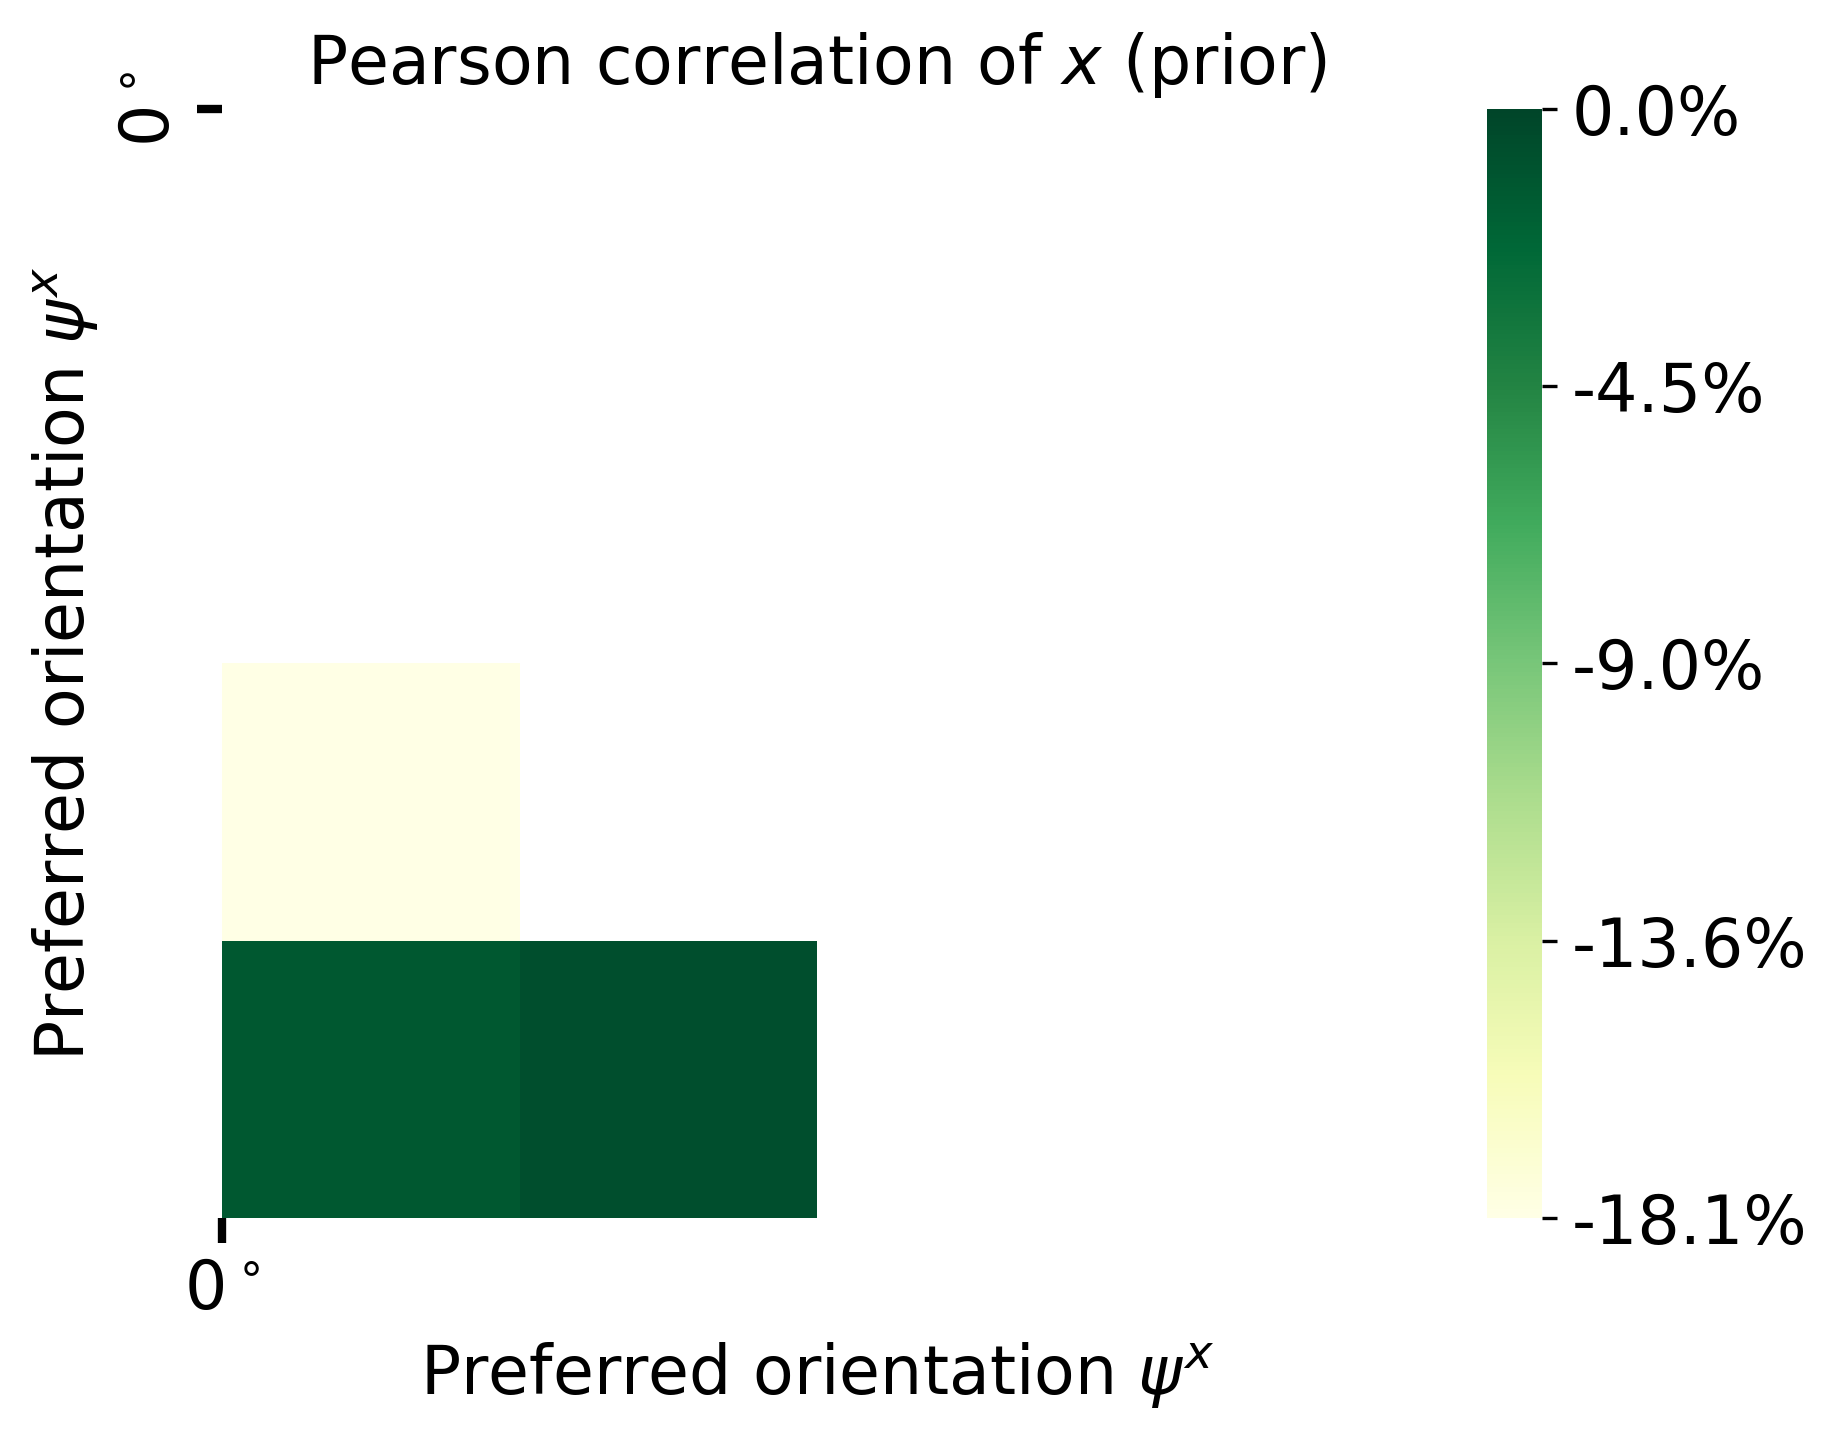

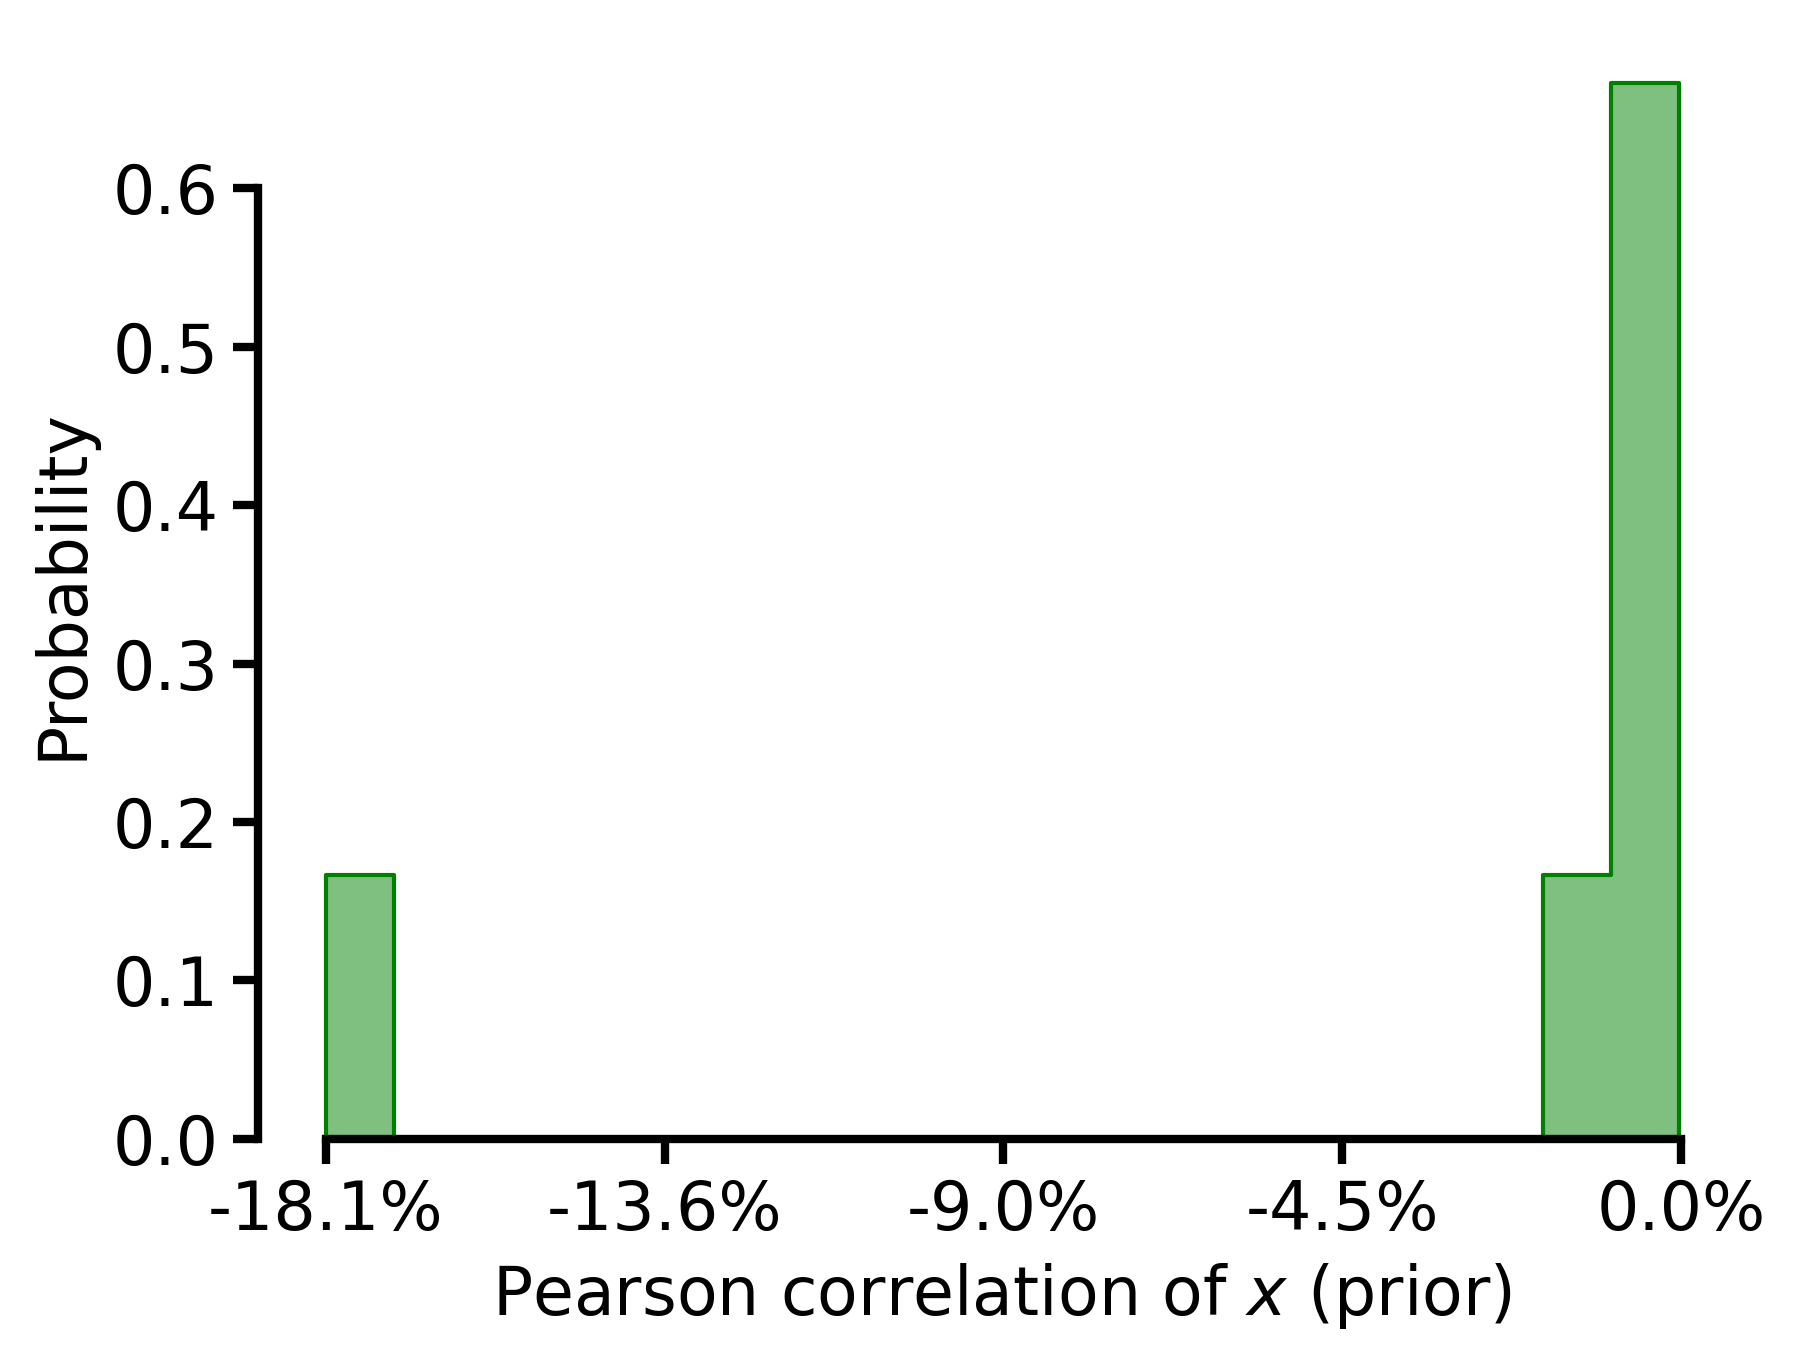

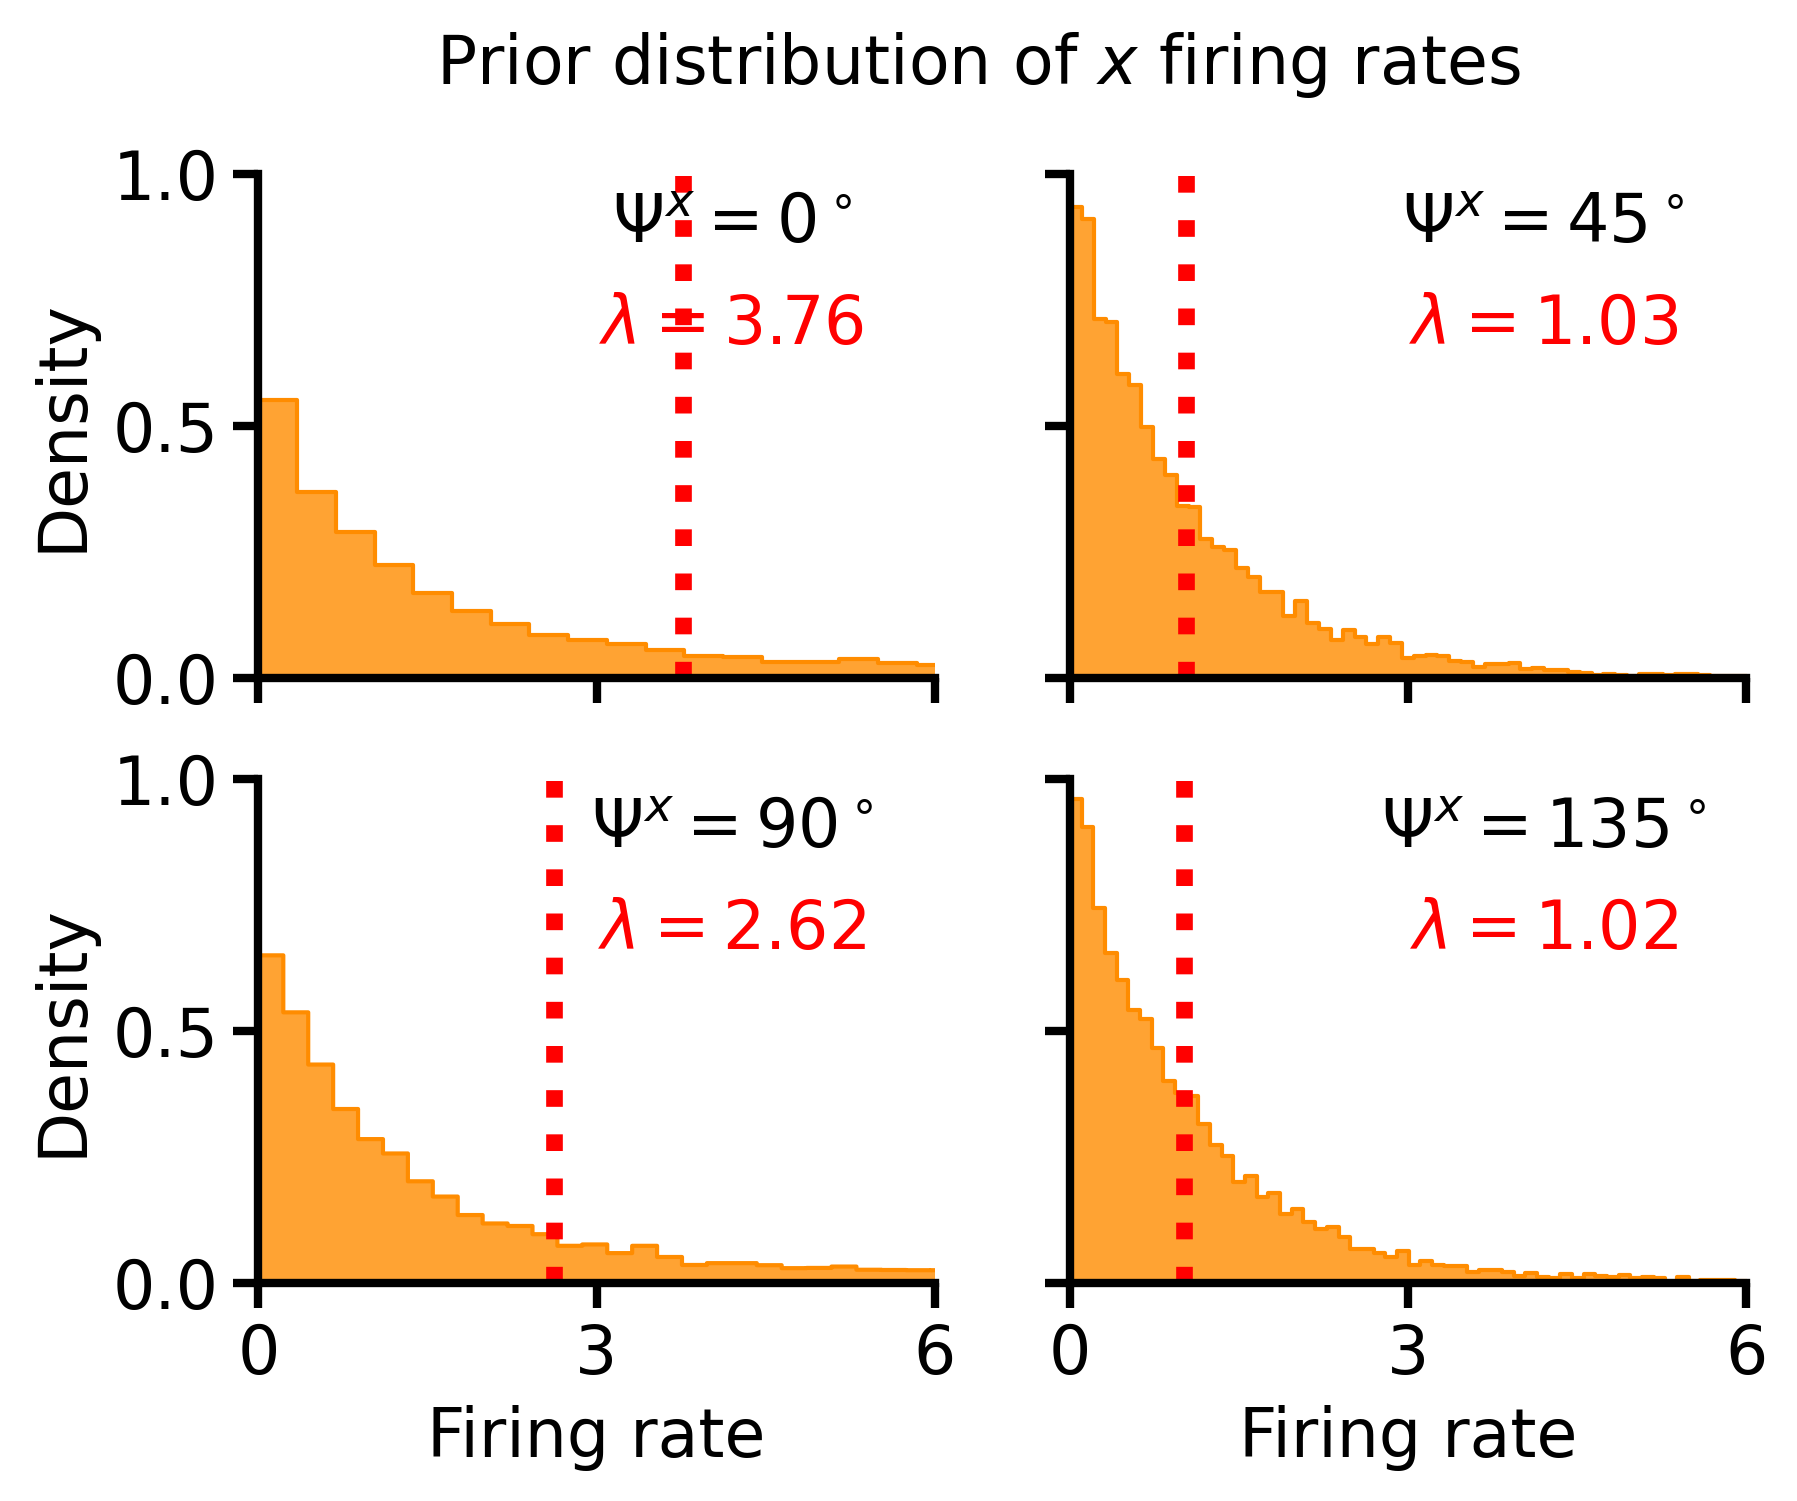

In [10]:
plot_haefner_model(
    model=task2_data_model,
    samples_dict=task2_data_dict,
    dpi=300,
    fontsize=16,
    linewidth=4,
    tick_length=6,
    tick_width=2,
    g_figname="g_activity.pdf",
    x_figname="x_activity.pdf",
    xcorr_figname="xcorr.pdf",
    xcorr_hist_figname="xcorr_hist.pdf",
    xdist_figname="xdist.pdf",
    plot_corr=True,
)

In [11]:
DataLoaderConfig()

id,data_fname,train_prop,val_prop
05977a317062b759857ee411a2e60648,/src/project/data/synthetic/haefner_2afc/haefner_2neuron_task1.pkl,0.7,0.2
260a5ea8175f75eaef132f42873ad14a,/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl,0.7,0.2
4477b5e82704db0bc19727864c7ef5aa,/src/project/data/synthetic/haefner_2afc/haefner_4neuron_task1.pkl,0.7,0.2
5352c4a57ef18797b082283de593157b,/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task2_dataset.pkl,0.7,0.2
8e9be142eedb21007255e89dbff362da,/src/project/data/synthetic/haefner_2afc/haefner_model_2neuron_highdelta_task1_dataset.pkl,0.7,0.2
94efb58694007205fac996d7963f88c5,/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_highdelta_task2_dataset.pkl,0.7,0.2
b8379e7d6998fc94a08a9a3742eec12d,/src/project/data/synthetic/haefner_2afc/flat_haefner_dataset.pkl,0.7,0.2
bb9bdd1ccd59e5a8c801d7f2d43e0317,/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task1_dataset.pkl,0.7,0.2
d74090584b0b974c4444a5ec64c3d87d,/src/project/data/synthetic/haefner_2afc/haefner_model_2neuron_highdelta_task2_dataset.pkl,0.7,0.2
f1ae78885d2ace1ba976199d4cf1a4d6,/src/project/data/synthetic/haefner_2afc/haefner_model_1neuron_task1_dataset.pkl,0.7,0.2


In [12]:
dataloader_config1 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader1, val_loader1, test_loader1 = build_dataloaders(
    data_fname=dataloader_config1["data_fname"],
    train_prop=dataloader_config1["train_prop"],
    val_prop=dataloader_config1["val_prop"],
    batch_size=dataloader_config1["batch_size"],
)

dataloader_config2 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/haefner_model_4neuron_highdelta_task2_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader2, val_loader2, test_loader2 = build_dataloaders(
    data_fname=dataloader_config2["data_fname"],
    train_prop=dataloader_config2["train_prop"],
    val_prop=dataloader_config2["val_prop"],
    batch_size=dataloader_config2["batch_size"],
)

In [13]:
dl1_id = "bb9bdd1ccd59e5a8c801d7f2d43e0317"
dl2_id = "5352c4a57ef18797b082283de593157b"

In [14]:
metric = "val_ll_mean"
limit = 1
download_path = "/tmp"

si_restriction1 = f"dl_id = '{dl1_id}'"
si1 = (SIResult & si_restriction1).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1 = f"dl_id = '{dl1_id}'"
sbv_restriction1_50k = sbv_restriction1 + " and n_samples = 50000"
sbv1_50k = (SBVGPResult2 & sbv_restriction1_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_30k = sbv_restriction1 + " and n_samples = 30000"
sbv1_30k = (SBVGPResult2 & sbv_restriction1_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_20k = sbv_restriction1 + " and n_samples = 20000"
sbv1_20k = (SBVGPResult2 & sbv_restriction1_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_10k = sbv_restriction1 + " and n_samples = 10000"
sbv1_10k = (SBVGPResult2 & sbv_restriction1_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si1_model = torch.load(si1["model"], map_location="cpu")
sbv1_50k_model = torch.load(sbv1_50k["model"], map_location="cpu")
sbv1_30k_model = torch.load(sbv1_30k["model"], map_location="cpu")
sbv1_20k_model = torch.load(sbv1_20k["model"], map_location="cpu")
sbv1_10k_model = torch.load(sbv1_10k["model"], map_location="cpu")

sbv1_prior = (
    FlowPriorResult
    & {
        "dl_id": sbv1_50k["dl_id"],
        "trainer_id": sbv1_50k["trainer_id"],
        "fp_id": sbv1_50k["fp_samples_id"],
    }
).fetch1(download_path=download_path)
sbv1_prior_model = torch.load(
    sbv1_prior["model"],
)

sbv1_likelihood = (
    LikelihoodResult
    & {
        "dl_id": sbv1_50k["dl_id"],
        "trainer_id": sbv1_50k["ll_trainer_id"],
        "ll_id": sbv1_50k["mlpcond_samples_id"],
    }
).fetch1(download_path=download_path)
sbv1_likelihood_model = torch.load(sbv1_likelihood["model"], map_location="cpu")

In [15]:
si_restriction2 = f"dl_id = '{dl2_id}'"

si2 = (SIResult & si_restriction2).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2 = f"alt_dl_id = '{dl2_id}'"
sbv_restriction2_50k = sbv_restriction2 + " and n_samples = 50000"
sbv2_50k = (SBVGPAdaptedResult & sbv_restriction2_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_30k = sbv_restriction2 + " and n_samples = 30000"
sbv2_30k = (SBVGPAdaptedResult & sbv_restriction2_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_20k = sbv_restriction2 + " and n_samples = 20000"
sbv2_20k = (SBVGPAdaptedResult & sbv_restriction2_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_10k = sbv_restriction2 + " and n_samples = 10000"
sbv2_10k = (SBVGPAdaptedResult & sbv_restriction2_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si2_model = torch.load(si2["model"], map_location="cpu")
sbv2_50k_model = torch.load(sbv2_50k["model"], map_location="cpu")
sbv2_30k_model = torch.load(sbv2_30k["model"], map_location="cpu")
sbv2_20k_model = torch.load(sbv2_20k["model"], map_location="cpu")
sbv2_10k_model = torch.load(sbv2_10k["model"], map_location="cpu")

sbv2_gen = (
    AdaptPriorResult
    & {
        "prior_fp_id": sbv2_50k["prior_fp_id"],
        "prior_trainer_id": sbv2_50k["prior_trainer_id"],
        "dl_id": sbv2_50k["alt_dl_id"],
        "seed": sbv2_50k["data_seed"],
    }
).fetch1(download_path=download_path)
sbv2_gen_model = torch.load(sbv2_gen["model"], map_location="cpu")
sbv2_prior_model = sbv2_gen_model.prior
sbv2_likelihood_model = sbv2_gen_model.conditional

In [16]:
task1_x = task1_data_dict["x_samples"]
print(task1_x.shape)

torch.Size([10000, 4])


In [17]:
dpi = 300
fontsize = 16
linewidth = 4
tick_length=6
tick_width=2

In [18]:
n_hist_samples = 500_000
sbv1_prior_samples = sbv1_prior_model.sample((n_hist_samples,))

In [19]:
sbv1_prior_samples.shape

torch.Size([500000, 4])

In [20]:
task2_x = task2_data_dict["x_samples"]

In [21]:
prior_model_linewidth = 3

Text(0.5, 0.98, 'Task 1 prior of $x$ rates')

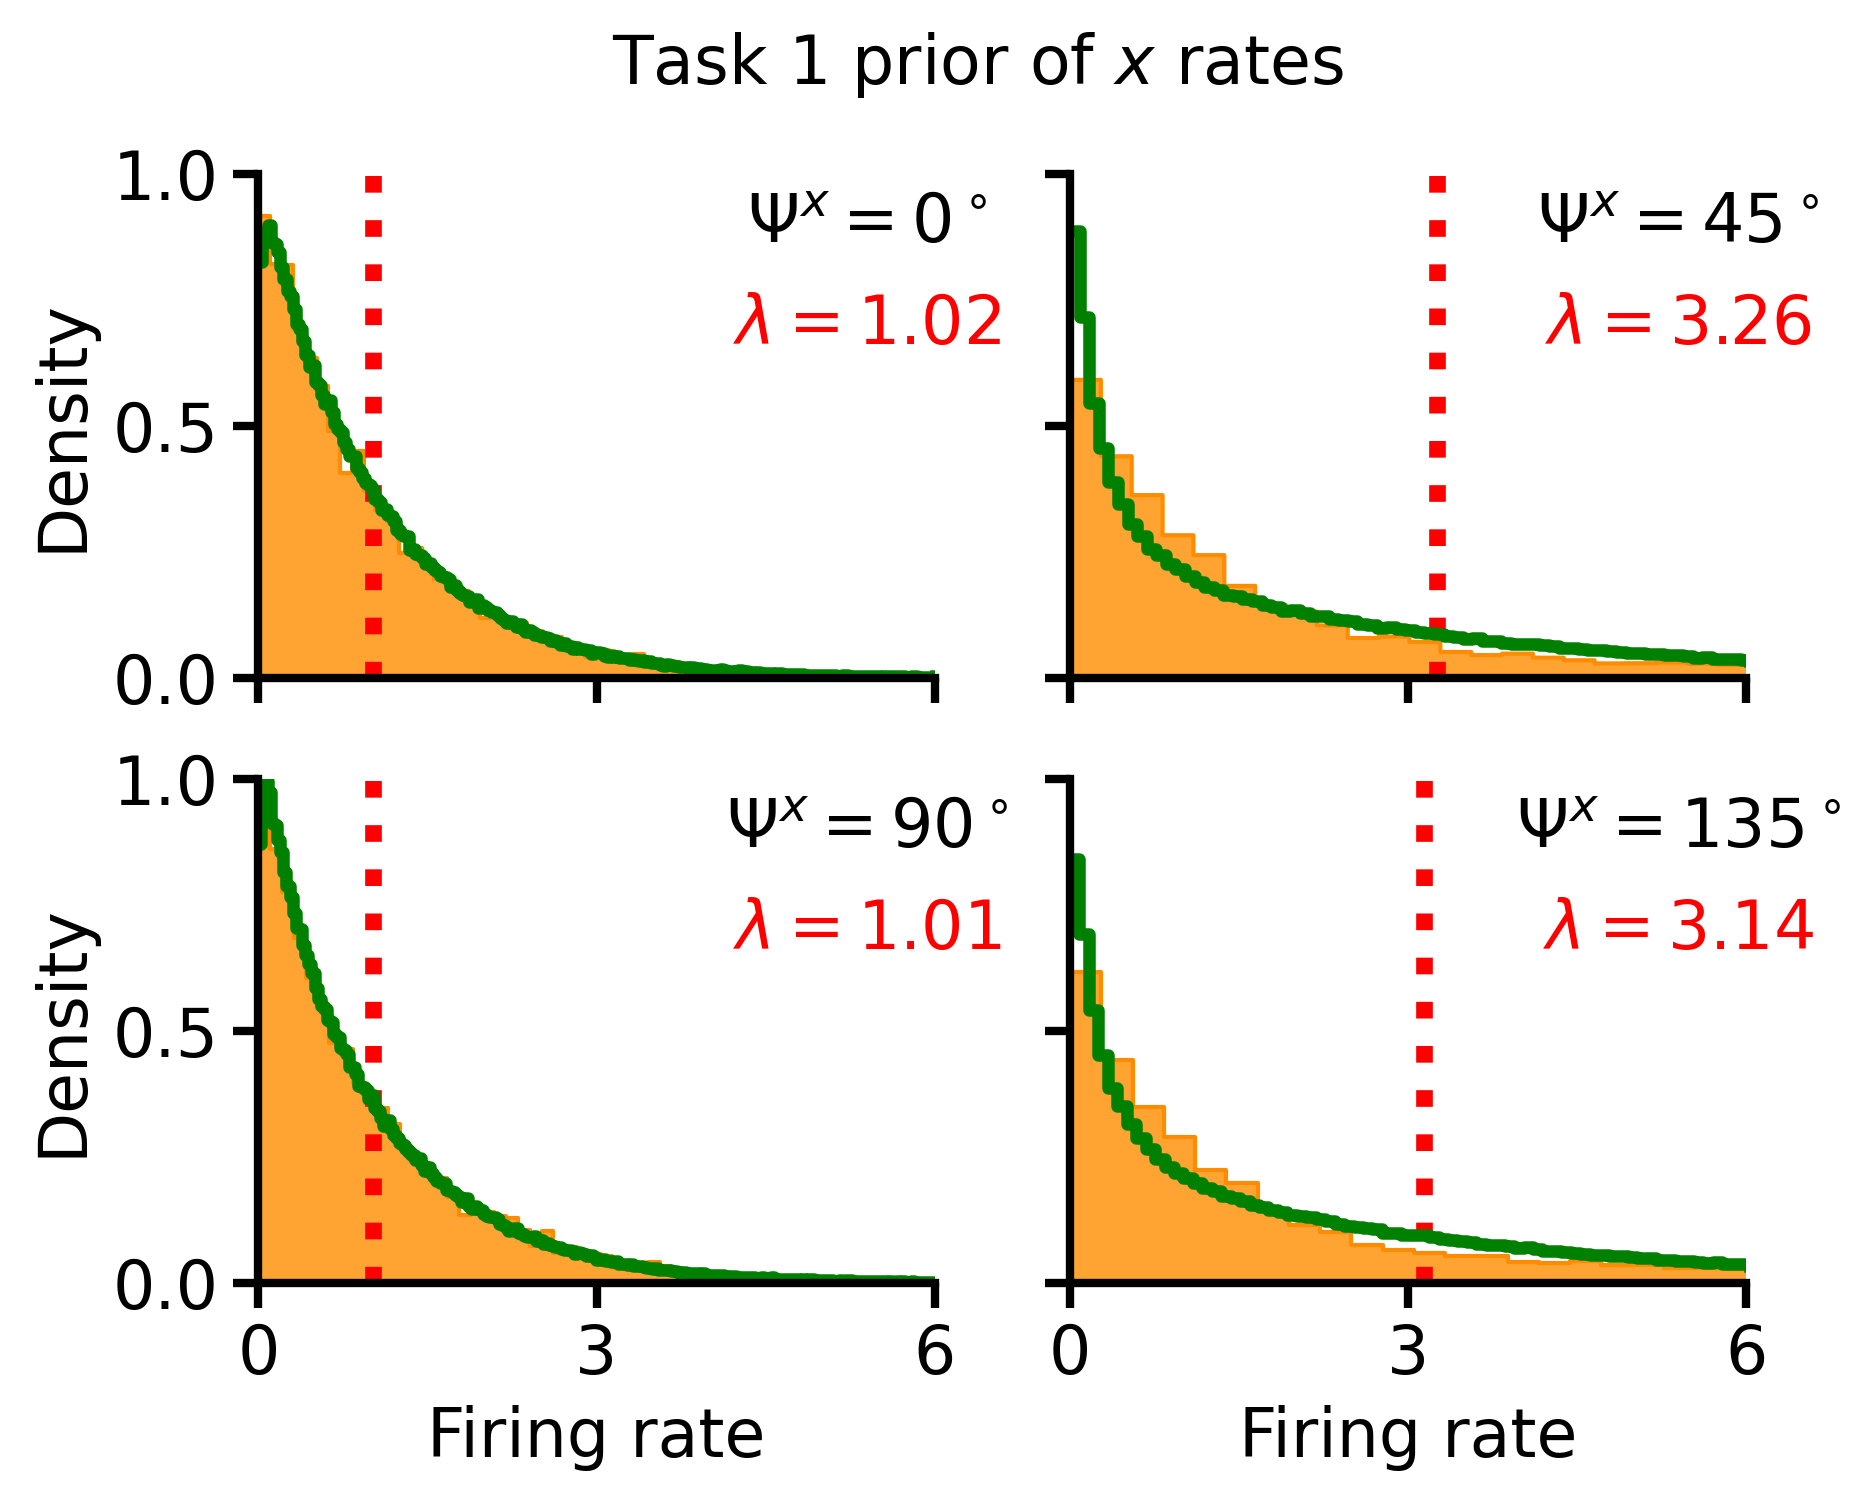

In [22]:
fig_xdist, axs_dist = plt.subplots(2, 2, dpi=dpi, sharex=True, sharey=True)
for idx, ax in enumerate(axs_dist.flatten()):
    sns.histplot(
        task1_x[:, idx],
        ax=ax,
        stat="density",
        element="step",
        # kde=True,
        color="darkorange",
        # label="No task",
        alpha=0.8,
        # linewidth=linewidth,
    )
    ax.text(
        0.9,
        0.9,
        f"$\\Psi^x=${int(np.rad2deg(task1_data_model.x_phi[idx]))}$^\circ$",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=fontsize,
    )
    mean_samples = torch.mean(task1_x[:, idx])
    ax.axvline(
        mean_samples, color="red", linestyle="dotted", linewidth=linewidth
    )
    ax.text(
        0.9,
        0.7,
        f"$\\lambda=${mean_samples:.2f}",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=fontsize,
        color="red",
        label="Mean",
    )
    sns.histplot(
        sbv1_prior_samples[:, idx].detach().numpy(),
        ax=ax,
        stat="density",
        element="step",
        color="green",
        alpha=1,
        label="Model",
        fill=False,
        linewidth=prior_model_linewidth,
    )
    # mean_hist_samples = torch.mean(sbv1_prior_samples[:, idx]).item()
    # ax.axvline(
    #     mean_hist_samples, color="blue", linestyle="dotted", linewidth=linewidth
    # )
    # ax.text(
    #     0.7,
    #     0.5,
    #     f"$\\lambda=${mean_hist_samples:.2f}",
    #     horizontalalignment="center",
    #     verticalalignment="center",
    #     transform=ax.transAxes,
    #     fontsize=fontsize,
    #     color="blue",
    #     label="Mean",
    # )
    ax.set_xlim([0, 6])
    ax.set_ylim([0, 1])
    ax.set_xticks(np.arange(0, 7, step=3))
    ax.set_yticks([0, 0.5, 1])
    ax.tick_params(
        axis="both",
        which="both",
        labelsize=fontsize,
        length=tick_length,
        width=tick_width,
    )
    ax.set_ylabel("Density", fontsize=fontsize)
    ax.set_xlabel("Firing rate", fontsize=fontsize)
    sns.despine(ax=ax)
    ax.spines[["left", "bottom"]].set_linewidth(tick_width)
    # ax.axis("equal")
fig_xdist.suptitle("Task 1 prior of $x$ rates", fontsize=fontsize)
# fig_xdist.savefig(xdist_figname, bbox_inches="tight", transparent=True)


In [23]:
n_hist_samples = 500_000
sbv2_prior_samples = sbv2_prior_model.sample((n_hist_samples,))

Text(0.5, 0.98, 'Task 2 prior of $x$ rates')

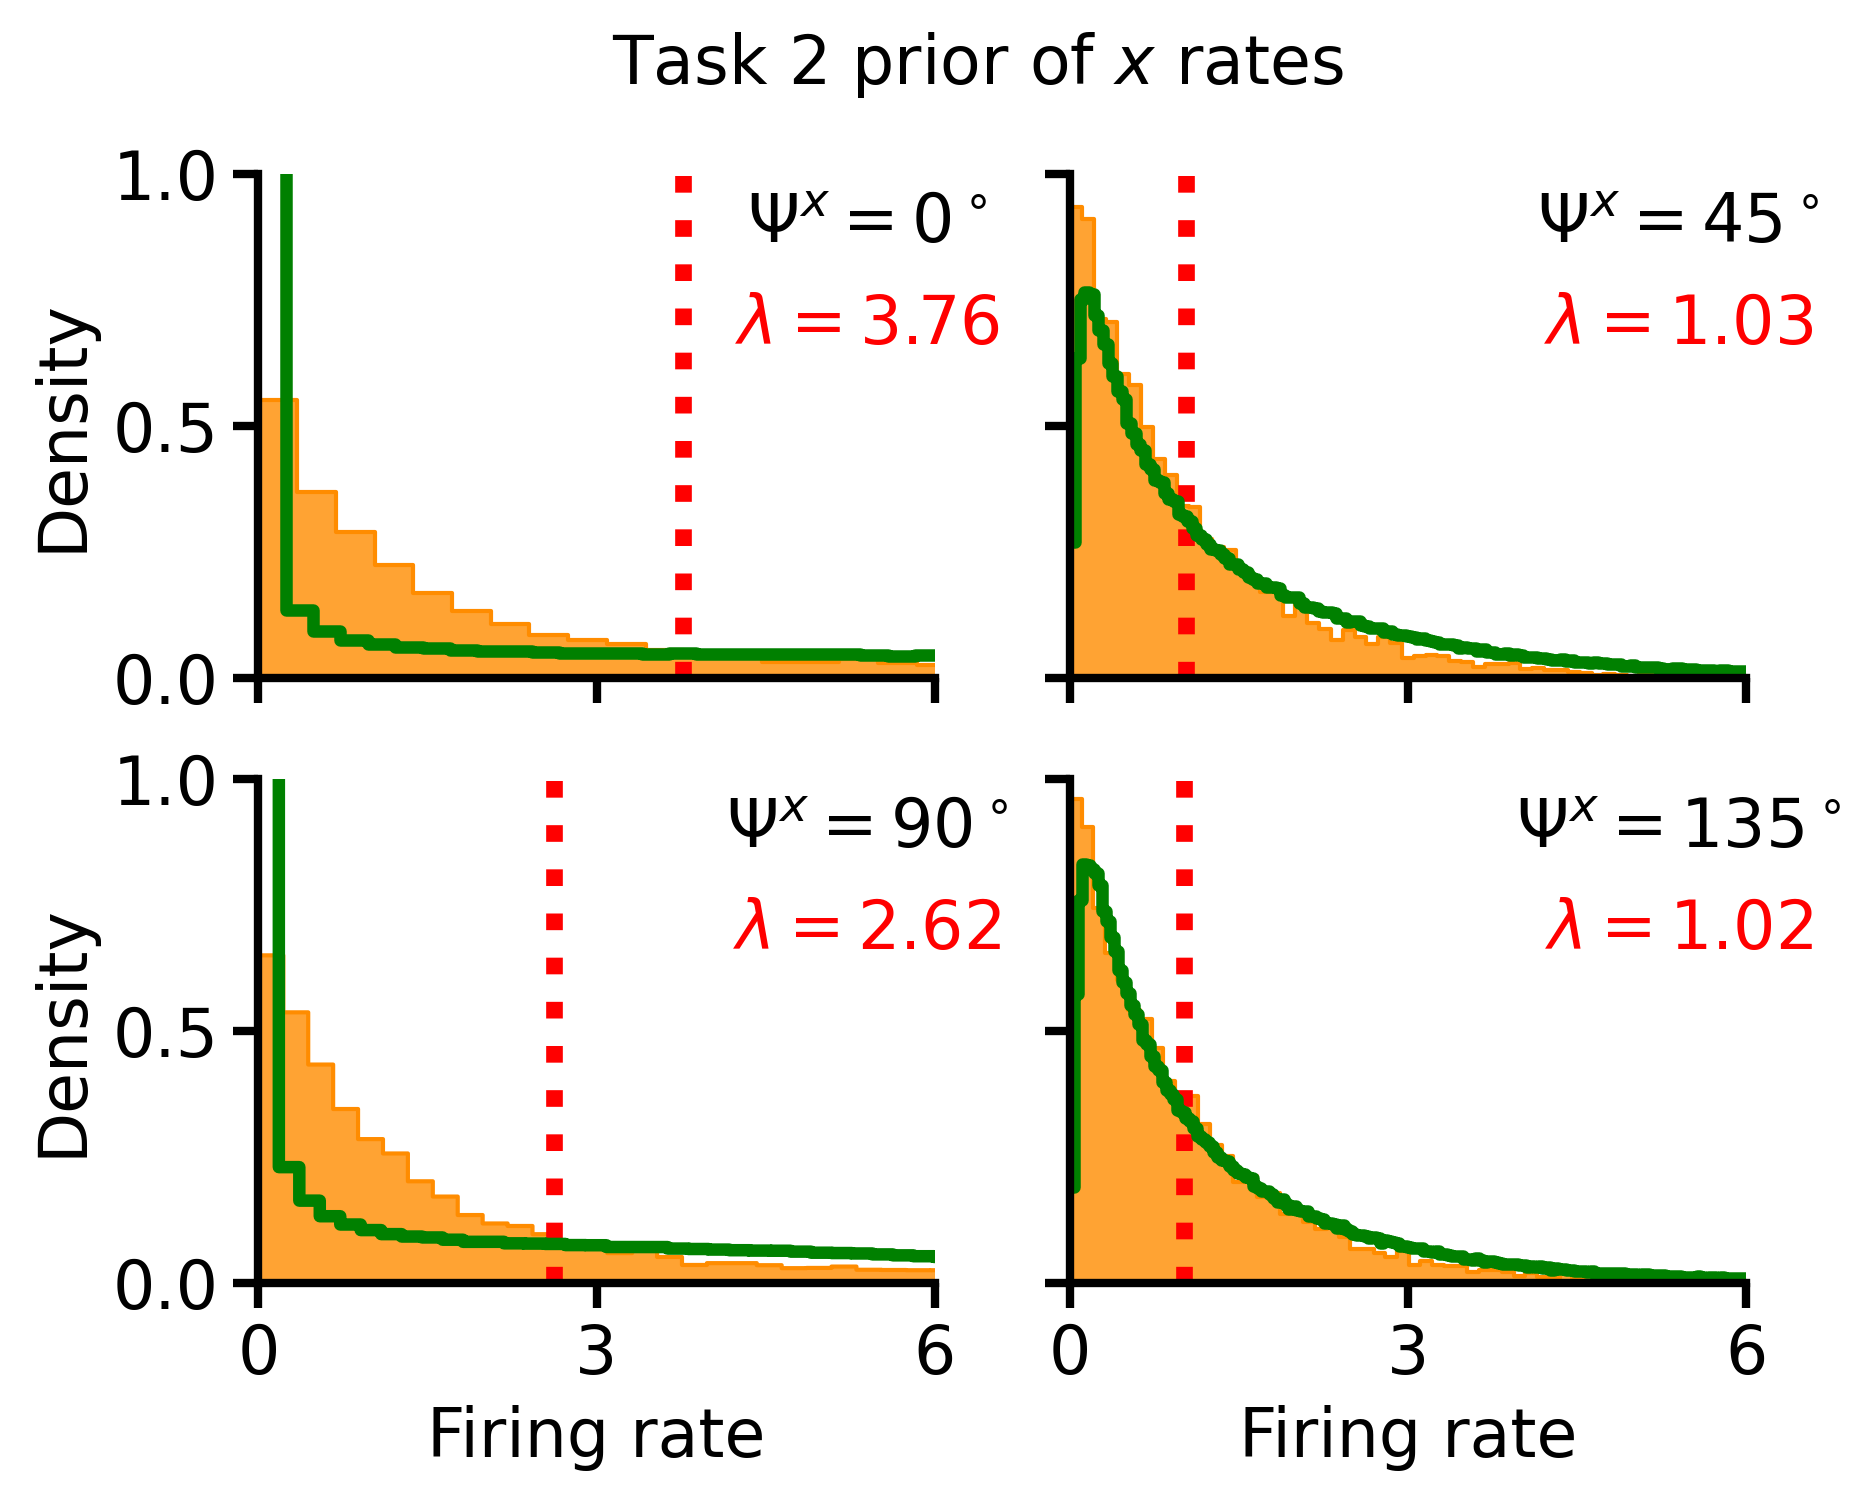

In [24]:
fig_xdist, axs_dist = plt.subplots(2, 2, dpi=dpi, sharex=True, sharey=True)
for idx, ax in enumerate(axs_dist.flatten()):
    sns.histplot(
        task2_x[:, idx],
        ax=ax,
        stat="density",
        element="step",
        # kde=True,
        color="darkorange",
        # label="No task",
        alpha=0.8,
        # linewidth=linewidth,
    )
    ax.text(
        0.9,
        0.9,
        f"$\\Psi^x=${int(np.rad2deg(task2_data_model.x_phi[idx]))}$^\circ$",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=fontsize,
    )
    mean_samples = torch.mean(task2_x[:, idx])
    ax.axvline(mean_samples, color="red", linestyle="dotted", linewidth=linewidth)
    ax.text(
        0.9,
        0.7,
        f"$\\lambda=${mean_samples:.2f}",
        horizontalalignment="center",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize=fontsize,
        color="red",
        label="Mean",
    )
    sns.histplot(
        sbv2_prior_samples[:, idx].detach().numpy(),
        ax=ax,
        stat="density",
        element="step",
        color="green",
        alpha=1,
        label="Model",
        fill=False,
        linewidth=prior_model_linewidth,
    )
    mean_hist_samples = torch.mean(sbv2_prior_samples[:, idx]).item()
    # ax.axvline(
    #     mean_hist_samples, color="blue", linestyle="dotted", linewidth=linewidth
    # )
    # ax.text(
    #     0.7,
    #     0.5,
    #     f"$\\lambda=${mean_hist_samples:.2f}",
    #     horizontalalignment="center",
    #     verticalalignment="center",
    #     transform=ax.transAxes,
    #     fontsize=fontsize,
    #     color="blue",
    #     label="Mean",
    # )
    ax.set_xlim([0, 6])
    ax.set_ylim([0, 1])
    ax.set_xticks(np.arange(0, 7, step=3))
    ax.set_yticks([0, 0.5, 1])
    ax.tick_params(
        axis="both",
        which="both",
        labelsize=fontsize,
        length=tick_length,
        width=tick_width,
    )
    ax.set_ylabel("Density", fontsize=fontsize)
    ax.set_xlabel("Firing rate", fontsize=fontsize)
    sns.despine(ax=ax)
    ax.spines[["left", "bottom"]].set_linewidth(tick_width)
    # ax.axis("equal")
fig_xdist.suptitle("Task 2 prior of $x$ rates", fontsize=fontsize)
# fig_xdist.savefig(xdist_figname, bbox_inches="tight", transparent=True)

In [25]:
image_dim = 1
response_dim = 0
reduction = "none"
uncertainty = "none"
normalize = "none"
unit = "bits"
evaluate_likelihood = lambda model, data_loader: compute_logl(
    model=model,
    data_loader=data_loader,
    data_dim=image_dim,
    cond_dim=response_dim,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [26]:
logl_ix_model_train = evaluate_likelihood(
    model=sbv1_likelihood_model,
    data_loader=train_loader1,
)[0]
logl_ix_model_val = evaluate_likelihood(
    model=sbv1_likelihood_model,
    data_loader=val_loader1,
)[0]
logl_ix_model_test = evaluate_likelihood(
    model=sbv1_likelihood_model,
    data_loader=test_loader1,
)[0]

In [27]:
evaluate_true_likelihood = (
    lambda haefner_model, data_loader: compute_haefner_logl_i_cond_x(
        haefner_model=haefner_model,
        data_loader=data_loader,
        reduction=reduction,
        uncertainty=uncertainty,
        normalize=normalize,
        unit=unit,
    )
)

In [28]:
logl_ix_true_train = evaluate_true_likelihood(
    haefner_model=task1_data_model,
    data_loader=train_loader1,
)[0]
logl_ix_true_val = evaluate_true_likelihood(
    haefner_model=task1_data_model,
    data_loader=val_loader1,
)[0]
logl_ix_true_test = evaluate_true_likelihood(
    haefner_model=task1_data_model,
    data_loader=val_loader1,
)[0]

In [30]:
visualize_conditional_features(
    conditional=sbv1_likelihood_model,
    data_loader=test_loader1,
    epoch="post_learning_4n",
    unit_perturbation=1,
    device="cpu",
    dims_to_plot=range(4),
    fig_dpi=300,
    fig_save_dir=Path("/src/project/experiments/plotting/"),
    n_rows=1,
    n_cols=4
)

In [ ]:
sbv1_likelihood_model

IndependentNormal(
  (trainable_distribution): IndependentTrainableDistributionAdapter(
    distribution_class=<class 'torch.distributions.normal.Normal'>, event_dims=1
    (parameter_generator): LocScale(
      (core_nn): MLP(
        (core_module): Sequential(
          (linear_0): Linear(in_features=4, out_features=144, bias=True)
          (dropout_0): Dropout(p=0.0, inplace=False)
          (nonlin_0): Identity()
        )
      )
      (loc_module): Linear(in_features=144, out_features=144, bias=True)
      (pre_scale_module): Linear(in_features=144, out_features=144, bias=True)
    )
  )
)

In [41]:
pred_test_scales = []
for responses, images in test_loader1:
    dist = sbv1_likelihood_model.trainable_distribution.distribution(
        cond=responses
    ).base_dist
    pred_test_scales.append(dist.scale)
pred_test_scales = torch.cat(pred_test_scales, dim=0).flatten()

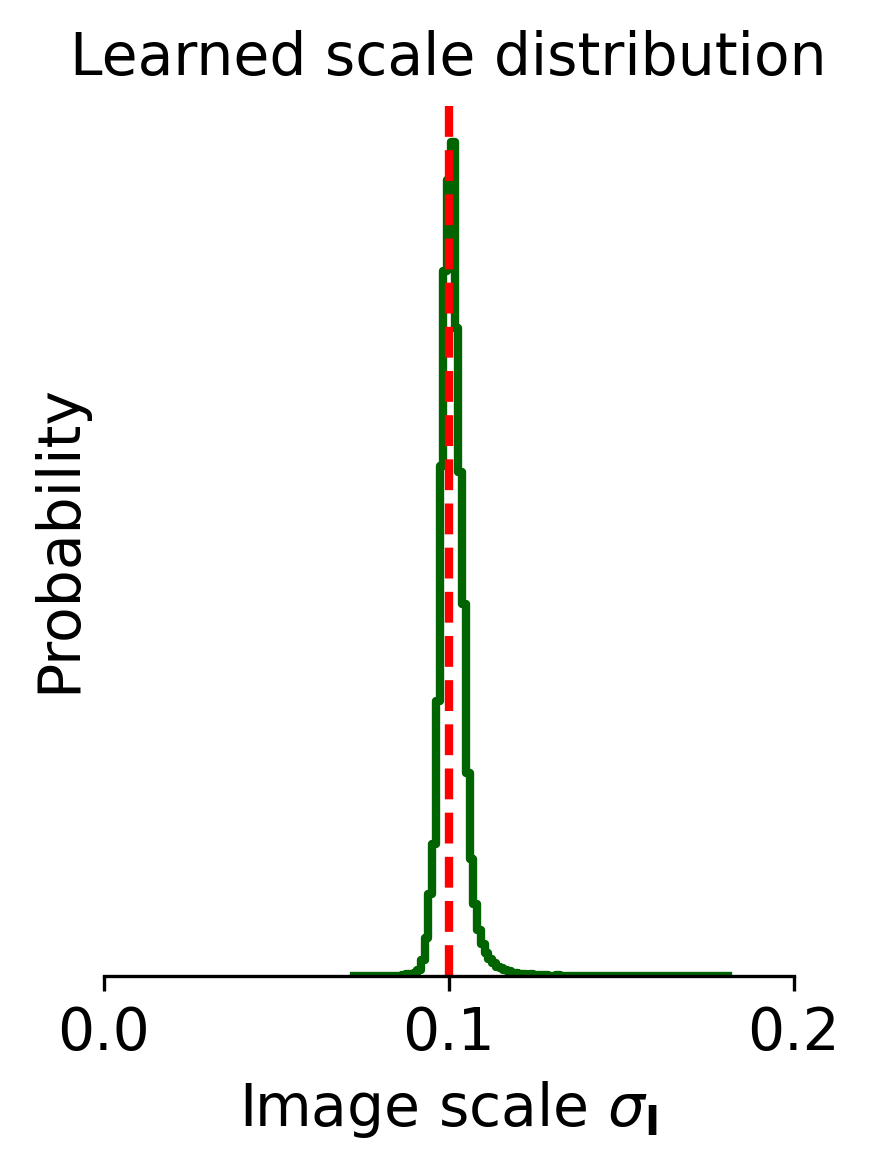

In [87]:
fig, ax = plt.subplots(dpi=300, figsize=(3,4))
sns.histplot(
    pred_test_scales.detach().numpy(),
    bins=100,
    color="darkgreen",
    fill=False,
    element="step",
    ax=ax,
    stat="probability",
    label="Learned",
    linewidth=2,
)
# draw a red line at true scale
plt.axvline(
    task1_data_model.obs_sigma, color="red", linewidth=2, linestyle="--", label="True"
)
ax.set_title("Learned scale distribution", fontsize=14)
ax.set_xlabel("Image scale $\sigma_\mathbf{I}}$", fontsize=14)
ax.set_ylabel("Probability", fontsize=14)
ax.tick_params(axis="both", which="major", labelsize=14)
# ax.set_xticks(np.arange(0.08, 0.12))
ax.set_xlim([0, 0.20])
# ax.legend()
sns.despine(ax=ax, trim=True)
ax.spines["left"].set_visible(False)
ax.set_yticks([])
plt.tight_layout()

In [104]:
evaluate_prior_model = lambda model, data_loader: compute_logl(
    model=model,
    data_loader=data_loader,
    data_dim=response_dim,
    cond_dim=None,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [99]:
evaluate_pred_model = lambda model, data_loader: compute_logl(
    model,
    data_loader,
    data_dim=response_dim,
    cond_dim=image_dim,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [105]:
train_sbv1_prior_data1 = evaluate_prior_model(
    model=sbv1_prior_model,
    data_loader=train_loader1,
)[0]
val_sbv1_prior_data1 = evaluate_prior_model(
    model=sbv1_prior_model,
    data_loader=val_loader1,
)[0]
test_sbv1_prior_data1 = evaluate_prior_model(
    model=sbv1_prior_model,
    data_loader=test_loader1,
)[0]

In [106]:
train_si1_data1 = evaluate_pred_model(si1_model, train_loader1)[0]
val_si1_data1 = evaluate_pred_model(si1_model, val_loader1)[0]
test_si1_data1 = evaluate_pred_model(si1_model, test_loader1)[0]

train_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, train_loader1)[0]
val_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, val_loader1)[0]
test_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, test_loader1)[0]

train_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, train_loader1)[0]
val_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, val_loader1)[0]
test_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, test_loader1)[0]

train_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, train_loader1)[0]
val_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, val_loader1)[0]
test_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, test_loader1)[0]

train_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, train_loader1)[0]
val_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, val_loader1)[0]
test_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, test_loader1)[0]

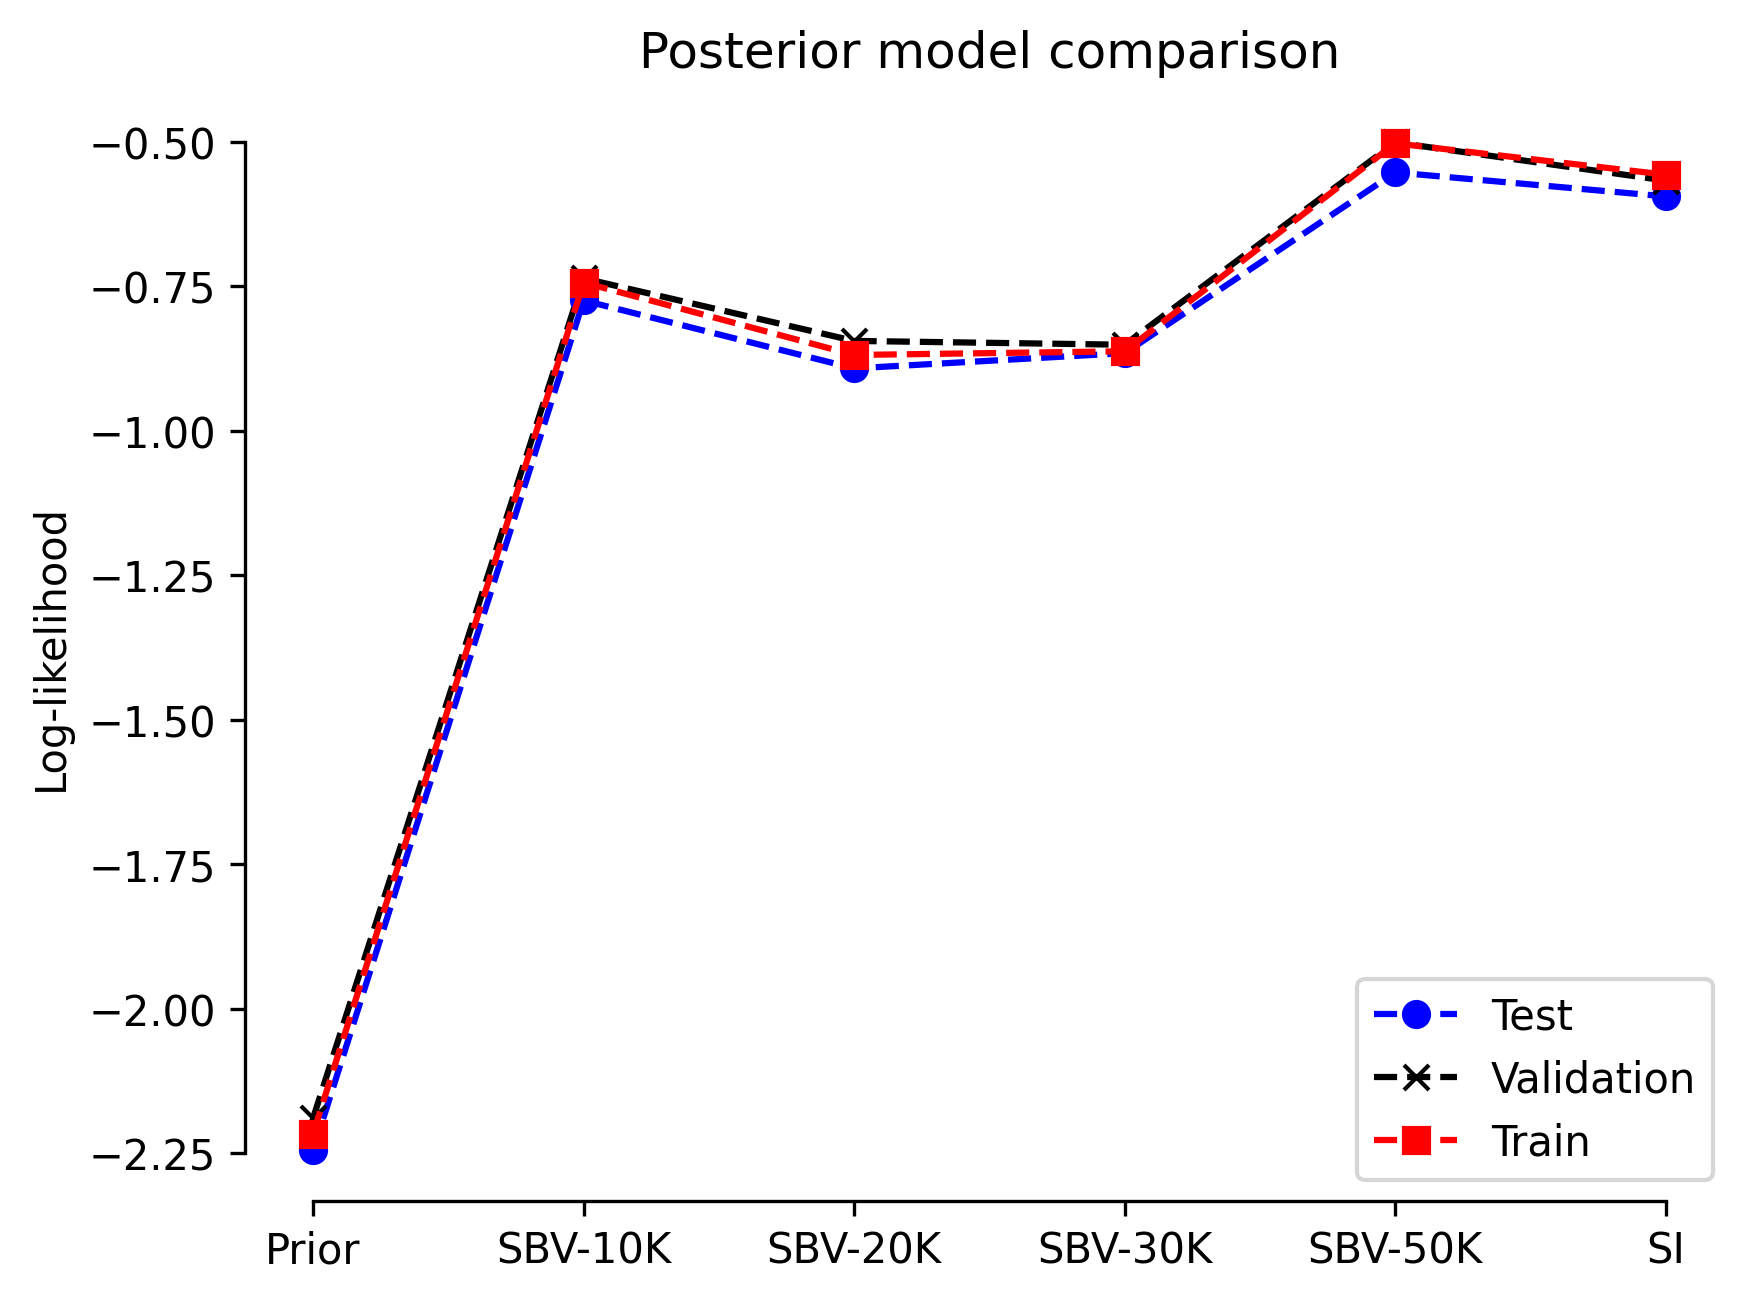

In [107]:
train_metrics_data1 = [
    train_si1_data1,
    train_sbv1_50k_data1,
    train_sbv1_30k_data1,
    train_sbv1_20k_data1,
    train_sbv1_10k_data1,
    train_sbv1_prior_data1,
]
val_metrics_data1 = [
    val_si1_data1,
    val_sbv1_50k_data1,
    val_sbv1_30k_data1,
    val_sbv1_20k_data1,
    val_sbv1_10k_data1,
    val_sbv1_prior_data1,
]
test_metrics_data1 = [
    test_si1_data1,
    test_sbv1_50k_data1,
    test_sbv1_30k_data1,
    test_sbv1_20k_data1,
    test_sbv1_10k_data1,
    test_sbv1_prior_data1,
]

# Update the x-axis labels
x = ["SI", "SBV-50K", "SBV-30K", "SBV-20K", "SBV-10K", "Prior"]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1],
    test_metrics_data1[::-1],
    color="blue",
    marker="o",
    linestyle="--",
    label="Test",
)
ax.plot(
    x[::-1],
    val_metrics_data1[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1],
    train_metrics_data1[::-1],
    color="red",
    marker="s",
    linestyle="--",
    label="Train",
)



sns.despine(ax=ax, trim=True)
ax.set_ylabel("Log-likelihood")
ax.set_title("Predictive performance task 1")
ax.legend()
plt.show()

In [109]:
train_si2_data2 = evaluate_pred_model(si2_model, train_loader2)[0]
val_si2_data2 = evaluate_pred_model(si2_model, val_loader2)[0]
test_si2_data2 = evaluate_pred_model(si2_model, test_loader2)[0]

train_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, train_loader2)[0]
val_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, val_loader2)[0]
test_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, test_loader2)[0]

train_sbv2_30k_data2 = evaluate_pred_model(sbv2_50k_model, train_loader2)[0]
val_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, val_loader2)[0]
test_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, test_loader2)[0]

train_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, train_loader2)[0]
val_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, val_loader2)[0]
test_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, test_loader2)[0]

train_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, train_loader2)[0]
val_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, val_loader2)[0]
test_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, test_loader2)[0]

train_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, train_loader2)[0]
val_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, val_loader2)[0]
test_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, test_loader2)[0]

train_si1_data2 = evaluate_pred_model(si1_model, train_loader2)[0]
val_si1_data2 = evaluate_pred_model(si1_model, val_loader2)[0]
test_si1_data2 = evaluate_pred_model(si1_model, test_loader2)[0]

train_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, train_loader2)[0]
val_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, val_loader2)[0]
test_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, test_loader2)[0]

train_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, train_loader2)[0]
val_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, val_loader2)[0]
test_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, test_loader2)[0]

train_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, train_loader2)[0]
val_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, val_loader2)[0]
test_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, test_loader2)[0]

train_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, train_loader2)[0]
val_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, val_loader2)[0]
test_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, test_loader2)[0]

train_sbv2_prior_data2 = evaluate_prior_model(sbv2_prior_model,train_loader2)[0]
val_sbv2_prior_data2 = evaluate_prior_model(sbv2_prior_model,val_loader2)[0]
test_sbv2_prior_data2 = evaluate_prior_model(sbv2_prior_model, test_loader2)[0]

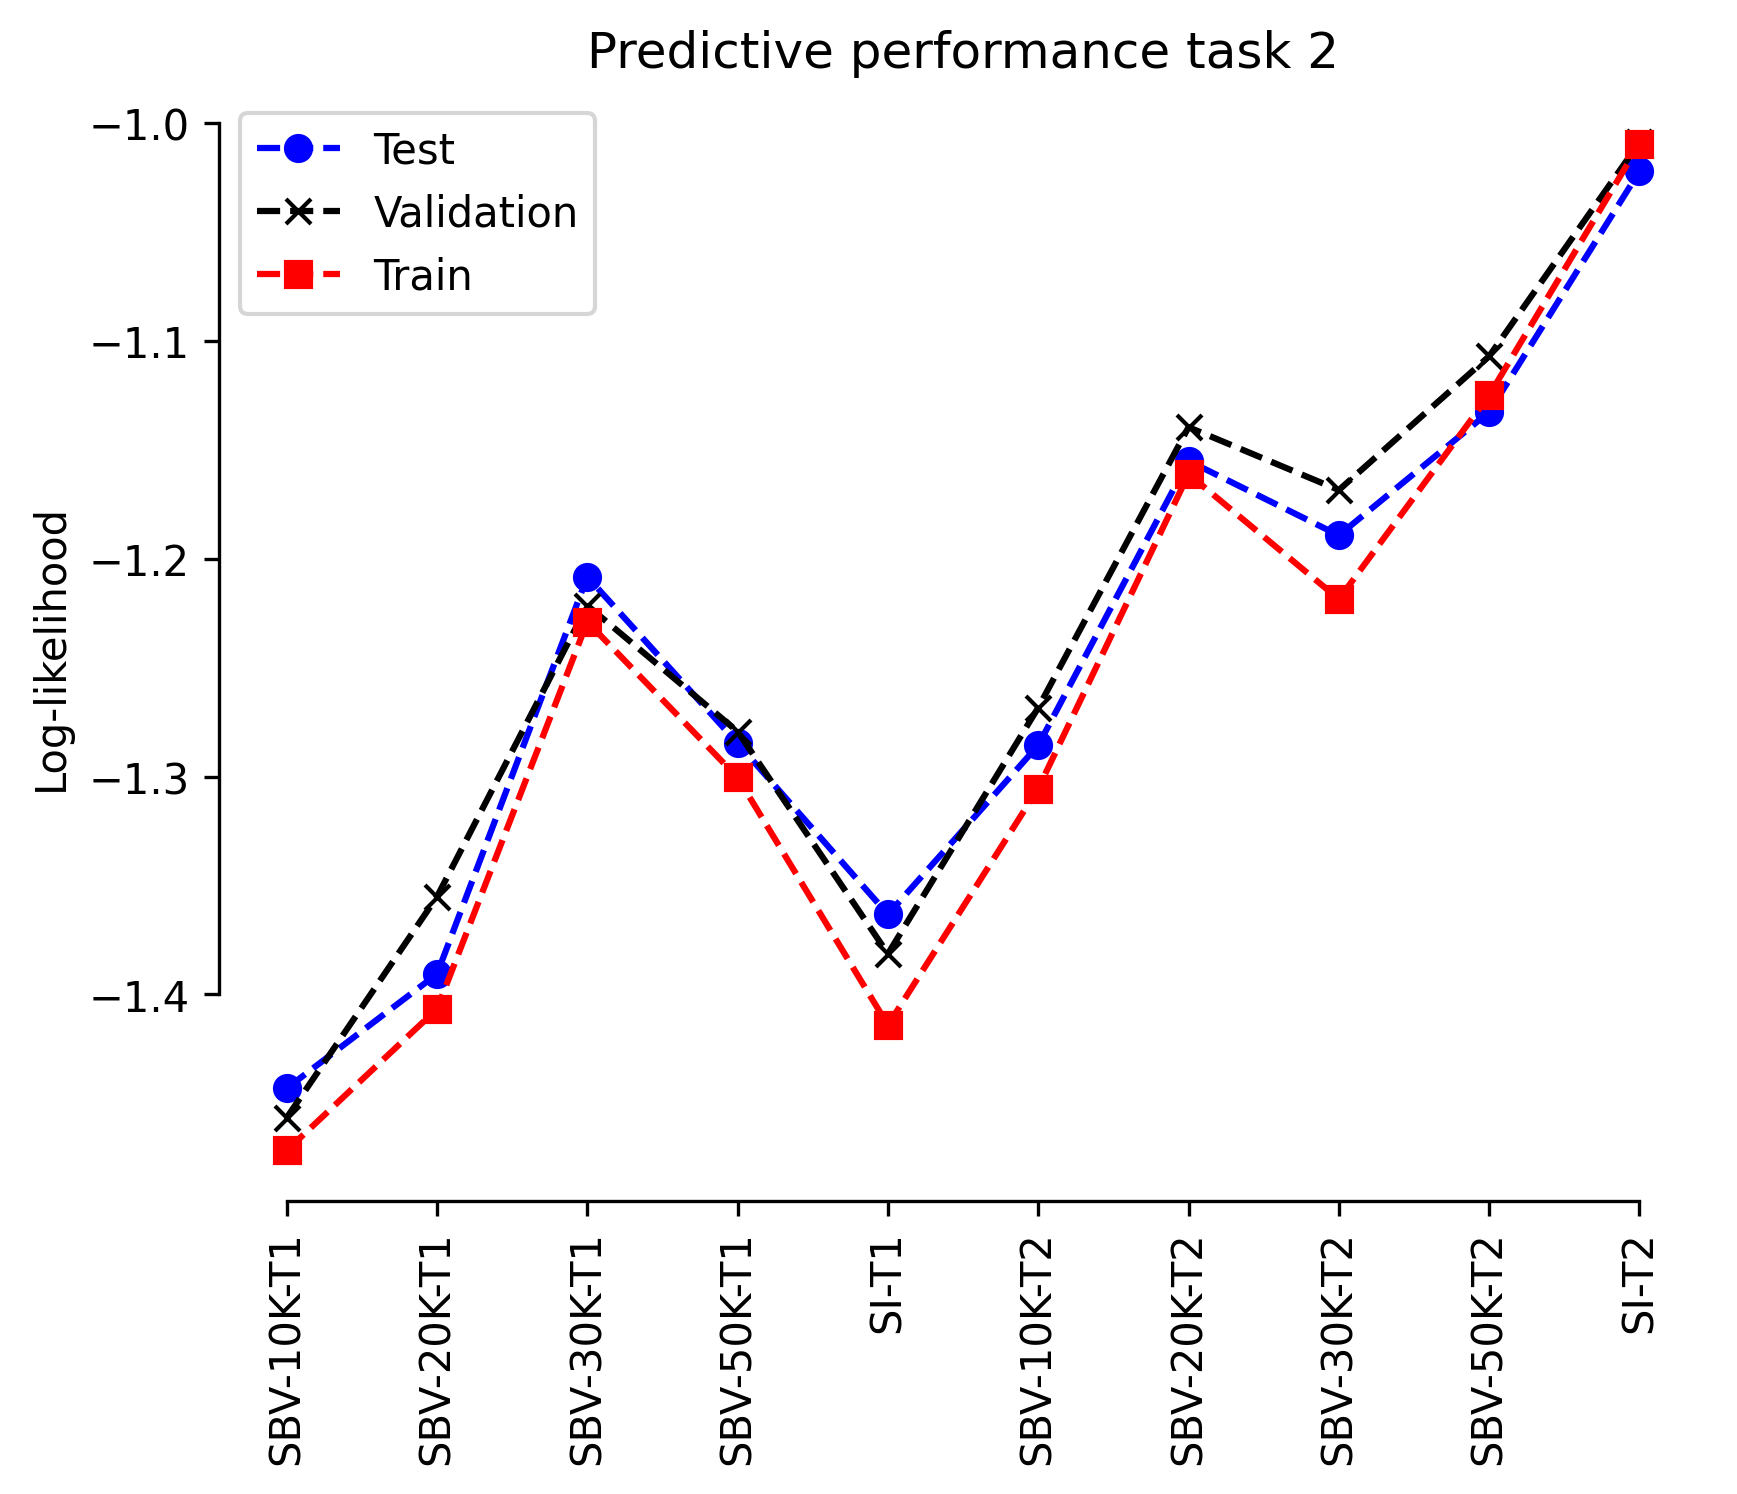

In [114]:
train_metrics_data2 = [
    train_si2_data2,
    train_sbv2_50k_data2,
    train_sbv2_30k_data2,
    train_sbv2_20k_data2,
    train_sbv2_10k_data2,
    train_si1_data2,
    train_sbv1_50k_data2,
    train_sbv1_30k_data2,
    train_sbv1_20k_data2,
    train_sbv1_10k_data2,
    # train_sbv2_prior_data2,
]

val_metrics_data2 = [
    val_si2_data2,
    val_sbv2_50k_data2,
    val_sbv2_30k_data2,
    val_sbv2_20k_data2,
    val_sbv2_10k_data2,
    val_si1_data2,
    val_sbv1_50k_data2,
    val_sbv1_30k_data2,
    val_sbv1_20k_data2,
    val_sbv1_10k_data2,
    # val_sbv2_prior_data2,
]

test_metrics_data2 = [
    test_si2_data2,
    test_sbv2_50k_data2,
    test_sbv2_30k_data2,
    test_sbv2_20k_data2,
    test_sbv2_10k_data2,
    test_si1_data2,
    test_sbv1_50k_data2,
    test_sbv1_30k_data2,
    test_sbv1_20k_data2,
    test_sbv1_10k_data2,
    # test_sbv2_prior_data2,
]

# Update the x-axis labels
x = [
    "SI-T2",
    "SBV-50K-T2",
    "SBV-30K-T2",
    "SBV-20K-T2",
    "SBV-10K-T2",
    "SI-T1",
    "SBV-50K-T1",
    "SBV-30K-T1",
    "SBV-20K-T1",
    "SBV-10K-T1",
    # "Prior-T2",
]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1],
    test_metrics_data2[::-1],
    color="blue",
    marker="o",
    linestyle="--",
    label="Test",
)
ax.plot(
    x[::-1],
    val_metrics_data2[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1],
    train_metrics_data2[::-1],
    color="red",
    marker="s",
    linestyle="--",
    label="Train",
)
sns.despine(ax=ax, trim=True)
# rotate the x-axis labels
plt.xticks(rotation=90)
ax.set_ylabel("Log-likelihood")
ax.set_title("Predictive performance task 2")
ax.legend()
plt.show()

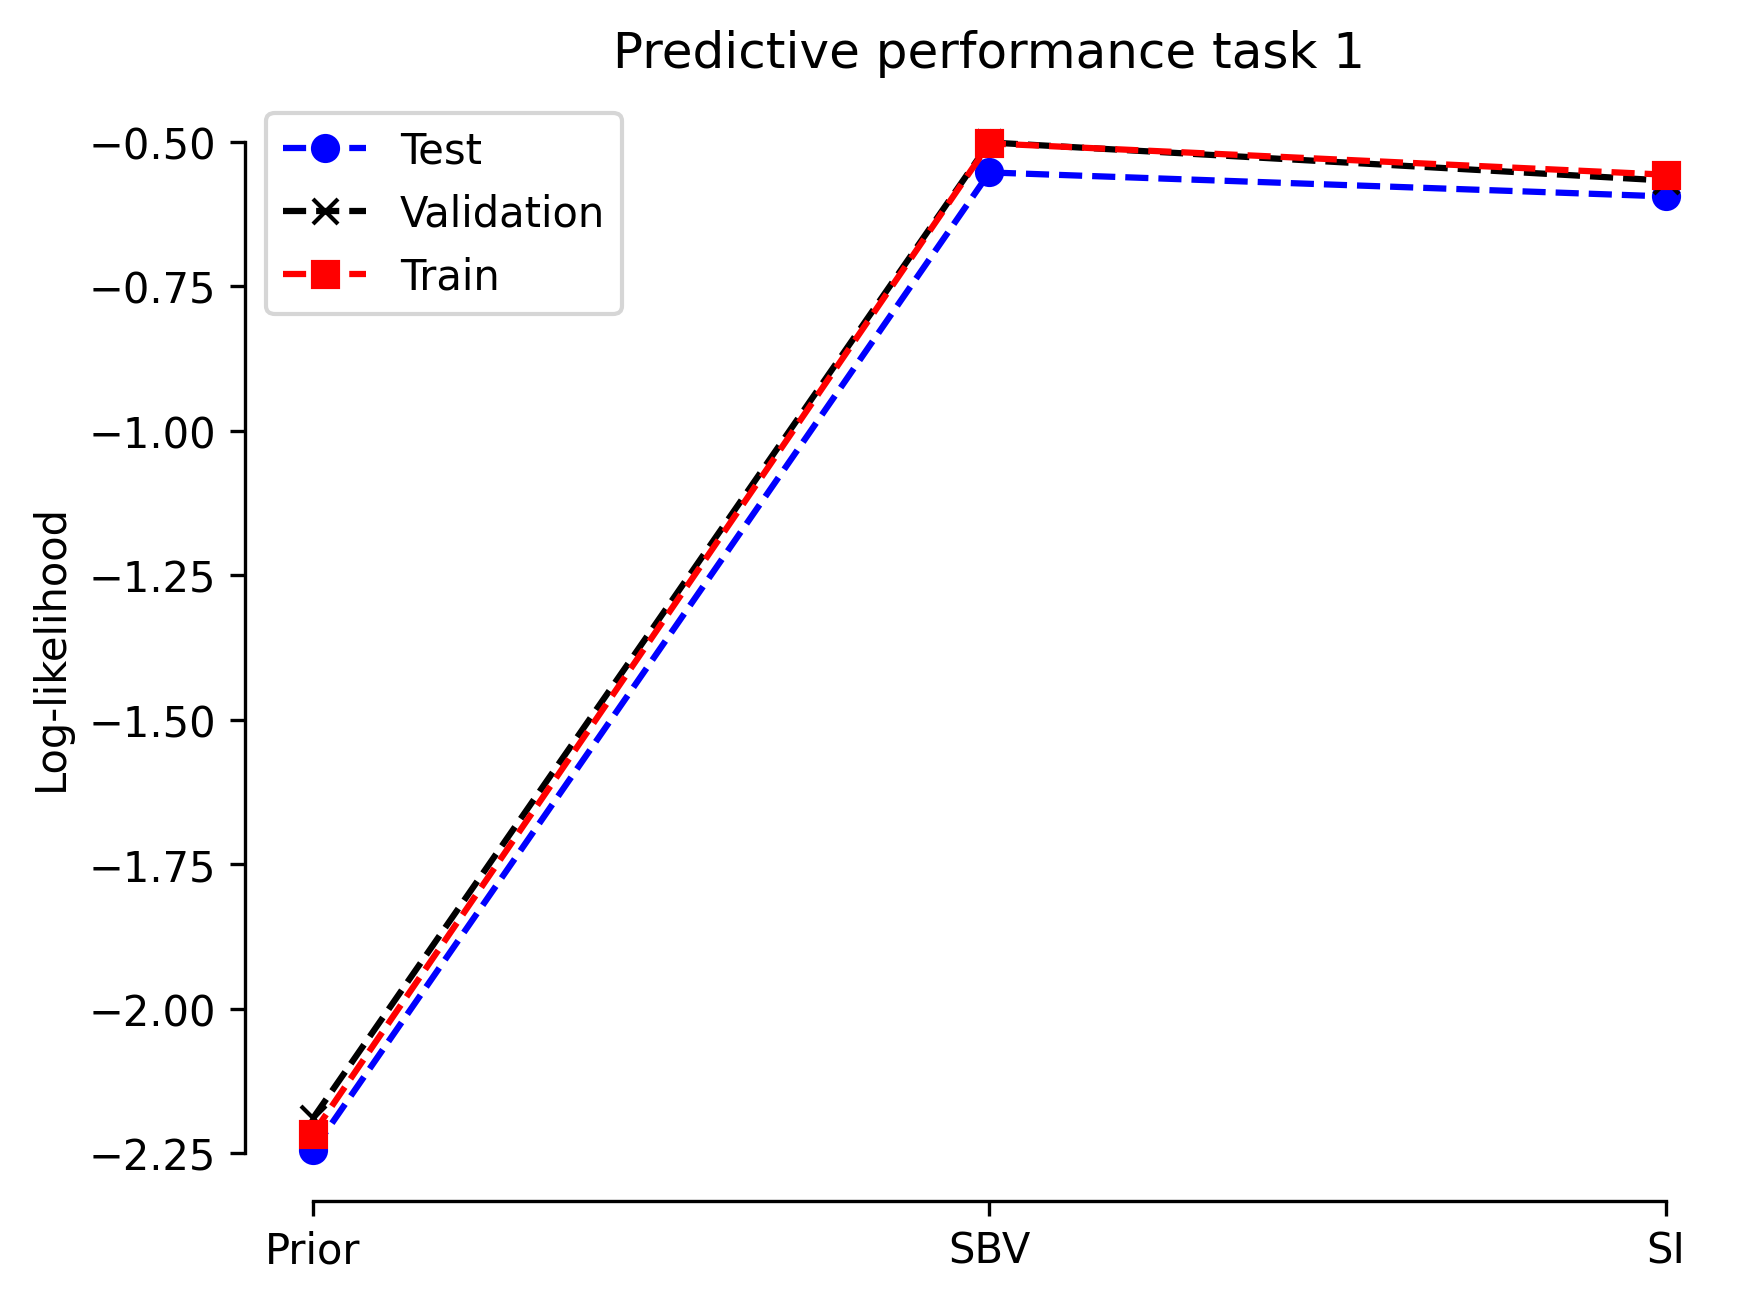

In [115]:
train_metrics_data1 = [
    train_si1_data1,
    train_sbv1_50k_data1,
    # train_sbv1_30k_data1,
    # train_sbv1_20k_data1,
    # train_sbv1_10k_data1,
    train_sbv1_prior_data1,
]
val_metrics_data1 = [
    val_si1_data1,
    val_sbv1_50k_data1,
    # val_sbv1_30k_data1,
    # val_sbv1_20k_data1,
    # val_sbv1_10k_data1,
    val_sbv1_prior_data1,
]
test_metrics_data1 = [
    test_si1_data1,
    test_sbv1_50k_data1,
    # test_sbv1_30k_data1,
    # test_sbv1_20k_data1,
    # test_sbv1_10k_data1,
    test_sbv1_prior_data1,
]

# Update the x-axis labels
x = [
    "SI", 
    "SBV",
    # "SBV-30K",
    # "SBV-20K",
    # "SBV-10K", 
    "Prior",
]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1],
    test_metrics_data1[::-1],
    color="blue",
    marker="o",
    linestyle="--",
    label="Test",
)
ax.plot(
    x[::-1],
    val_metrics_data1[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1],
    train_metrics_data1[::-1],
    color="red",
    marker="s",
    linestyle="--",
    label="Train",
)

sns.despine(ax=ax, trim=True)
ax.set_ylabel("Log-likelihood")
ax.set_title("Predictive performance task 1")
ax.legend()
plt.show()

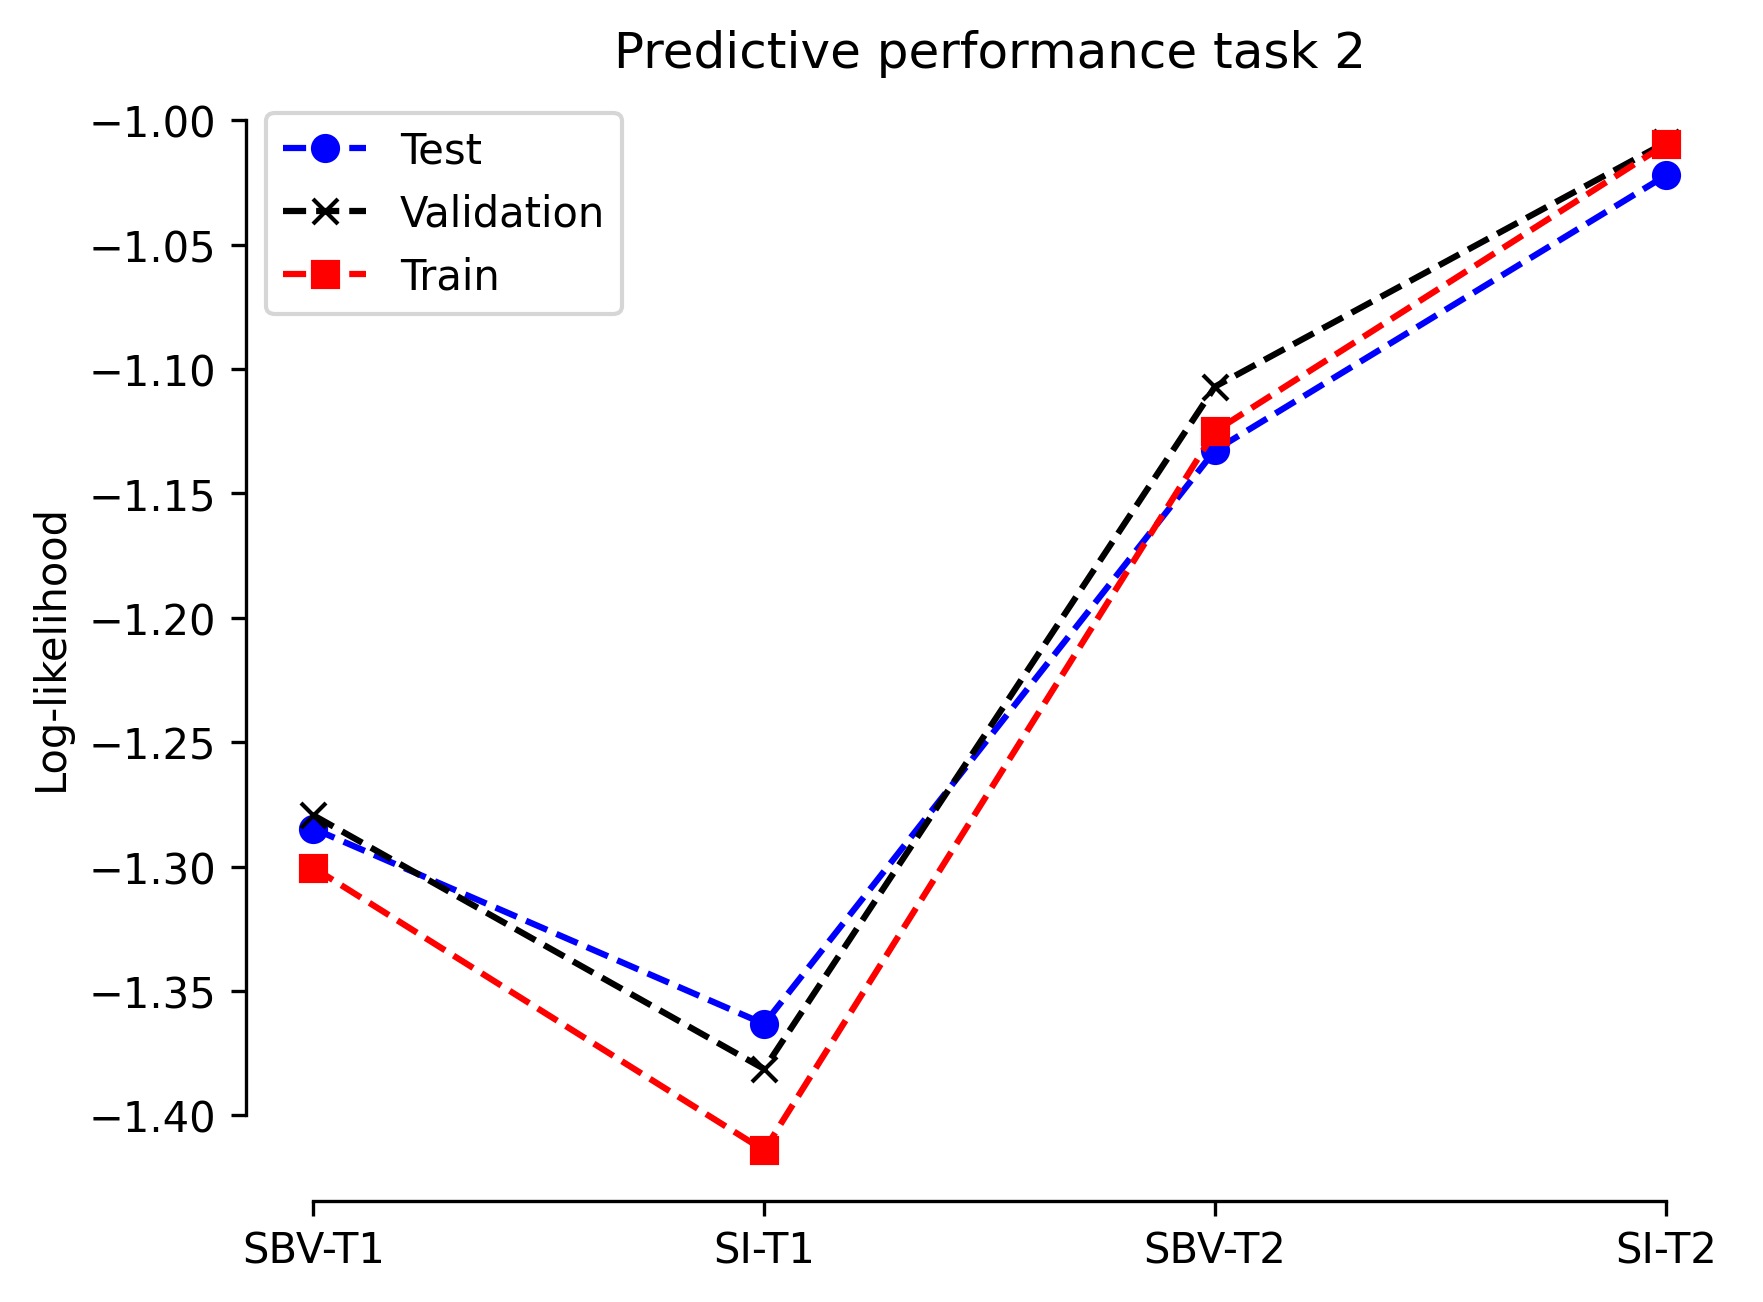

In [117]:
train_metrics_data2 = [
    train_si2_data2,
    train_sbv2_50k_data2,
    # train_sbv2_30k_data2,
    # train_sbv2_20k_data2,
    # train_sbv2_10k_data2,
    train_si1_data2,
    train_sbv1_50k_data2,
    # train_sbv1_30k_data2,
    # train_sbv1_20k_data2,
    # train_sbv1_10k_data2,
    # train_sbv2_prior_data2,
]

val_metrics_data2 = [
    val_si2_data2,
    val_sbv2_50k_data2,
    # val_sbv2_30k_data2,
    # val_sbv2_20k_data2,
    # val_sbv2_10k_data2,
    val_si1_data2,
    val_sbv1_50k_data2,
    # val_sbv1_30k_data2,
    # val_sbv1_20k_data2,
    # val_sbv1_10k_data2,
    # val_sbv2_prior_data2,
]

test_metrics_data2 = [
    test_si2_data2,
    test_sbv2_50k_data2,
    # test_sbv2_30k_data2,
    # test_sbv2_20k_data2,
    # test_sbv2_10k_data2,
    test_si1_data2,
    test_sbv1_50k_data2,
    # test_sbv1_30k_data2,
    # test_sbv1_20k_data2,
    # test_sbv1_10k_data2,
    # test_sbv2_prior_data2,
]

# Update the x-axis labels
x = [
    "SI-T2",
    "SBV-T2",
    # "SBV-30K-T2",
    # "SBV-20K-T2",
    # "SBV-10K-T2",
    "SI-T1",
    "SBV-T1",
    # "SBV-30K-T1",
    # "SBV-20K-T1",
    # "SBV-10K-T1",
    # "Prior-T2",
]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1],
    test_metrics_data2[::-1],
    color="blue",
    marker="o",
    linestyle="--",
    label="Test",
)
ax.plot(
    x[::-1],
    val_metrics_data2[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1],
    train_metrics_data2[::-1],
    color="red",
    marker="s",
    linestyle="--",
    label="Train",
)
sns.despine(ax=ax, trim=True)
# rotate the x-axis labels
# plt.xticks()
ax.set_ylabel("Log-likelihood")
ax.set_title("Predictive performance task 2")
ax.legend()
plt.show()

In [118]:
stimuli = task1_data_model.x_pfs

In [130]:
def plot_predictive_means_and_task_prior(
    means,
    task_params={
        "orientations": torch.linspace(0, np.pi, steps=45 + 1)[:-1],
        "c1_psi": np.pi / 4,
        "c2_psi": 3 * np.pi / 4,
    },
    plotting_params={
        "dpi": 300,
        "bar_color": "olivedrab",
        "bar_edgecolor": "black",
        "fontsize": 16,
        "linewidth": 4,
        "tick_length": 6,
        "tick_width": 2,
        "save_path": "/tmp.pdf",
        "label": "Avg firing rate $x_i$",
        "legend": False,
        "legend_loc": "upper right",
        "legend_fontsize": 16,
    },
):
    all_orientations = torch.linspace(0, torch.pi, steps=1000)
    c1_orientation_density = cos2_von_mises(
        all_orientations, task_params["c1_psi"], 1.0
    )
    c2_orientation_density = cos2_von_mises(
        all_orientations, task_params["c2_psi"], 1.0
    )
    prior = 0.5 * c1_orientation_density + 0.5 * c2_orientation_density
    fig, ax = plt.subplots(dpi=plotting_params["dpi"])
    xticks = np.array([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi])
    ax.set_xticks(xticks)
    ax.set_xticklabels(f"{int(xtick)}$^\circ$" for xtick in xticks * 180 / np.pi)
    ax.set_xlabel(
        "Orientation preference $\\psi^x$ ($^\circ$)",
        fontsize=plotting_params["fontsize"],
    )
    ax.bar(
        task_params["orientations"],
        means,
        width=np.pi / len(task_params["orientations"]),
        color=plotting_params["bar_color"],
        edgecolor=plotting_params["bar_edgecolor"],
        label=plotting_params["label"],
    )
    # ax.plot(
    #     task_params["orientations"],
    #     prior,
    #     color="orange",
    #     linestyle="--",
    #     label="Prior $\\theta$",
    #     linewidth=plotting_params["linewidth"],
    # )
    ax.tick_params(
        axis="both",
        which="major",
        labelsize=plotting_params["fontsize"],
        length=plotting_params["tick_length"],
        width=plotting_params["tick_width"],
    )
    # ax.set_ylim(0, 1)
    ax.set_ylabel("Avg firing rate", fontsize=plotting_params["fontsize"])
    sns.despine(ax=ax, trim=True)
    ax.spines[["left", "bottom"]].set_visible(True)
    ax.spines[["left", "bottom"]].set_linewidth(plotting_params["tick_width"])
    if plotting_params["legend"]:
        ax.legend(
            loc=plotting_params["legend_loc"],
            fontsize=plotting_params["legend_fontsize"],
        )
    # fig.savefig(plotting_params["save_path"], bbox_inches="tight")
    # plt.close(fig)

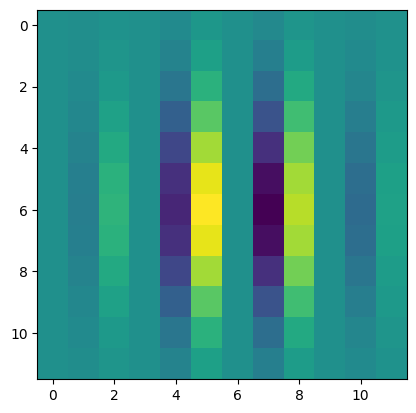

In [133]:
plt.imshow(stimuli[0])

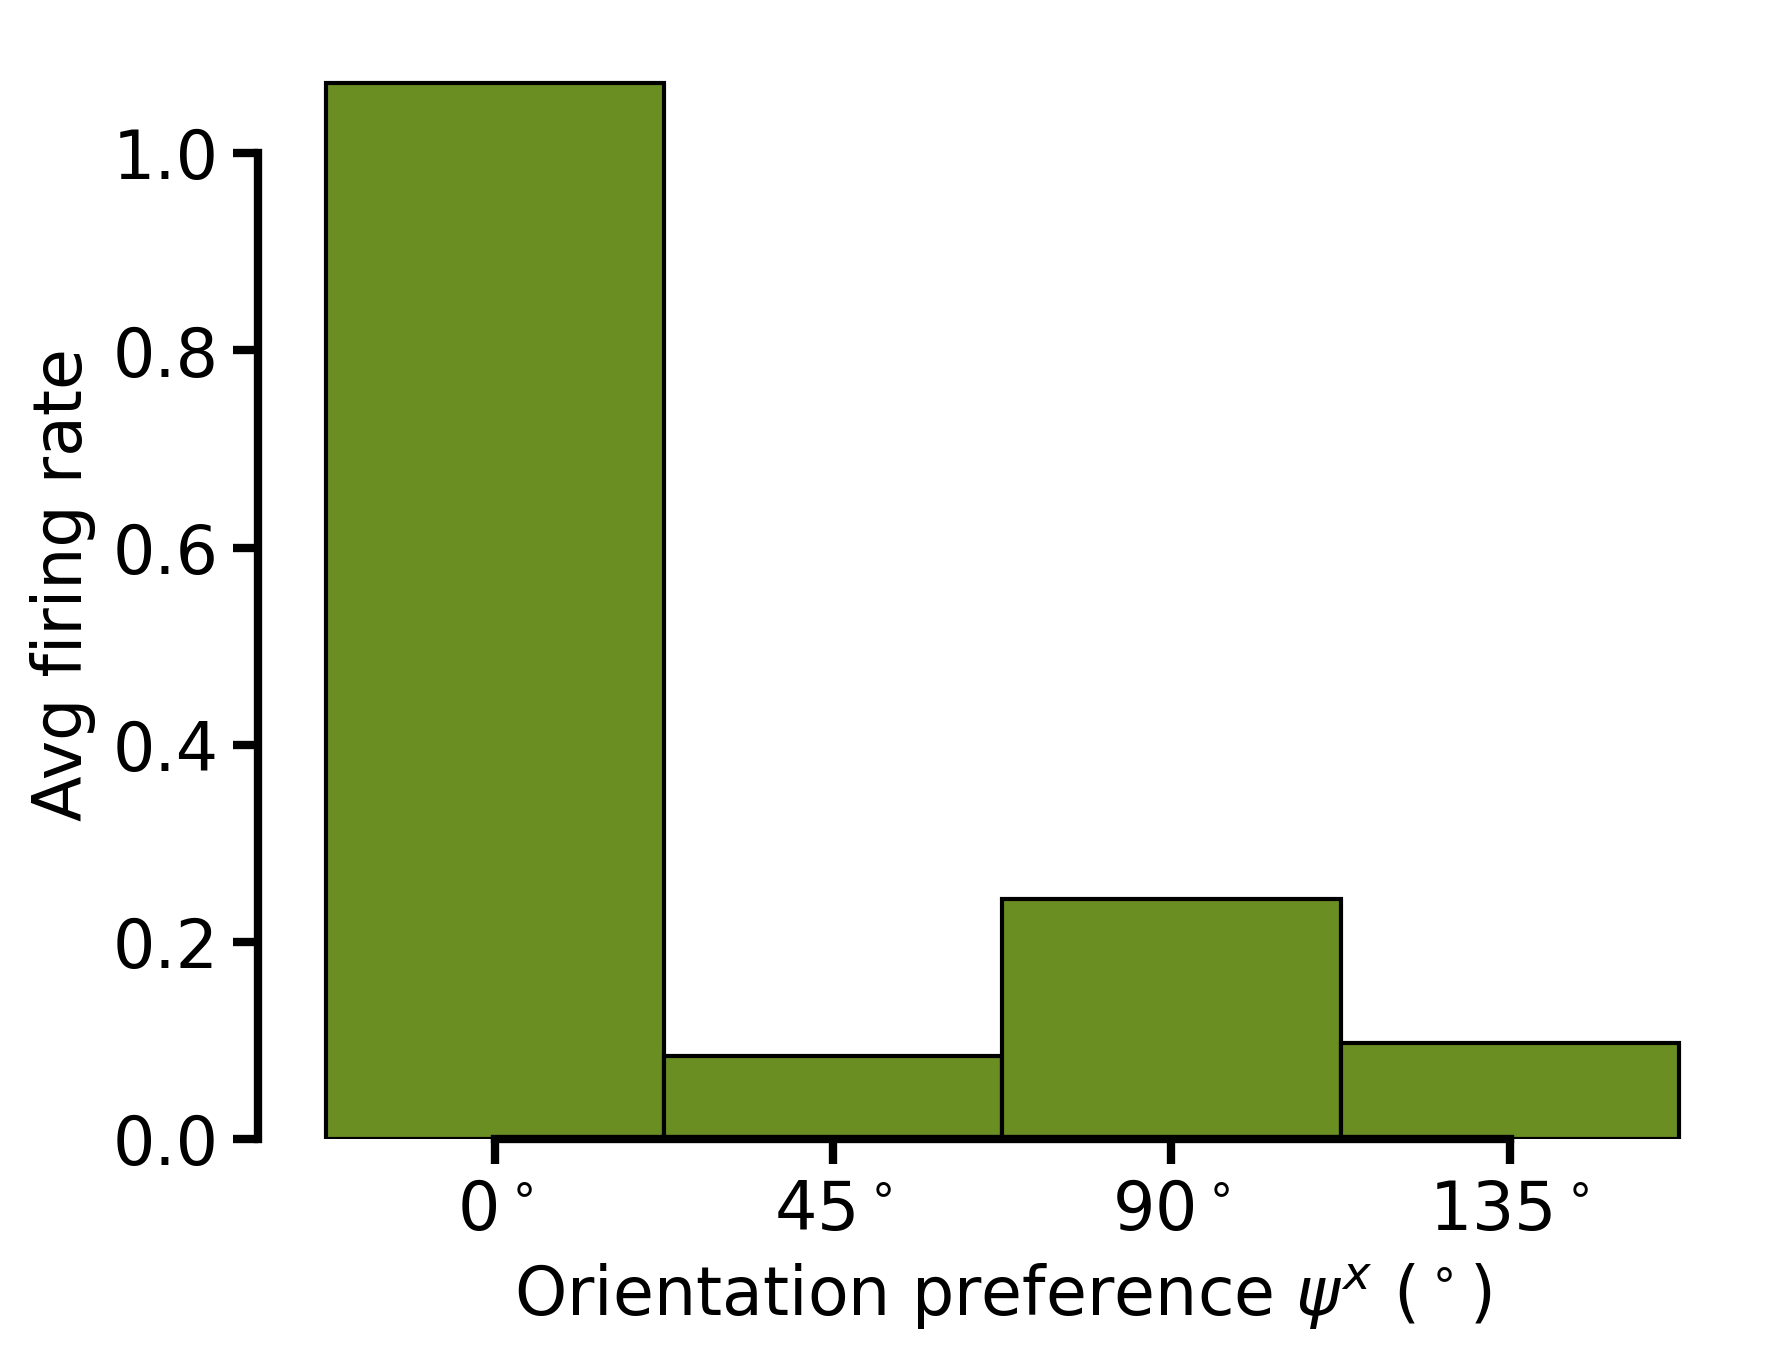

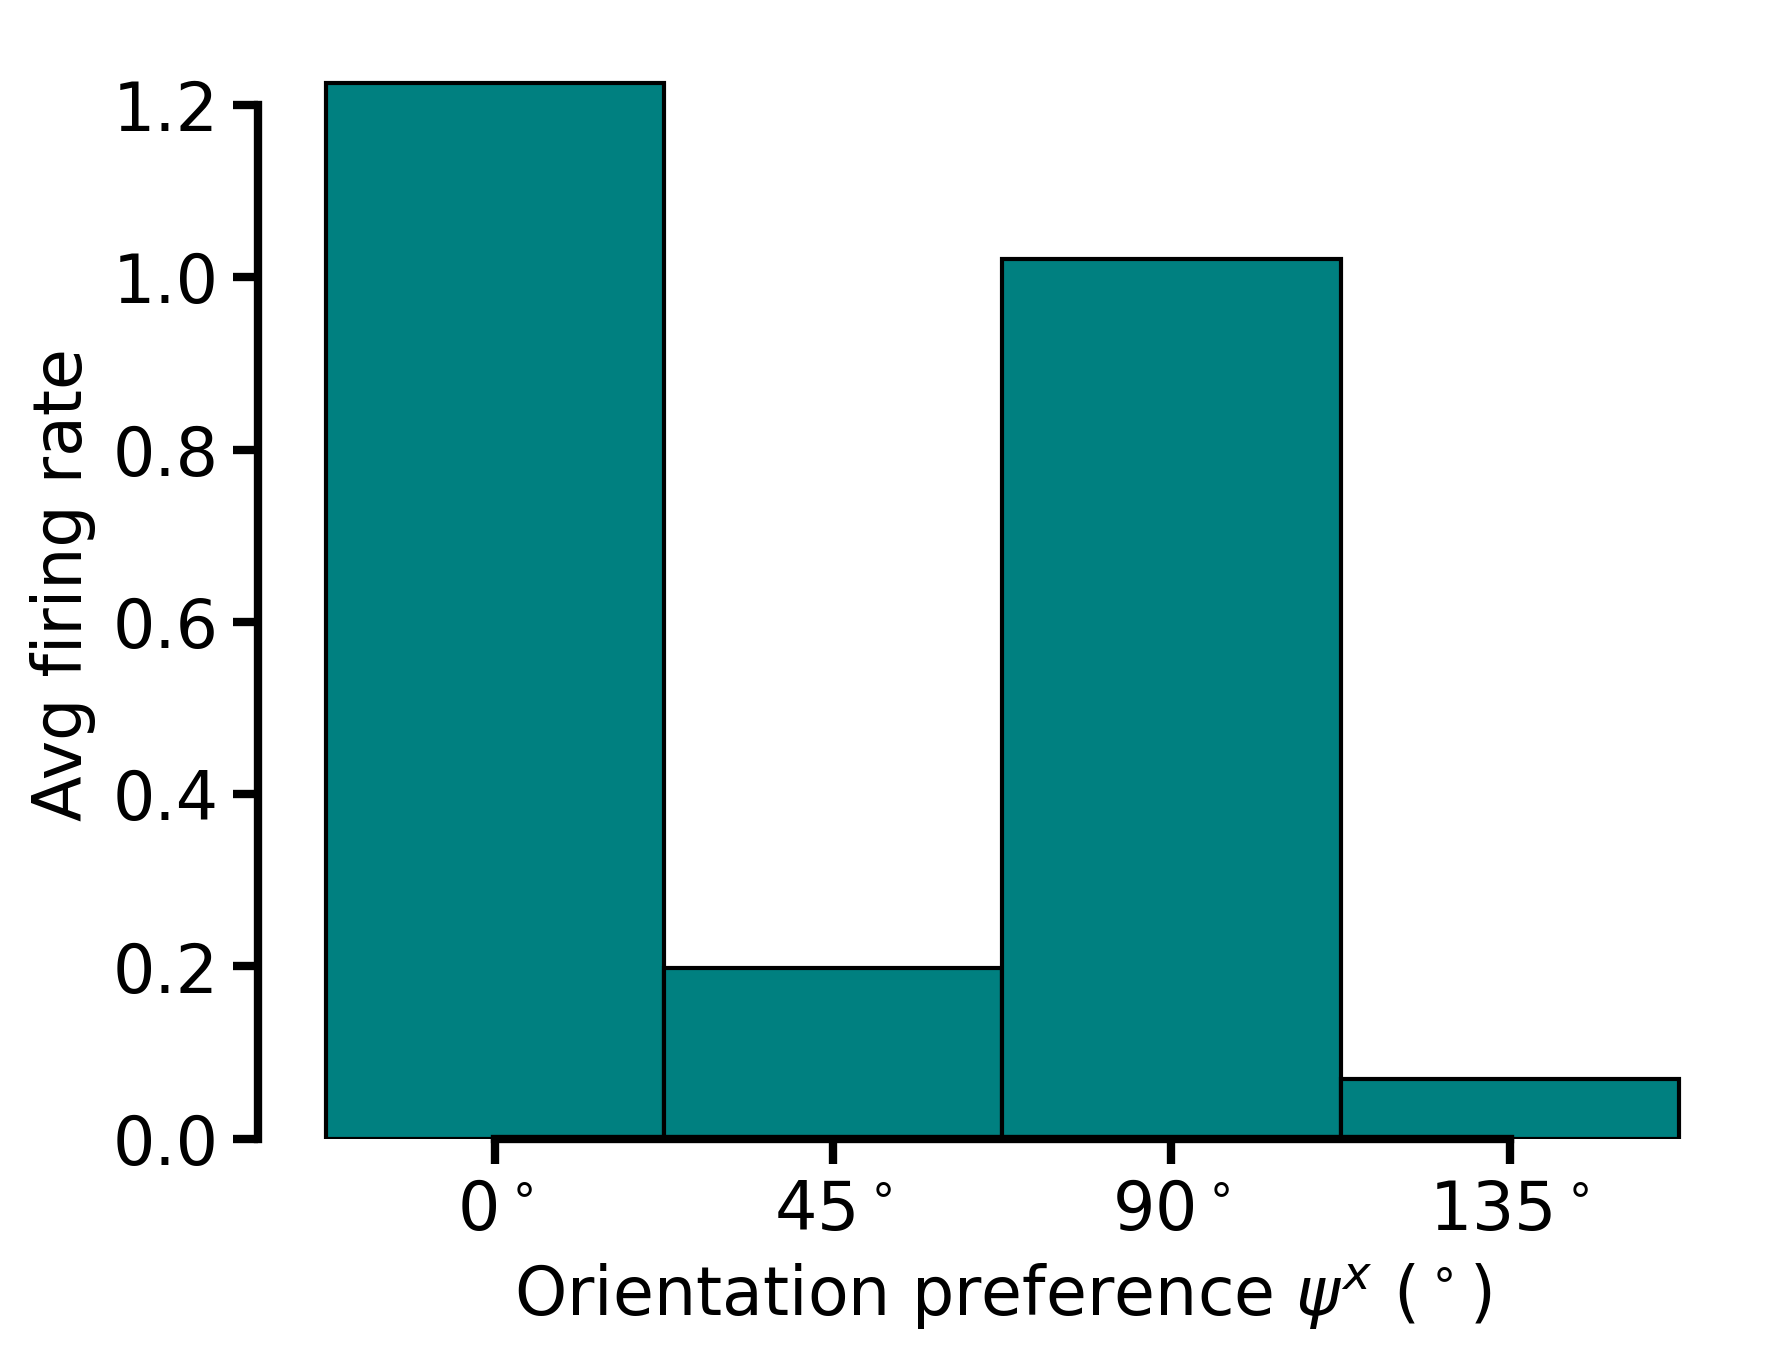

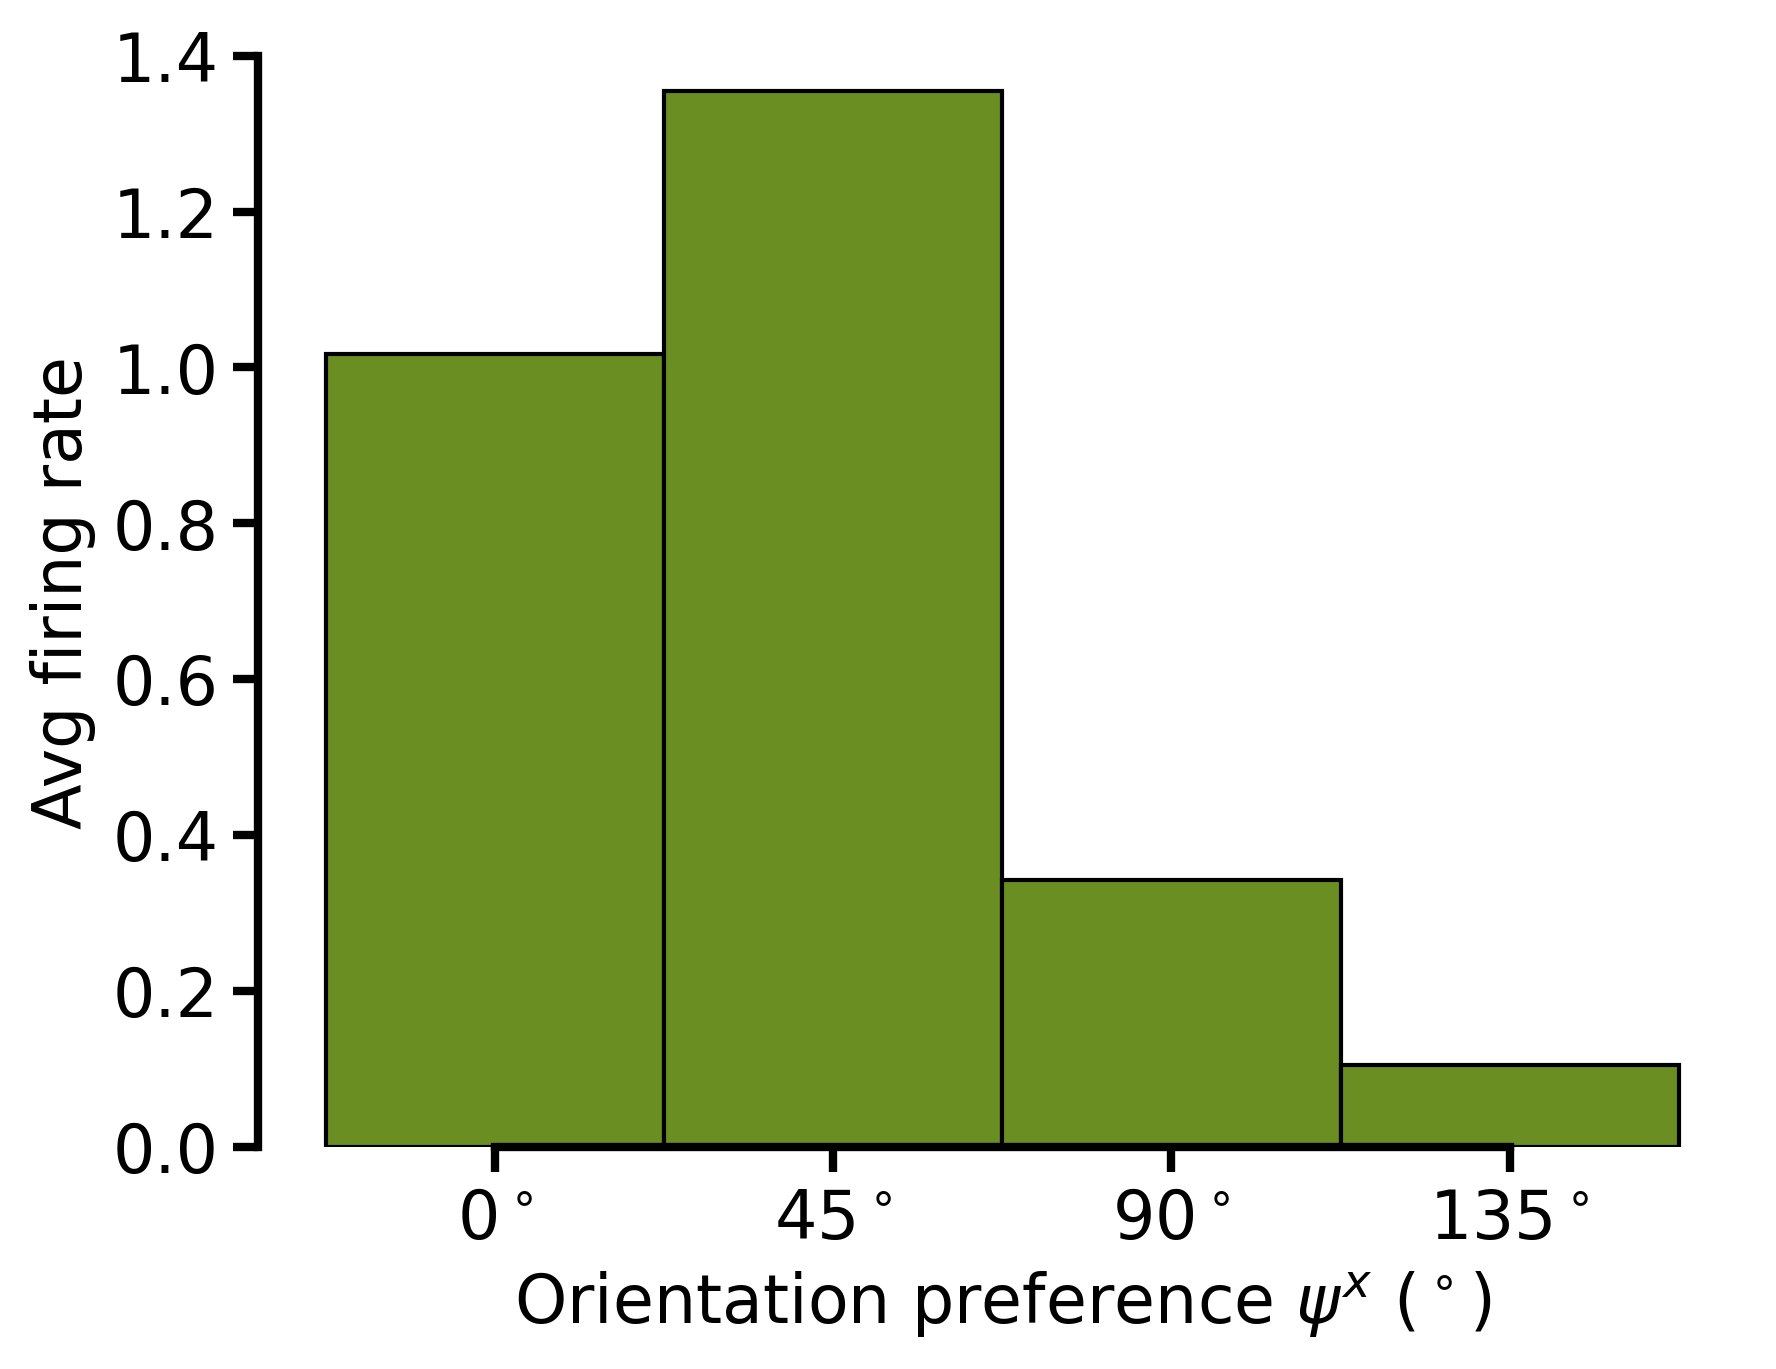

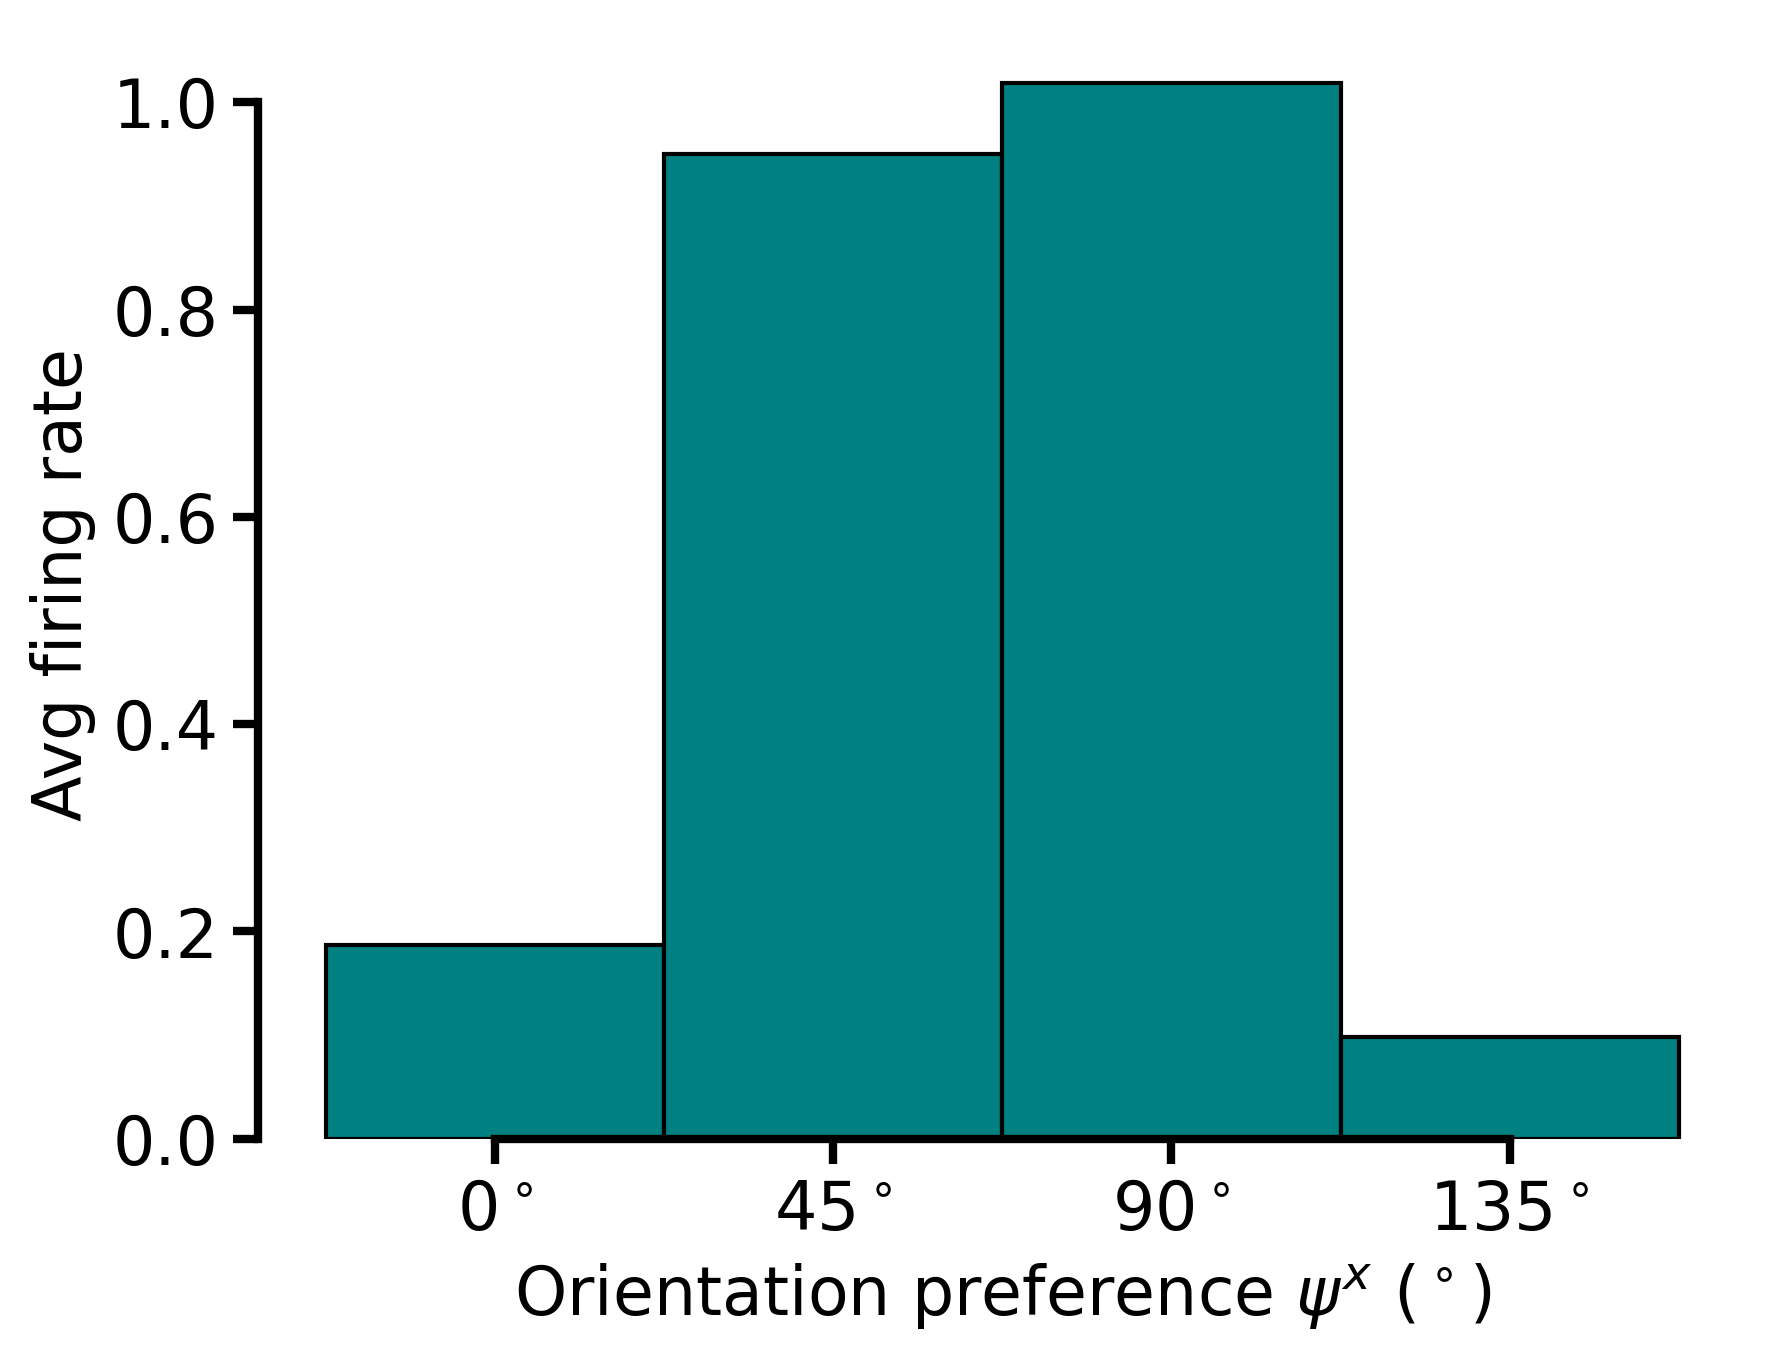

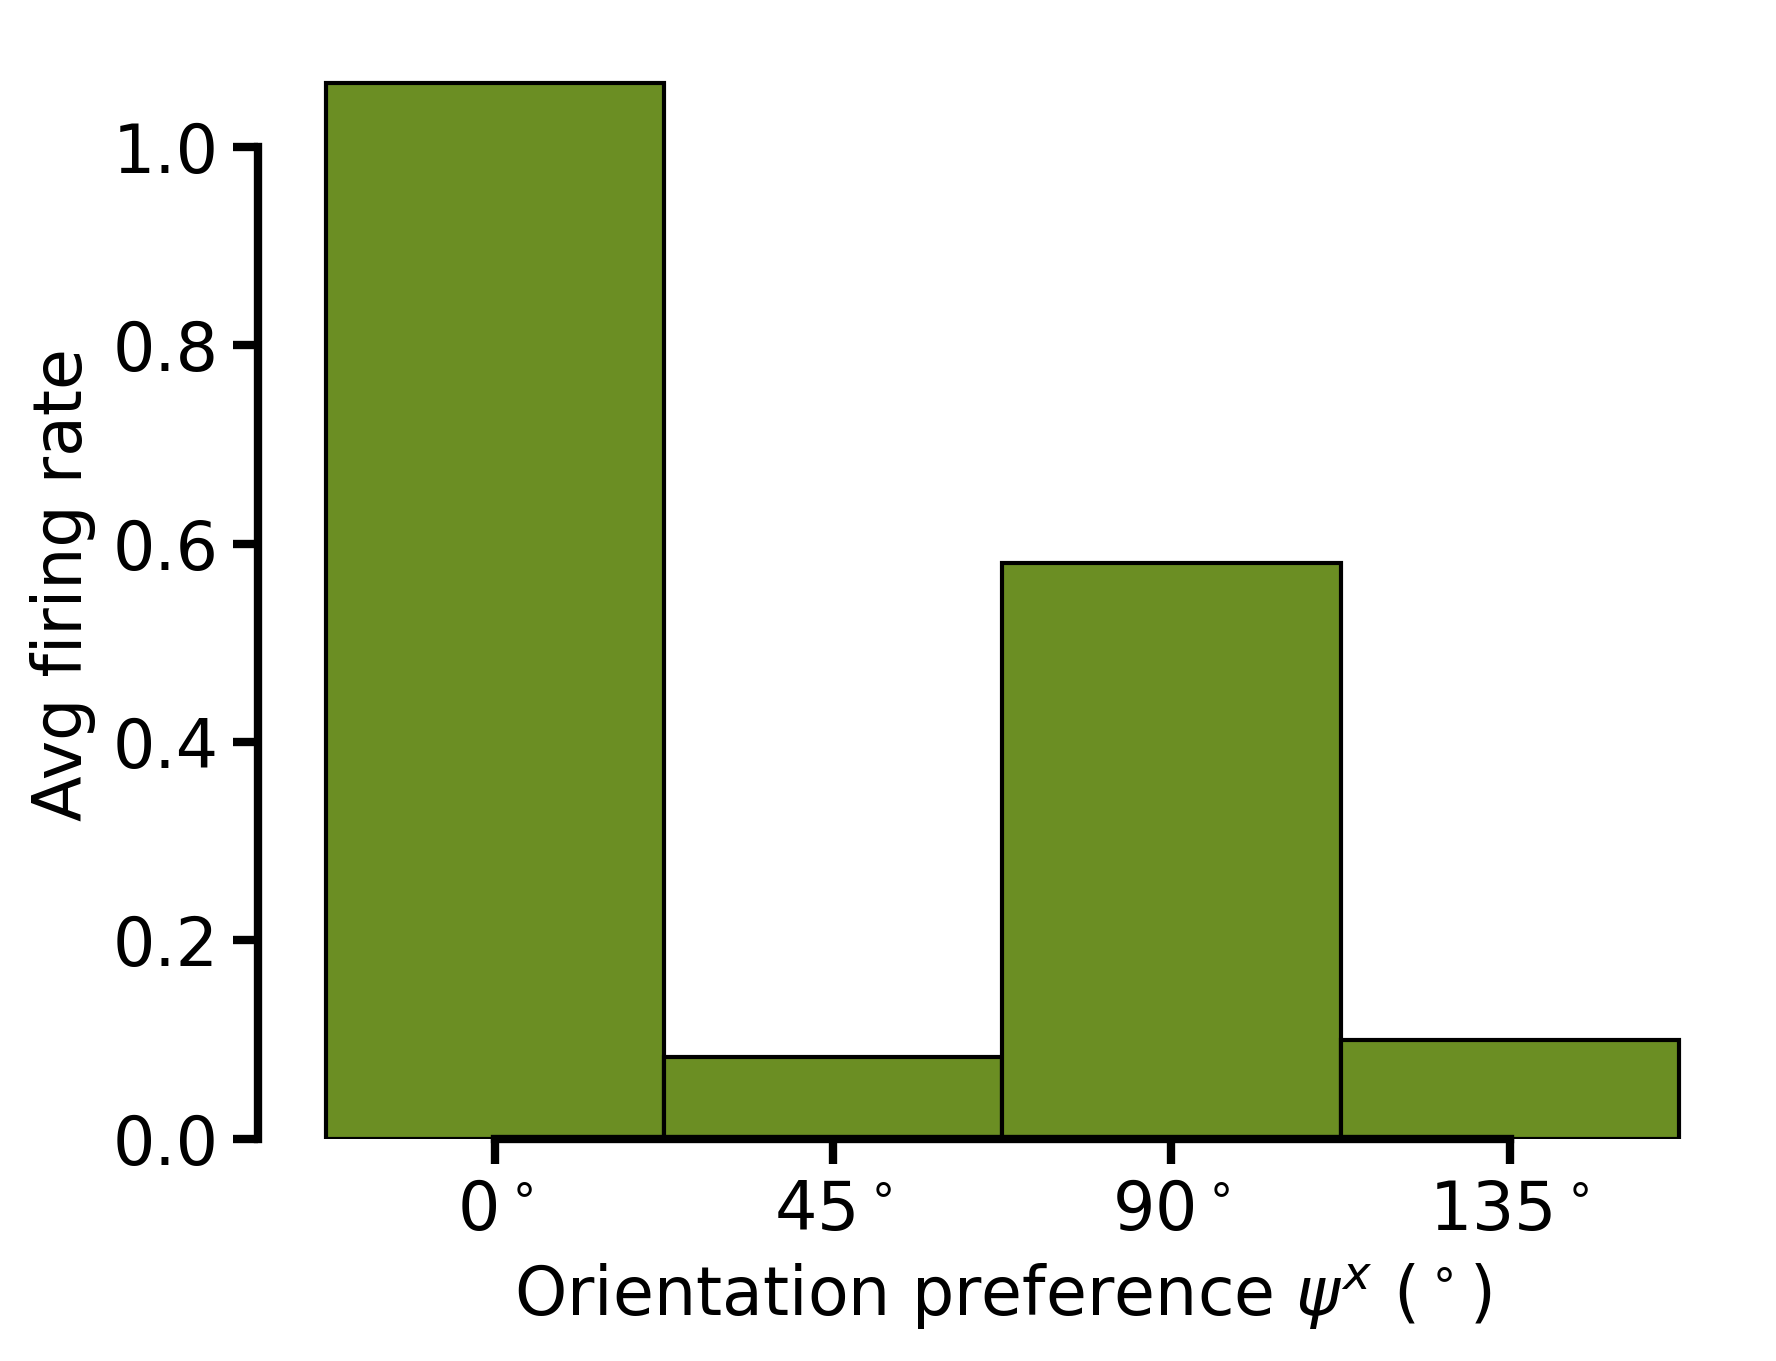

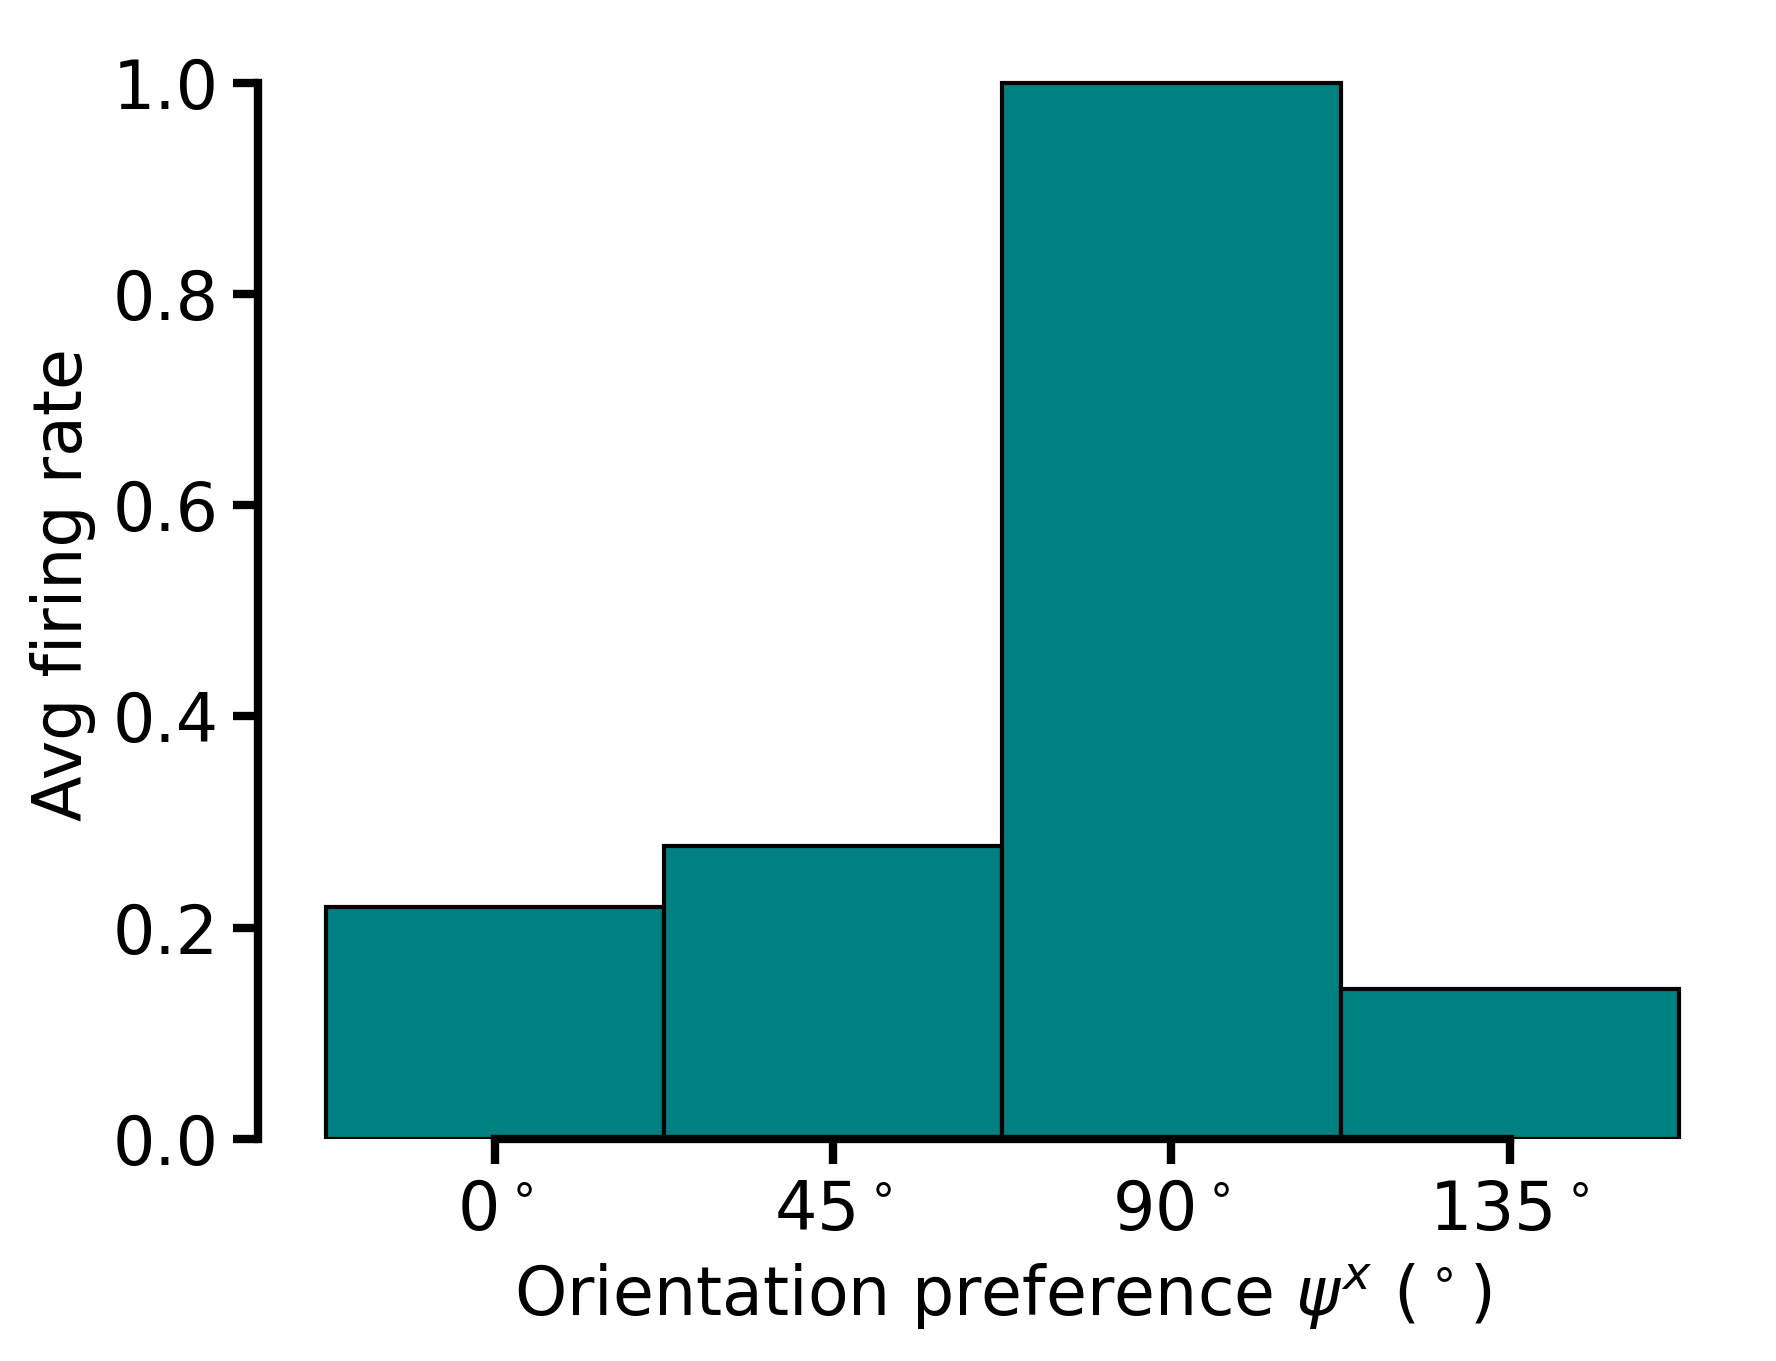

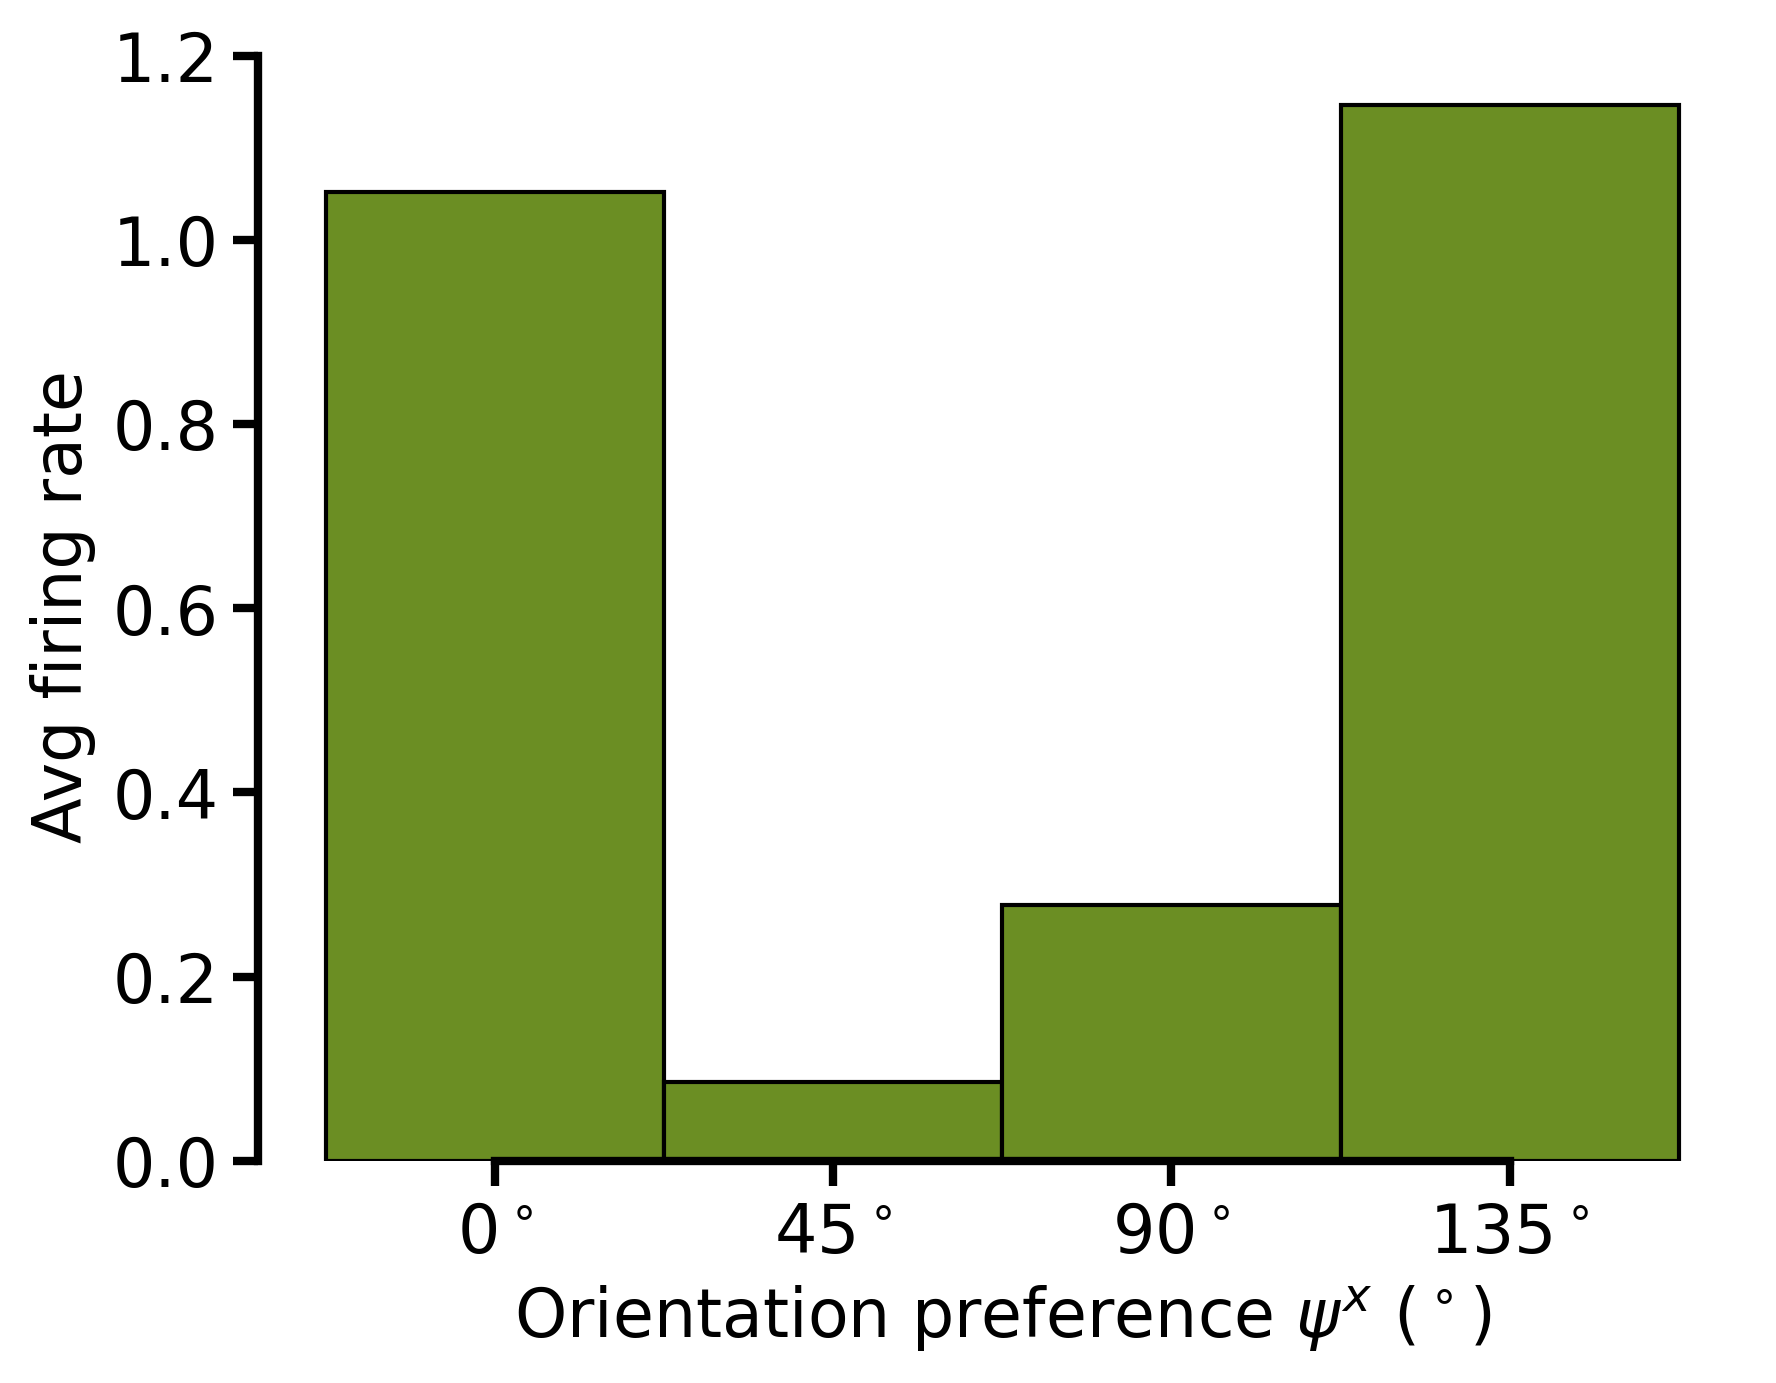

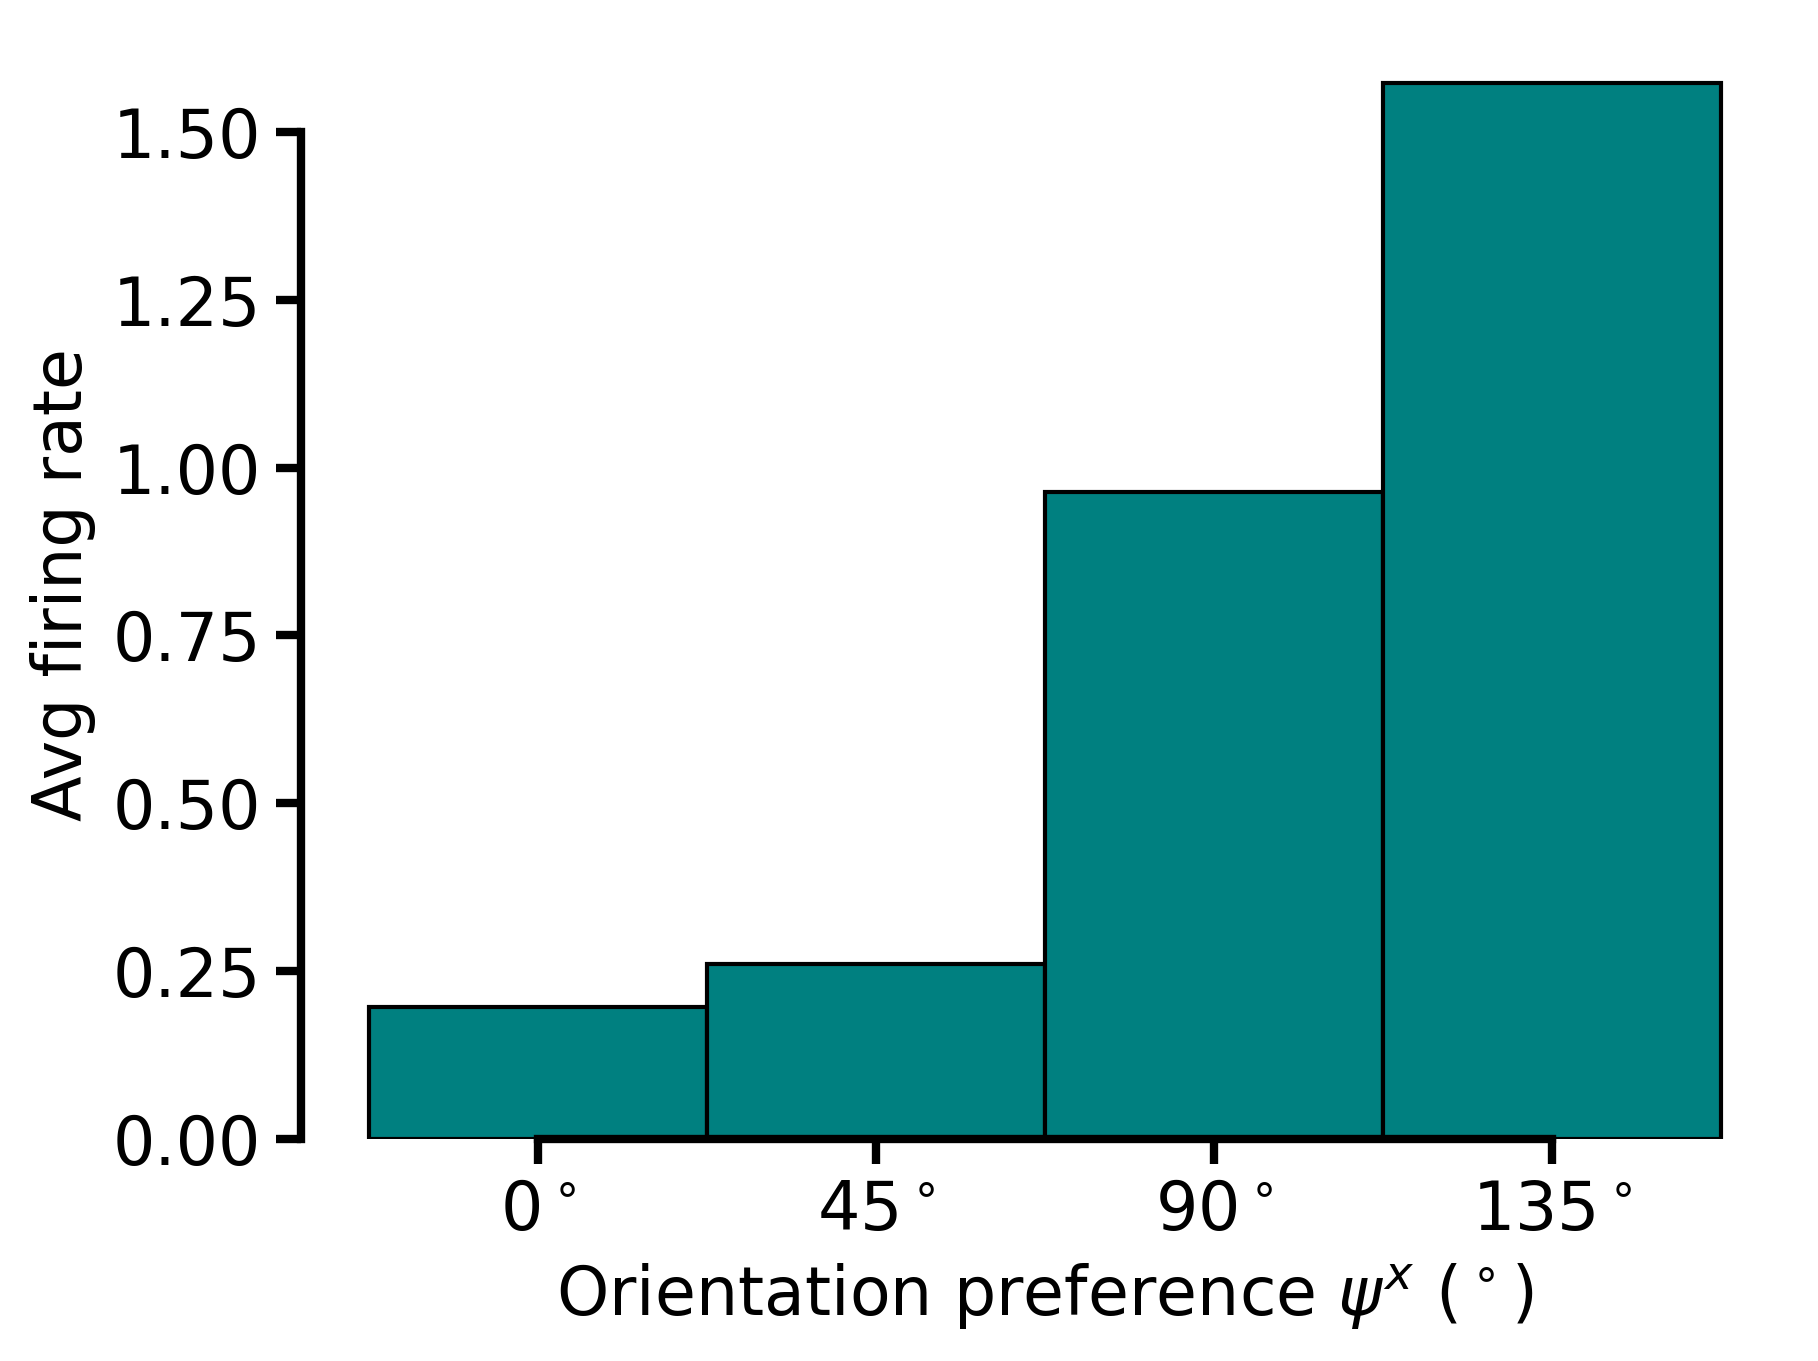

In [145]:
plotting_params = {
    "dpi": 300,
    "bar_color": "olivedrab",
    "bar_edgecolor": "black",
    "fontsize": 16,
    "linewidth": 4,
    "tick_length": 6,
    "tick_width": 2,
    "save_path": "/tmp.pdf",
    "label": "Avg firing rate $x_i$",
    "legend": False,
    "legend_loc": "upper right",
    "legend_fontsize": 16,
}

si_plotting_params = plotting_params.copy()
si_plotting_params.update({"bar_color": "olivedrab"})
sbv_plotting_params = plotting_params.copy()
sbv_plotting_params.update({"bar_color": "teal"})

task_params = dict(
    orientations=task1_data_model.x_phi,
    c1_psi=np.pi / 4,
    c2_psi=3 * np.pi / 4,
)

with torch.no_grad():
    si1_model.eval()
    sbv1_10k_model.eval()
    for stimulus, orientation in zip(stimuli, task1_data_model.x_phi):
        stimulus = stimulus.flatten()
        si_dist = si1_model.trainable_distribution.distribution(cond=stimulus)
        si_mean = si_dist.base_dist.concentration / si_dist.base_dist.rate
        si_plotting_params.update(
            {
                "save_path": f"/src/project/figures/learning/predictive/si/{int(np.rad2deg(orientation))}.pdf"
            }
        )
        plot_predictive_means_and_task_prior(
            si_mean,
            task_params,
            si_plotting_params
        )
        sbv_dist = sbv1_10k_model.trainable_distribution.distribution(cond=stimulus)
        sbv_mean = sbv_dist.base_dist.concentration / sbv_dist.base_dist.rate
        sbv_plotting_params.update(
            {
                "save_path": f"/src/project/figures/learning/predictive/sbv/{int(np.rad2deg(orientation))}.pdf"
            }
        )
        plot_predictive_means_and_task_prior(
            sbv_mean,
            task_params,
            sbv_plotting_params
        )
        # break

In [142]:
sbv_mean

tensor([0.9138, 0.2915, 1.0277, 0.0778])

In [139]:
stimulus.shape

torch.Size([144])

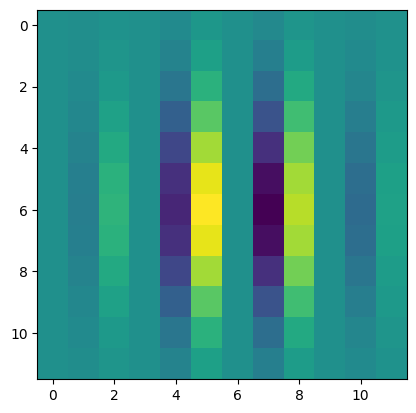

In [140]:
plt.imshow(stimulus.reshape(12, 12))

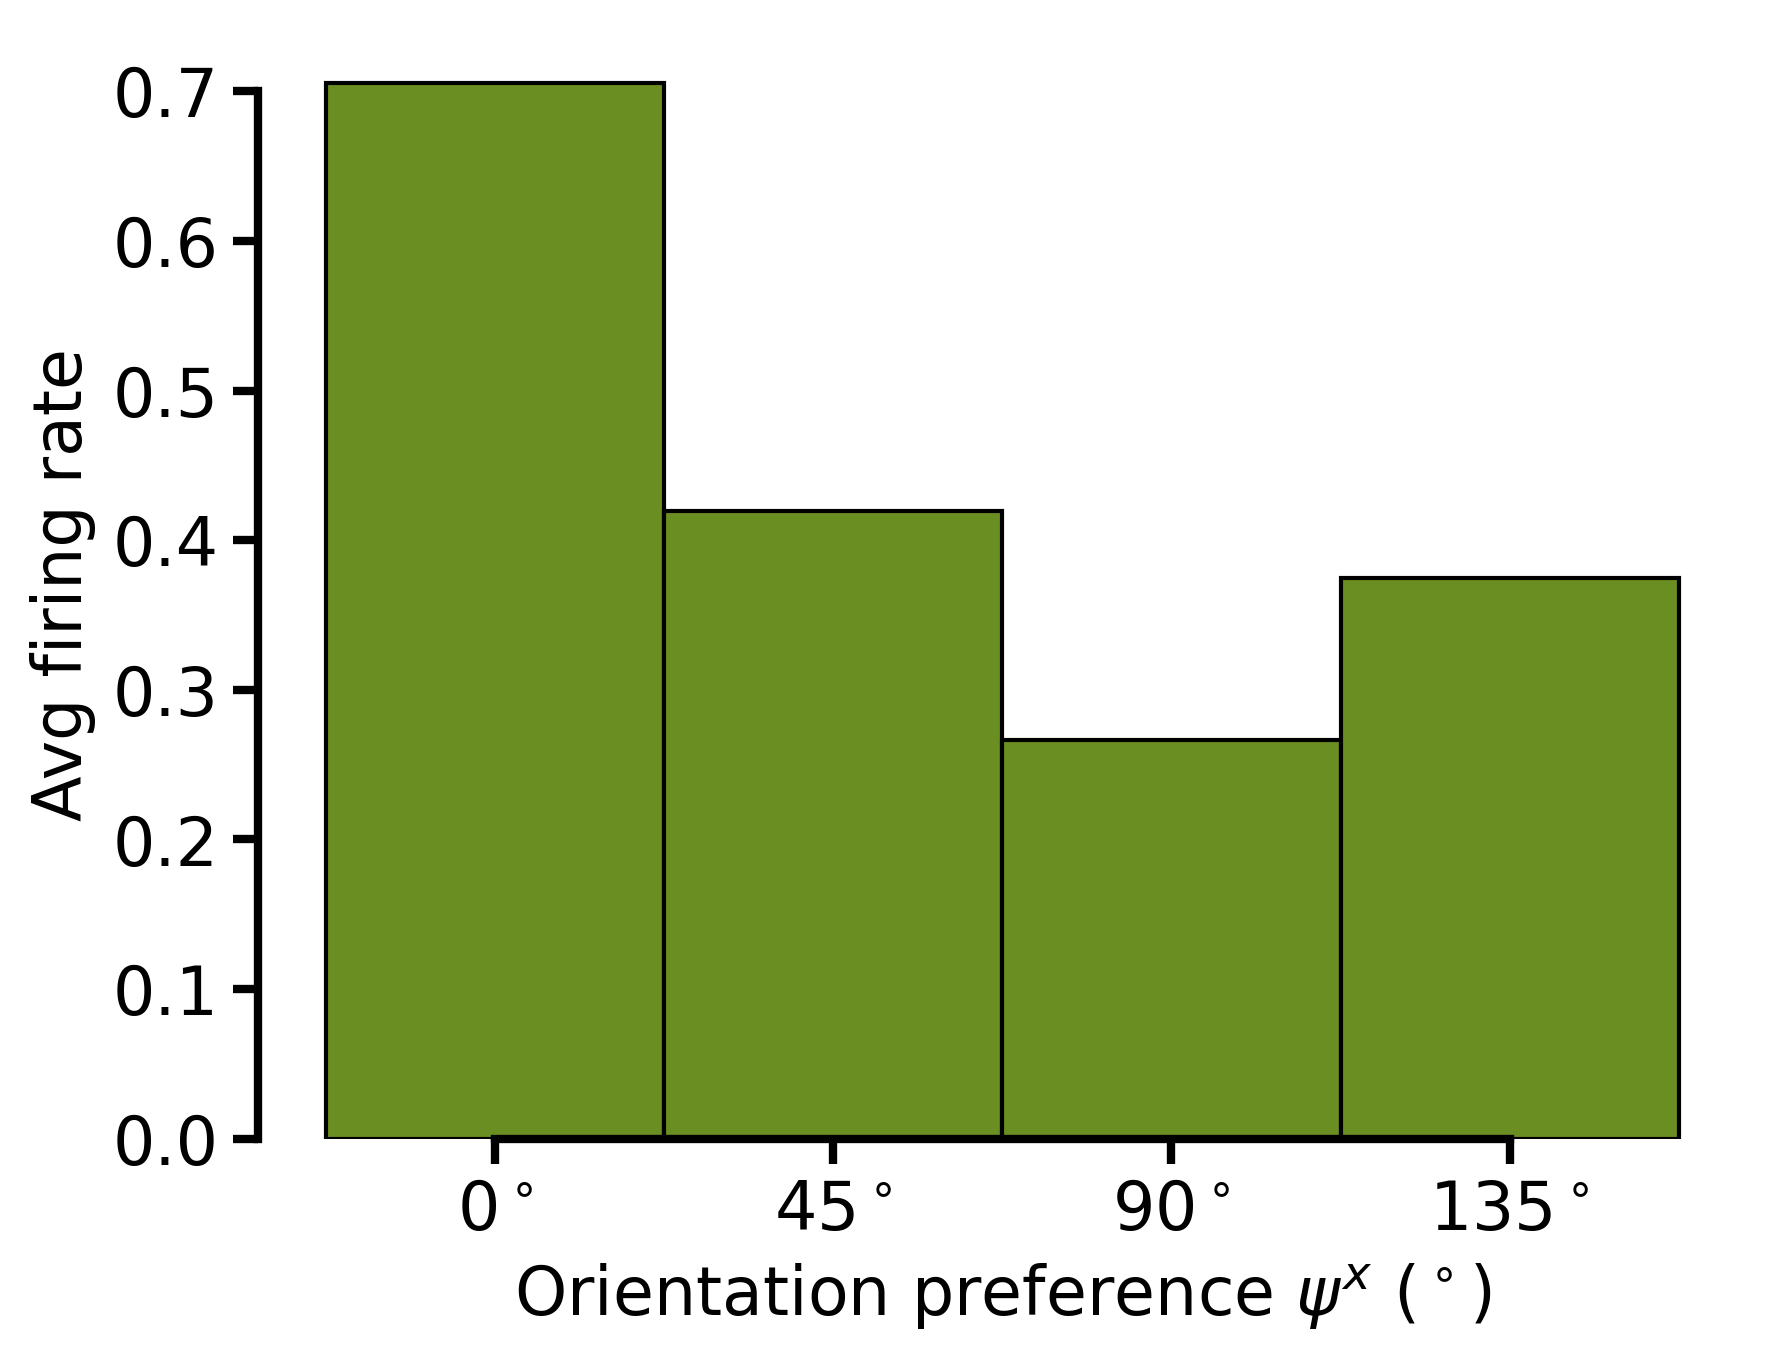

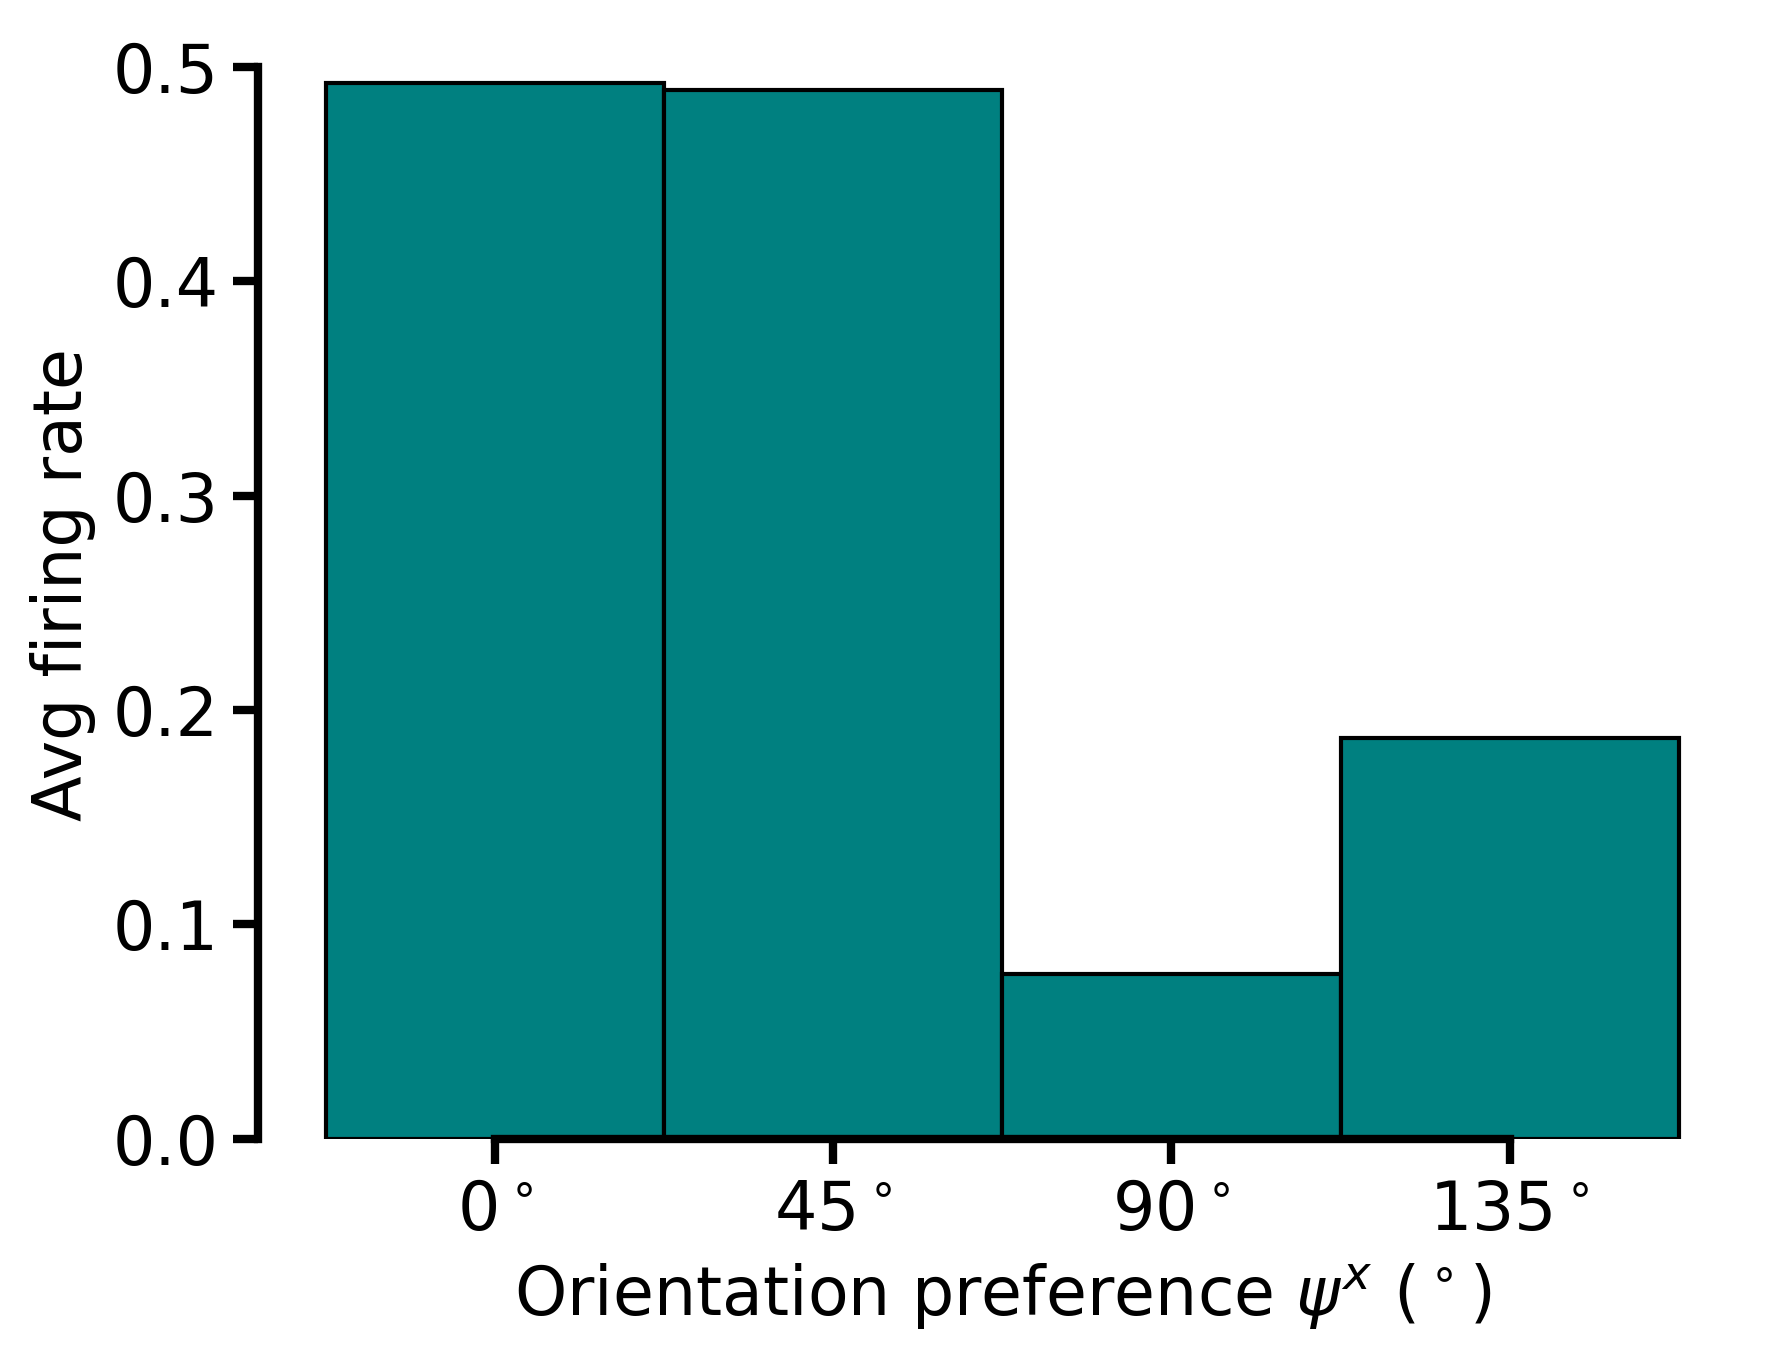

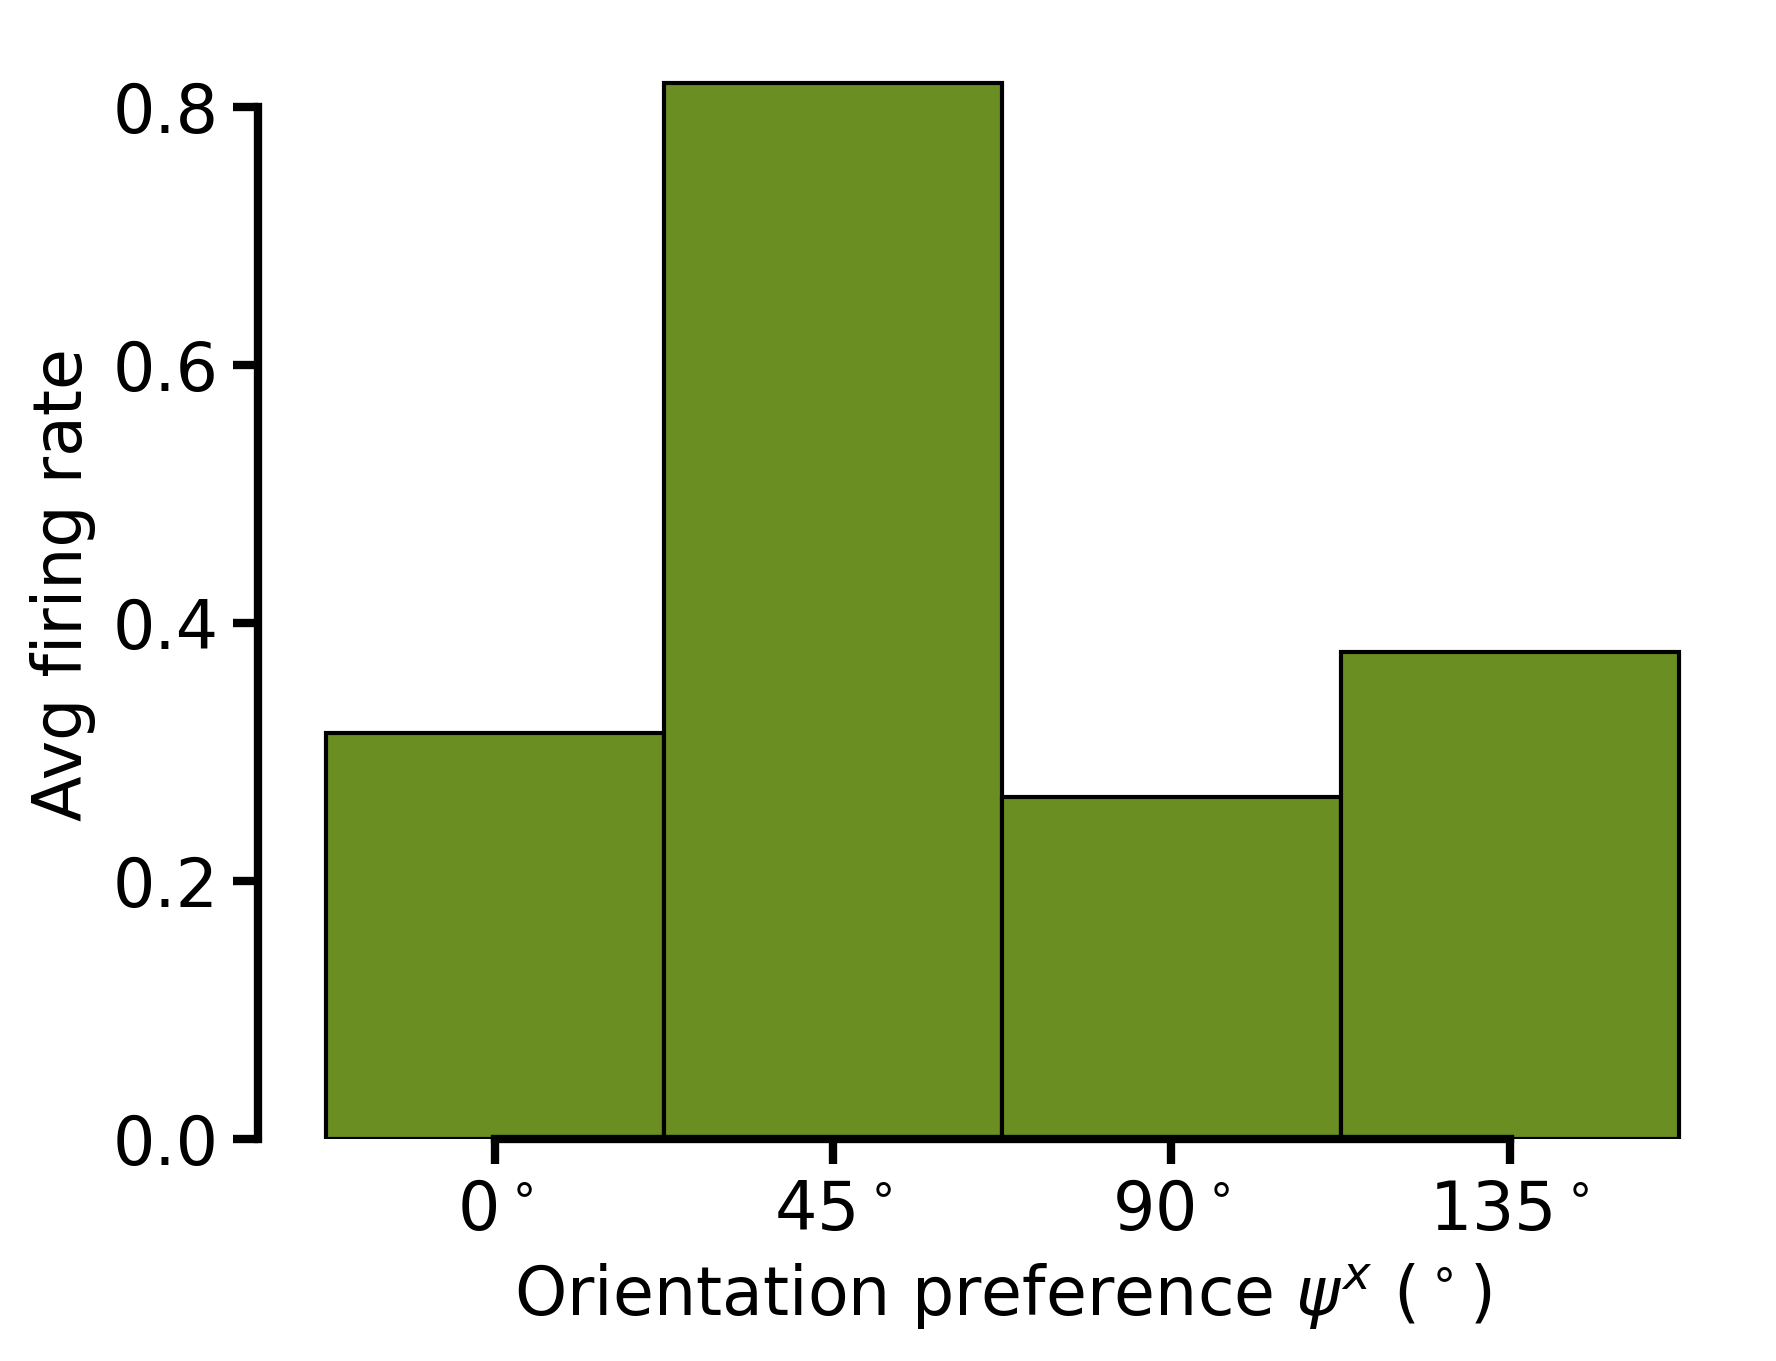

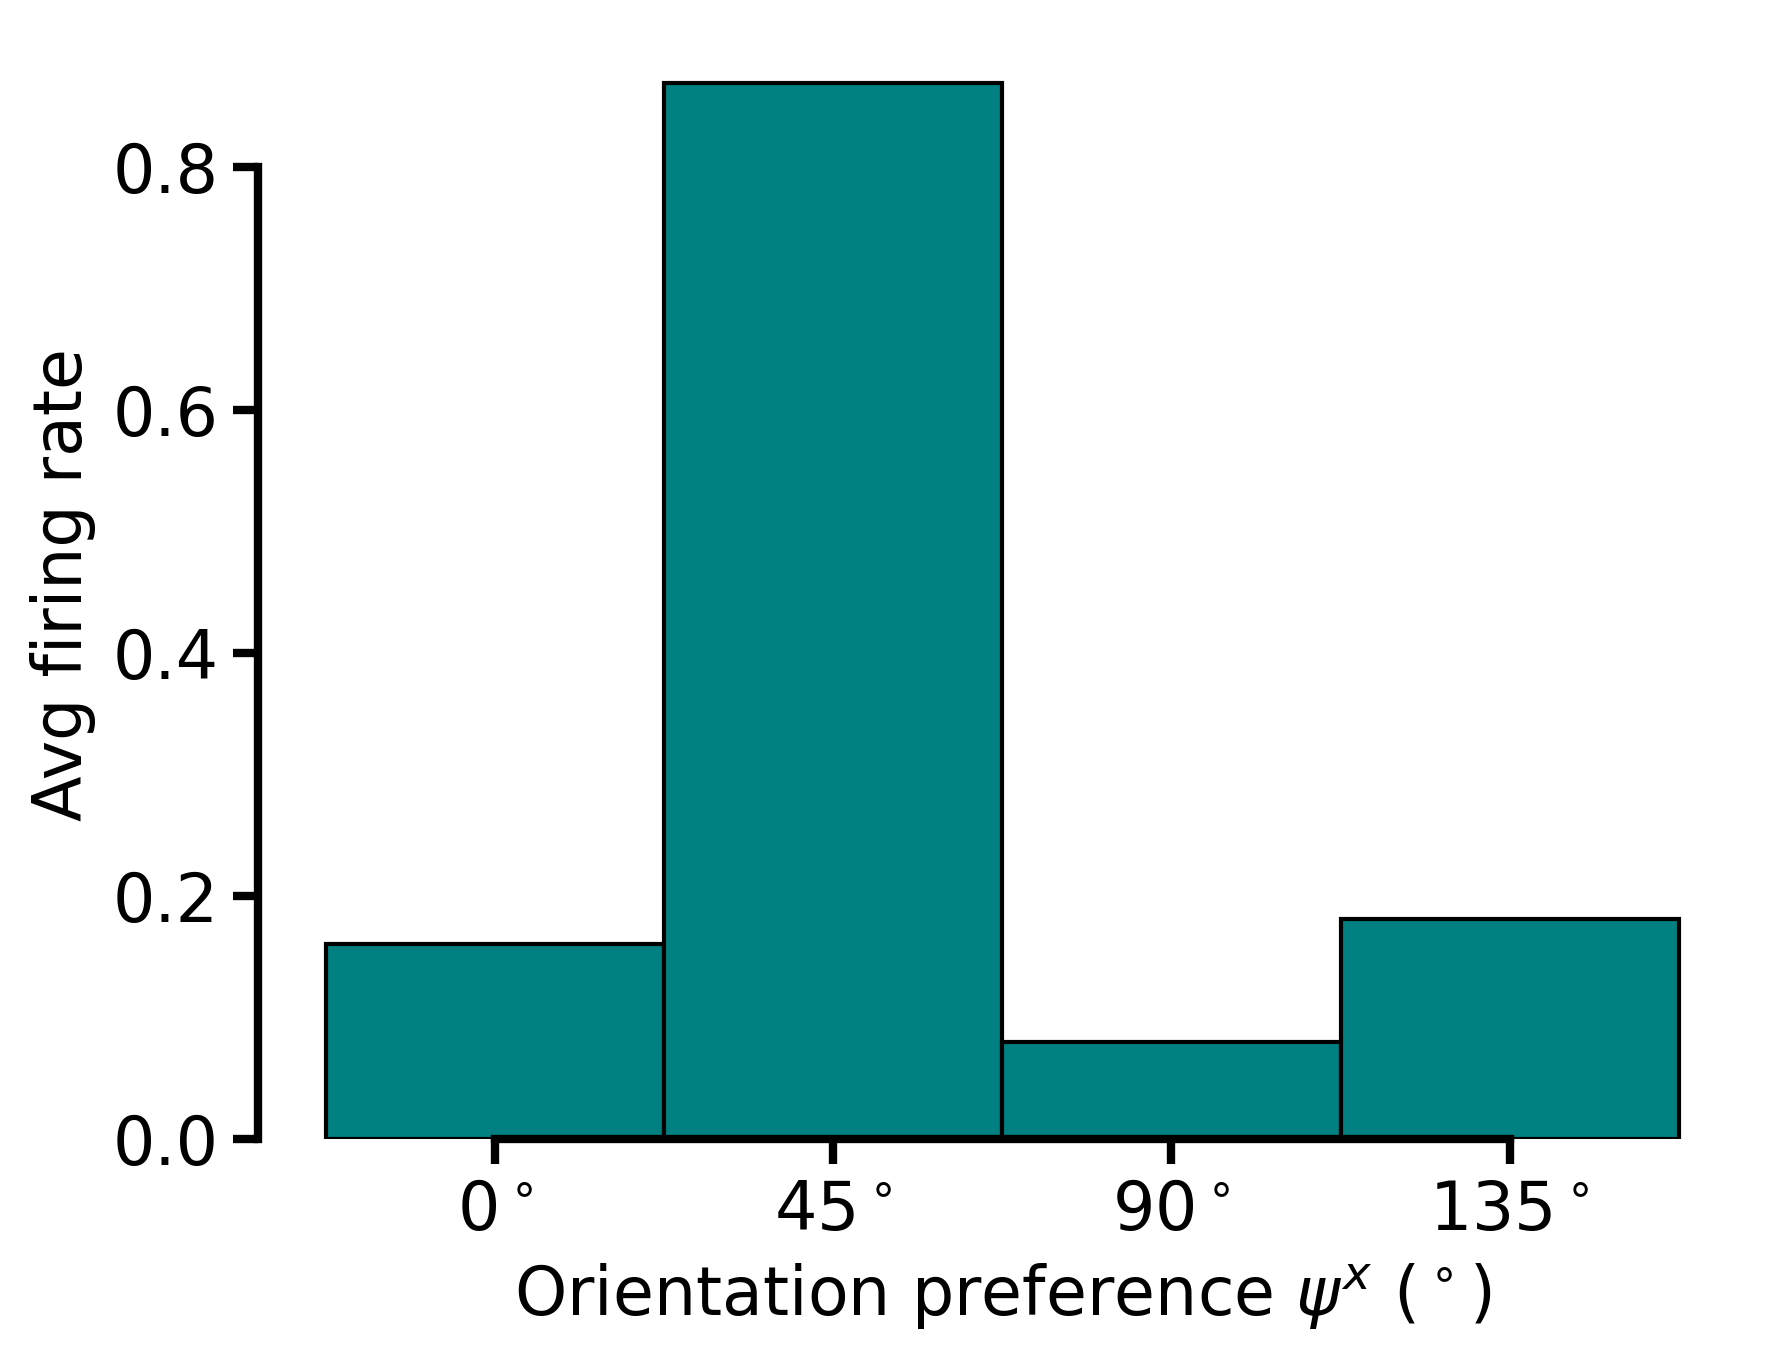

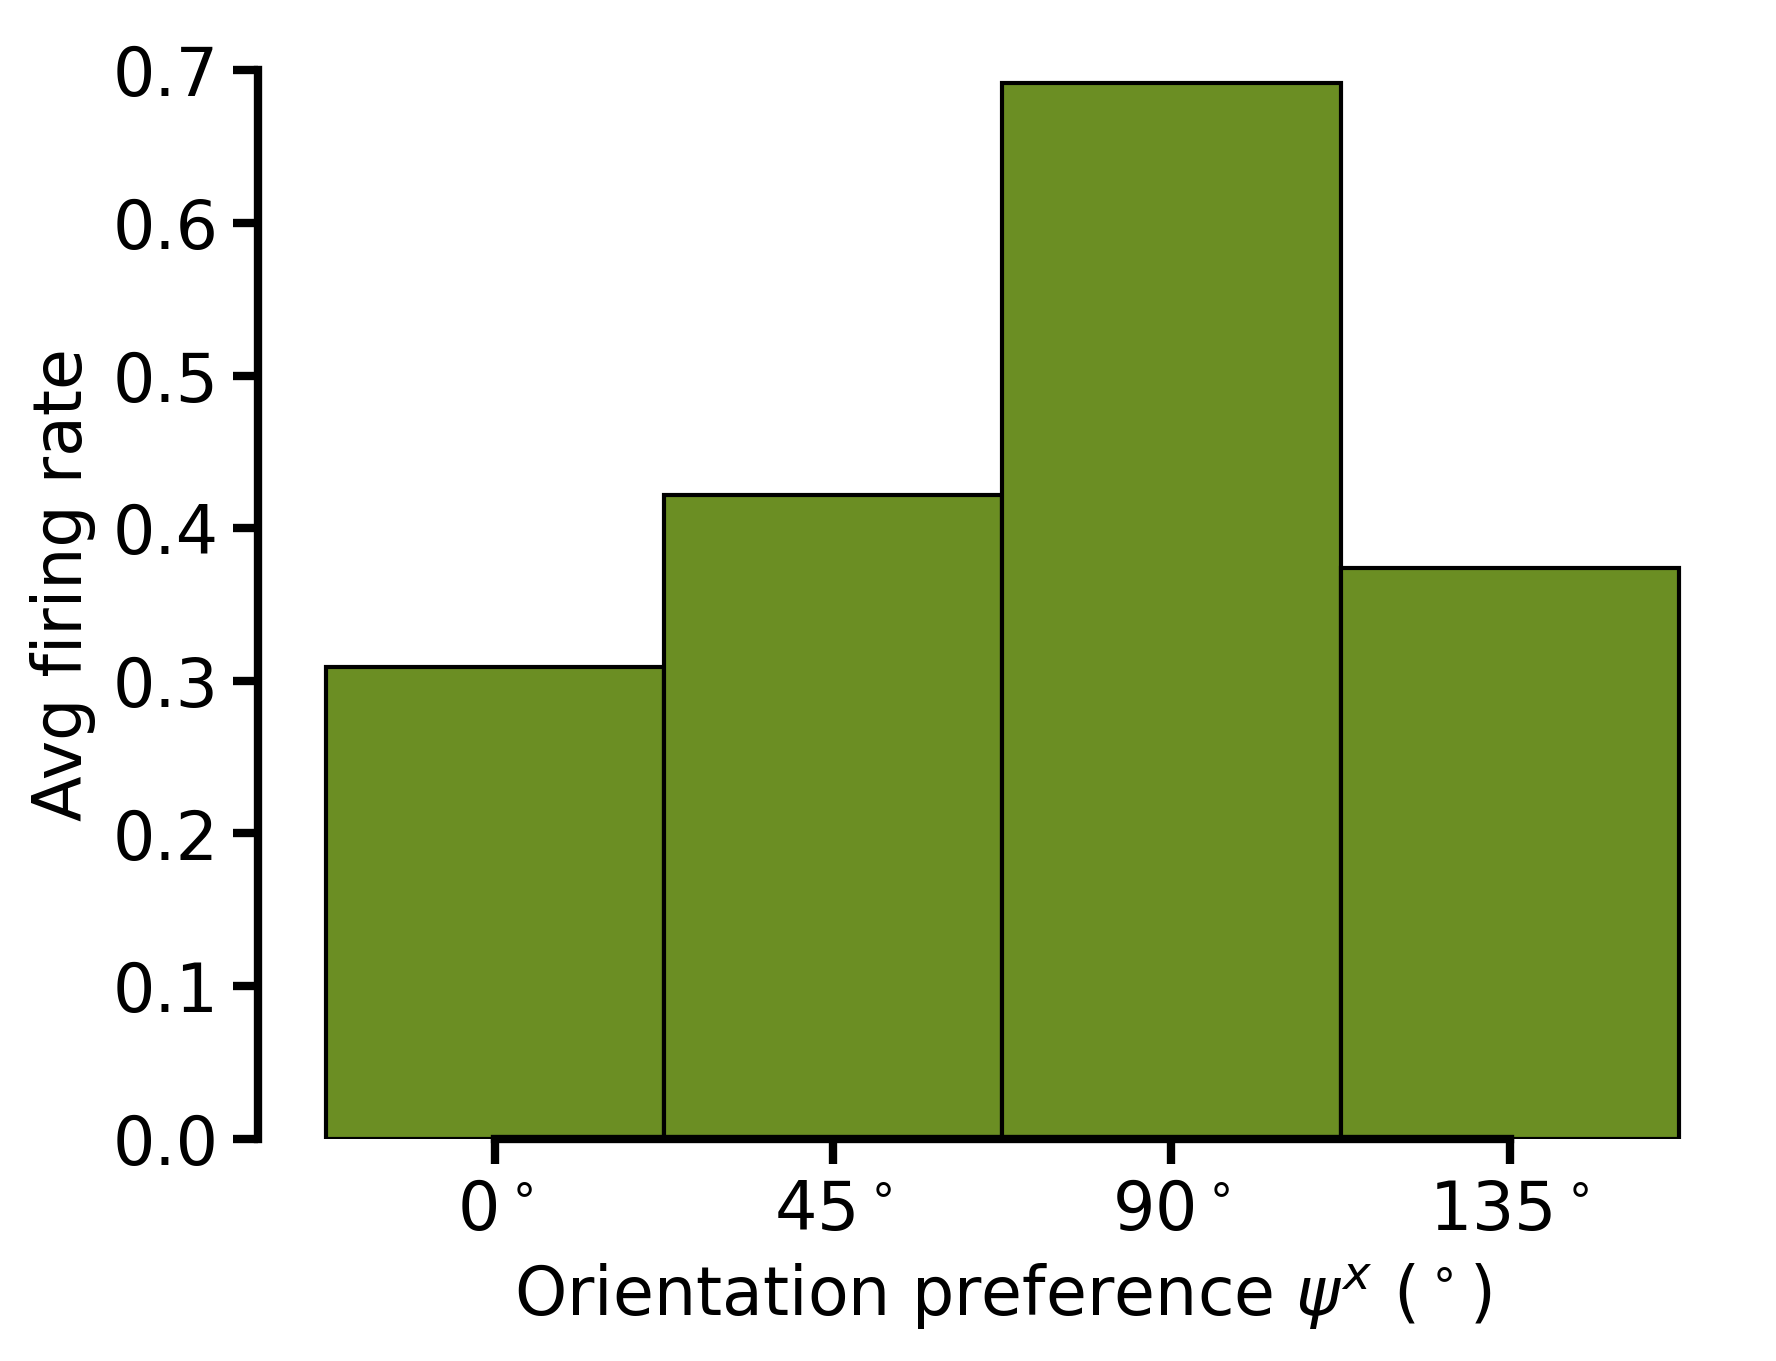

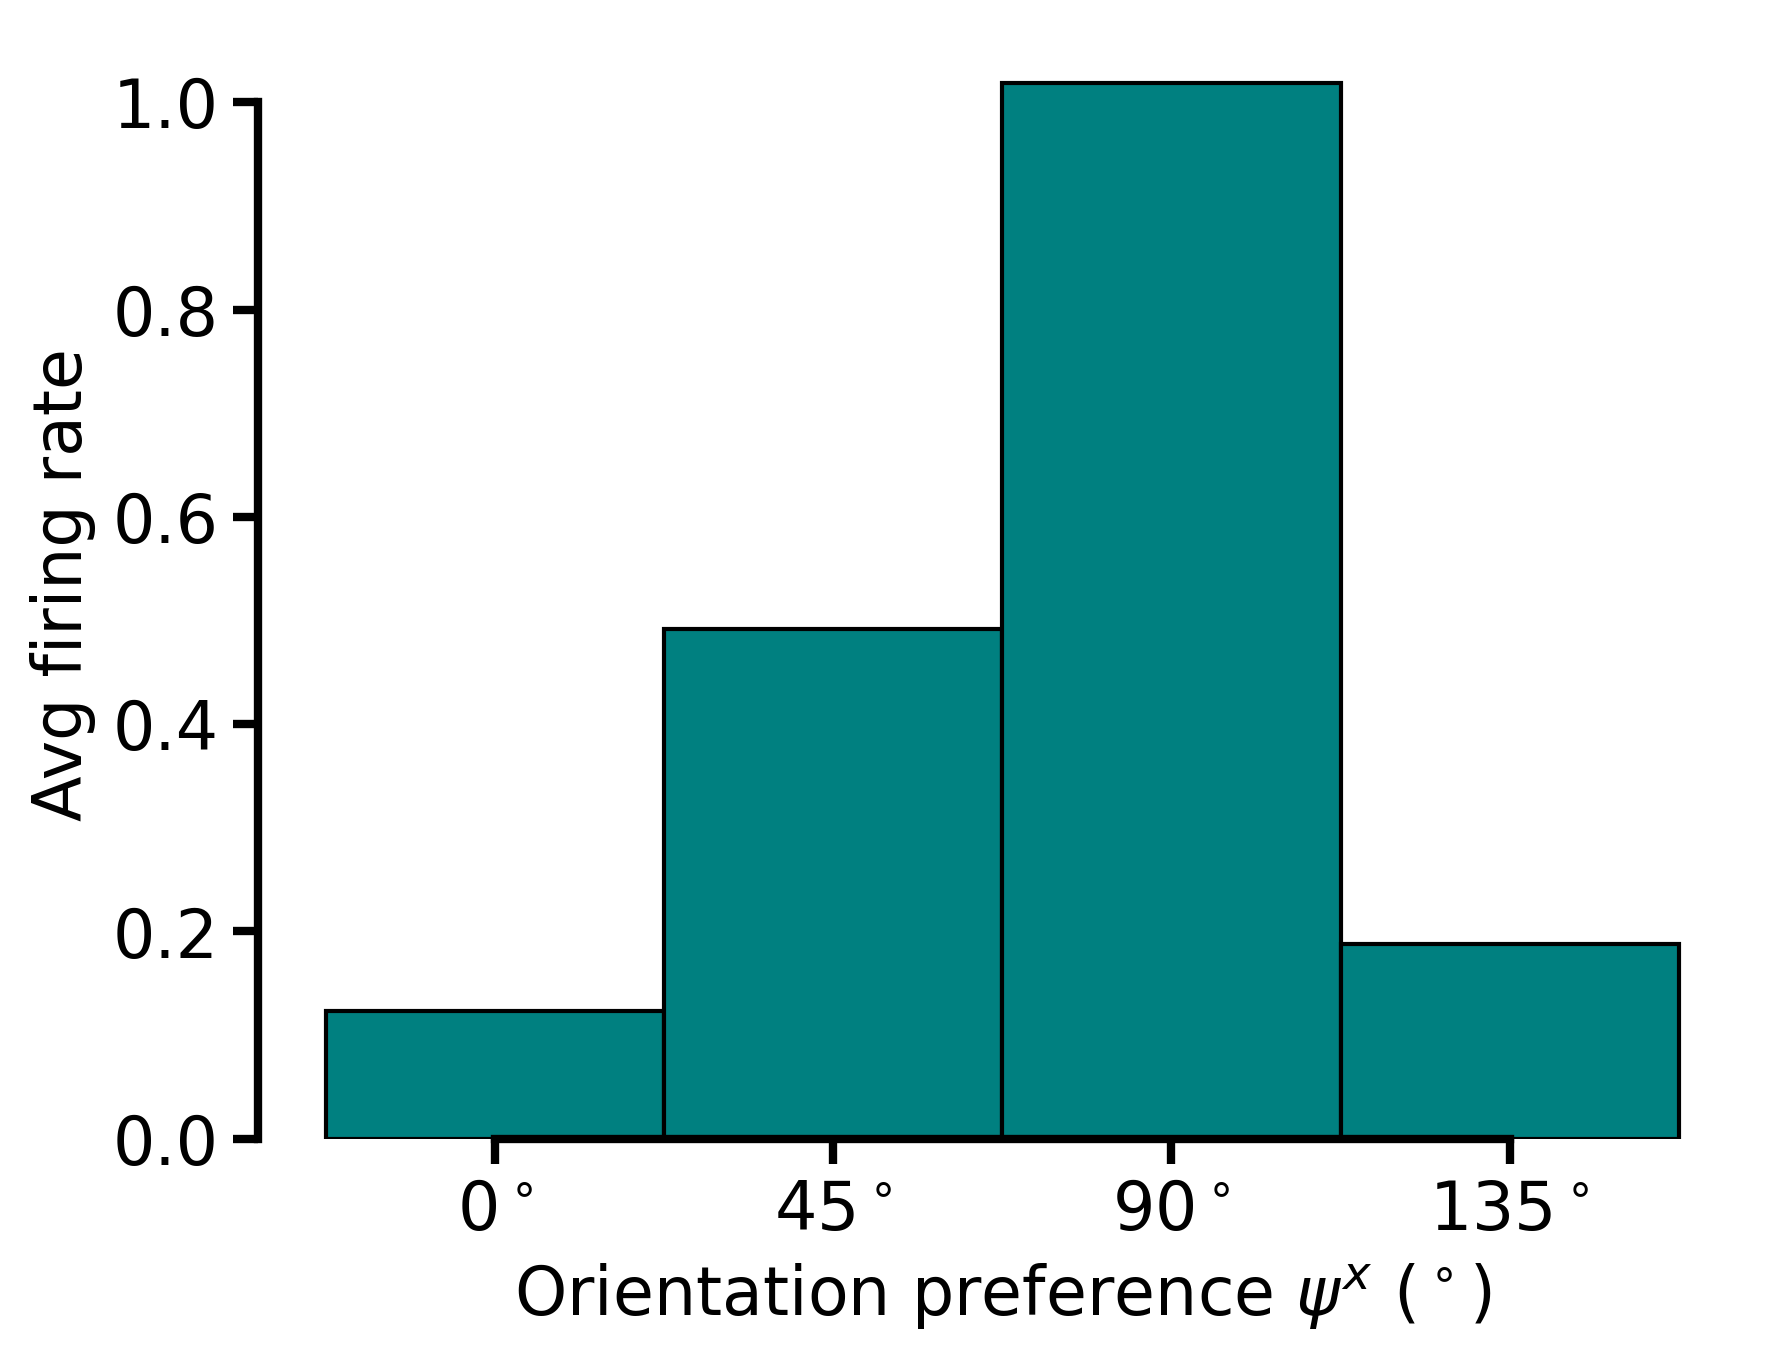

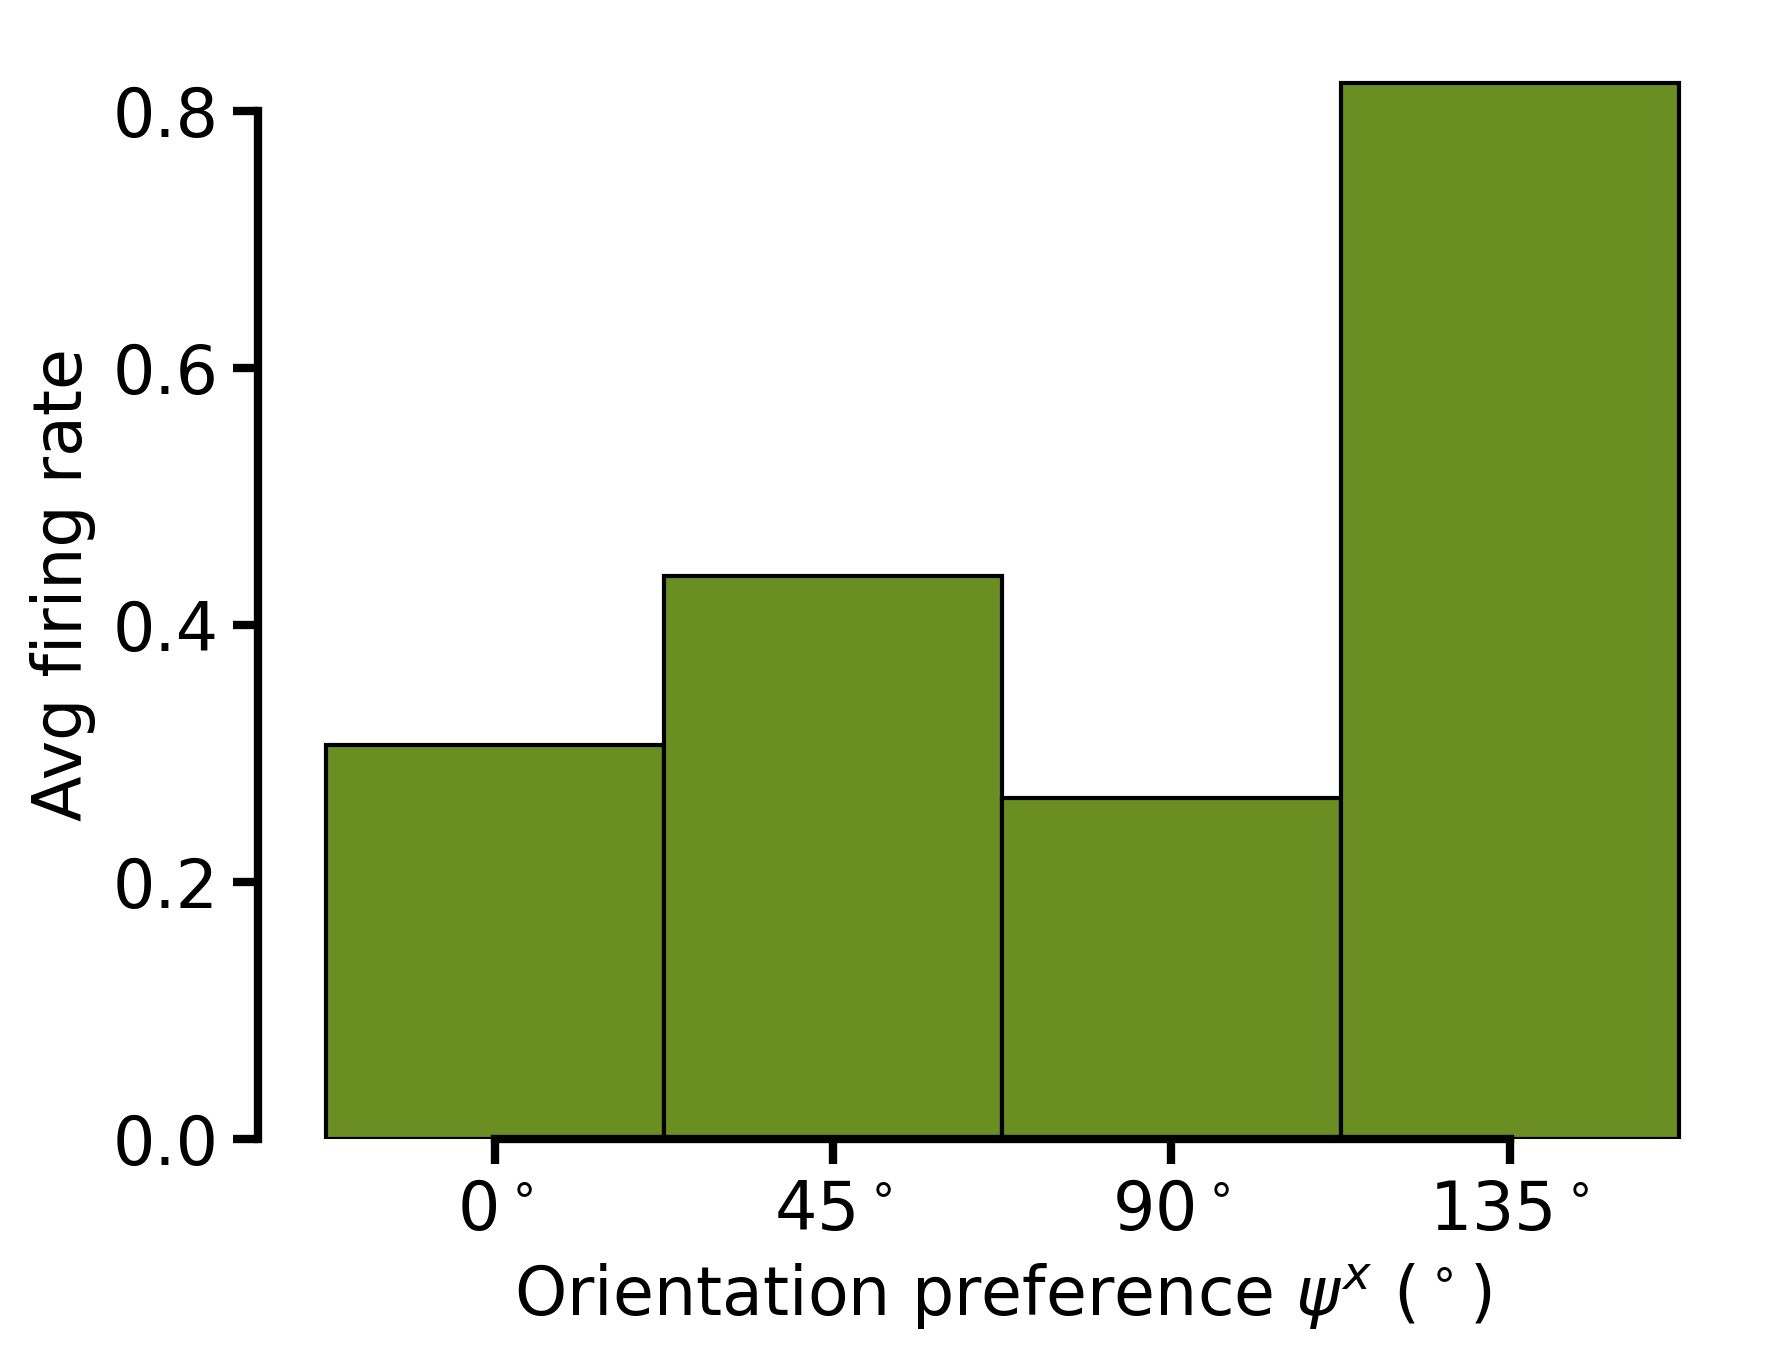

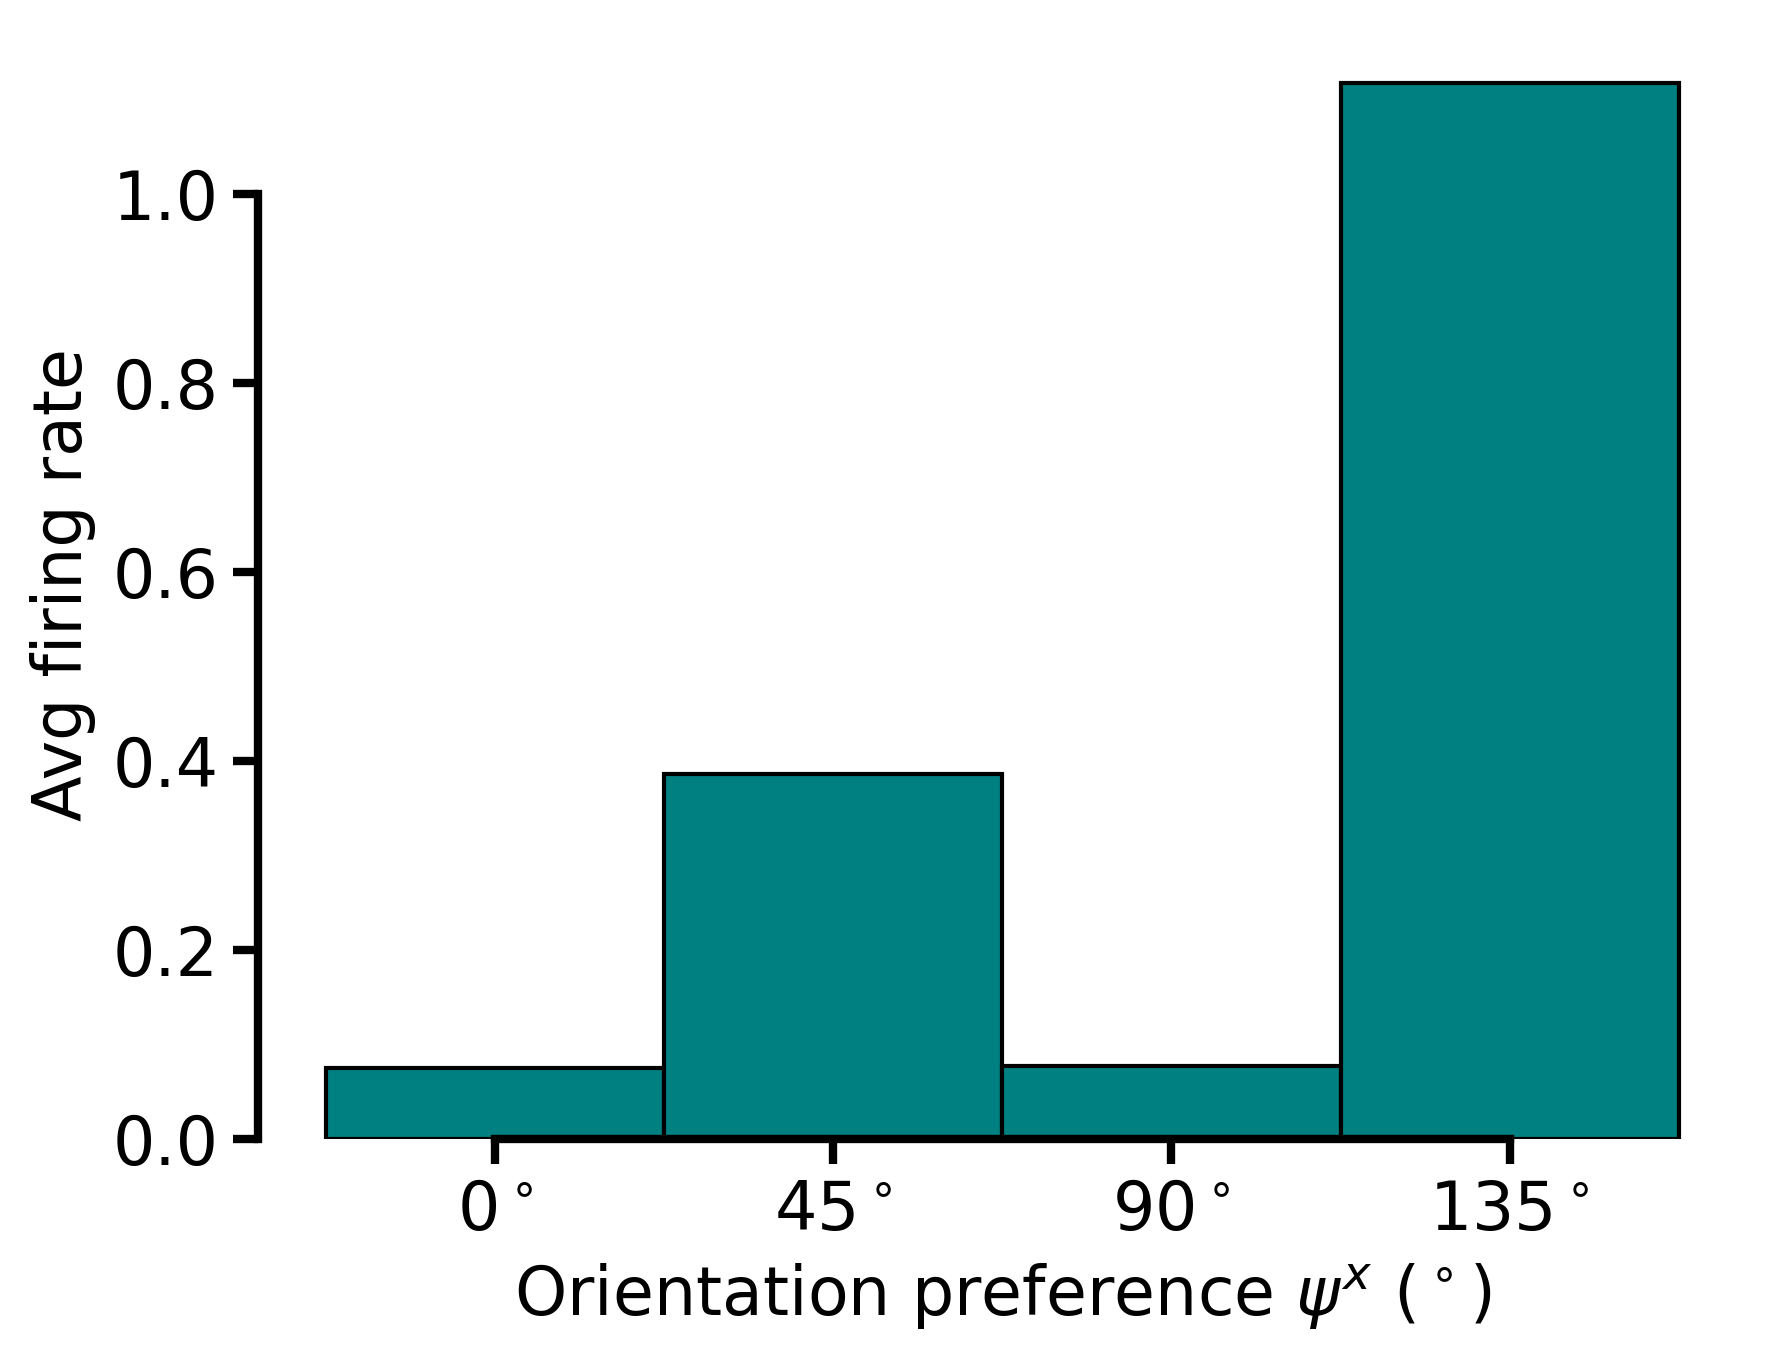

In [148]:
plotting_params = {
    "dpi": 300,
    "bar_color": "olivedrab",
    "bar_edgecolor": "black",
    "fontsize": 16,
    "linewidth": 4,
    "tick_length": 6,
    "tick_width": 2,
    "save_path": "/tmp.pdf",
    "label": "Avg firing rate $x_i$",
    "legend": False,
    "legend_loc": "upper right",
    "legend_fontsize": 16,
}

si_plotting_params = plotting_params.copy()
si_plotting_params.update({"bar_color": "olivedrab"})
sbv_plotting_params = plotting_params.copy()
sbv_plotting_params.update({"bar_color": "teal"})

task_params = dict(
    orientations=task1_data_model.x_phi,
    c1_psi=np.pi / 4,
    c2_psi=3 * np.pi / 4,
)

with torch.no_grad():
    si2_model.eval()
    sbv2_30k_model.eval()
    for stimulus, orientation in zip(stimuli, task1_data_model.x_phi):
        stimulus = stimulus.flatten()
        si_dist = si2_model.trainable_distribution.distribution(cond=stimulus)
        si_mean = si_dist.base_dist.concentration / si_dist.base_dist.rate
        si_plotting_params.update(
            {
                "save_path": f"/src/project/figures/learning/predictive/si/{int(np.rad2deg(orientation))}.pdf"
            }
        )
        plot_predictive_means_and_task_prior(si_mean, task_params, si_plotting_params)
        sbv_dist = sbv2_30k_model.trainable_distribution.distribution(cond=stimulus)
        sbv_mean = sbv_dist.base_dist.concentration / sbv_dist.base_dist.rate
        sbv_plotting_params.update(
            {
                "save_path": f"/src/project/figures/learning/predictive/sbv/{int(np.rad2deg(orientation))}.pdf"
            }
        )
        plot_predictive_means_and_task_prior(sbv_mean, task_params, sbv_plotting_params)
        # break